In [1]:
from networkx.convert import to_networkx_graph
from torch_geometric.utils import to_networkx


import os
from pathlib import Path

%load_ext autoreload
%autoreload 2

PROJECT_DIR = Path.cwd().parent
os.chdir(PROJECT_DIR)

print("PROJECT_DIR:", PROJECT_DIR)
print("Current directory:", Path.cwd())

import numpy as np


from matplotlib import pyplot as plt

from experiments import (
    experiment_train,
    experiment_local_attack_direct,
    experiment_global_attack_direct
)
import helpers.selector_pipeline_helpers

from sparse_smoothing.utils import load_and_standardize
from sparse_smoothing.models import GCN

files = ["cache/demo.json", "cache/demo/demo_1.pt", "cache/evasion_global_adj.json", "cache/evasion_global_attr.json", "cache/evasion_global_adj/evasion_global_adj_1.pt", "cache/evasion_global_attr/evasion_global_attr_1.pt"]

for file_path in files:
    if os.path.exists(file_path):
        os.remove(file_path)
        print(f"{file_path} has been deleted.")
    else:
        print(f"{file_path} does not exist.")

%matplotlib inline




PROJECT_DIR: E:\Masterarbeit\AttackerGNN
Current directory: E:\Masterarbeit\AttackerGNN


Use from seml.experiment import setup_logger instead.
Note that seml.experiment.Experiment already includes the logger setup.
See https://github.com/TUM-DAML/seml/blob/master/examples/example_experiment.py


[08/15/26 10:23:34] WARNING  Importing setup_logger directly from seml is deprecated.                ]8;id=344016;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\seml\__init__.py\__init__.py]8;;\:]8;id=758890;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\seml\__init__.py#10\10]8;;\
                             Use from seml.experiment import setup_logger instead.                                 
                             Note that seml.experiment.Experiment already includes the logger setup.               
                             See                                                                                   
                             https://github.com/TUM-DAML/seml/blob/master/examples/example_experimen               
                             t.py                                                                                  

[08/15/26 10:23:34] WARNING  Importing setup_logger directly from seml is deprecated.                ]8;id=460248;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\seml\__init__.py\__init__.py]8;;\:]8;id=822486;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\seml\__init__.py#10\10]8;;\
                             Use from seml.experiment import setup_logger instead.                                 
                             Note that seml.experiment.Experiment already includes the logger setup.               
                             See                                                                                   
                             https://github.com/TUM-DAML/seml/blob/master/examples/example_experimen               
                             t.py                                                                                  

cache/demo.json does not exist.
cache/demo/demo_1.pt does not exist.
cache/evasion_global_adj.json does not exist.
cache/evasion_global_attr.json does not exist.
cache/evasion_global_adj/evasion_global_adj_1.pt does not exist.
cache/evasion_global_attr/evasion_global_attr_1.pt does not exist.


In [2]:
# ── Dataset / split ─────────────────────────────────────────────────────────
DATASET = 'cora_ml'
SAMPLING = 'stratified'
SPLIT = 'ratio'

# All experiments in this notebook are repeated for these seeds.
# Add/remove values here; every raw table keeps `seed`, while displayed tables
# and plots aggregate over this list.
SEEDS = [0]
if not SEEDS:
    raise ValueError("SEEDS must contain at least one integer seed.")
SEEDS = [int(seed) for seed in SEEDS]
SEED = SEEDS[0]  # compatibility alias; never use this for an experiment loop
N_SEEDS = len(SEEDS)

TRAIN_RATIO = 0.15
VAL_RATIO = 0.10
TEST_RATIO = 0.30

# ── Victim model ─────────────────────────────────────────────────────────────
MODEL_NAME = 'GCN'
MODEL_LABEL = 'GCN'
TRAIN_EPOCHS = 200
HIDDEN = 64
INDUCTIVE = True
DROPOUT_VICTIM = 0.5
LR_VICTIM = 1e-2
WEIGHT_DECAY_VICTIM = 1e-3
PATIENCE_VICTIM = 300
MAX_EPOCHS_VICTIM = 3000

# ── V4 mining params ─────────────────────────────────────────────────────────
USE_PRBCD_CANDIDATES = True
N_PRBCD_RUNS = 1
MINER = 'prbcd'
MINER_LOCAL_FACTOR = 0.5
DEGREE_CAP_PCT = None
PRBCD_BUDGET_FRACTION = 0.5
CANDIDATE_SET_SIZES = [1000]
PRBCD_CANDIDATE_FRACTIONS = [0.0]
SCORING_MODES = ["endpoint","subset_accuracy_drop"]
LABEL_MODES = ["continuous"]
EXTREME_FRACTIONS = [0.3]
PRBCD_EPOCHS = 5
PRBCD_SEARCH_SPACE = 200_000
PRBCD_N_EPOCHS_RESAMPLING = 1

# ── Logging ─────────────────────────────────────────────────────────

RQ2_OUT_DIR = Path("extendedPlotting/final_runs/RQ2")
RQ2_OUT_DIR.mkdir(parents=True, exist_ok=True)

RQ3_OUT_DIR = Path("extendedPlotting/final_runs/RQ3")
RQ2_OUT_DIR.mkdir(parents=True, exist_ok=True)


# ── RQ3 subgraph-selector sweep ─────────────────────────────────────────────
# Every requested combination is constructed and trained. Only §8 consumes
# the complete Cartesian product. Legacy RQ3 diagnostics use the primary
# combination selected below.
# A value of 1.0 is an explicit whole-graph selector condition. It uses all
# graph nodes/edges for message passing, while candidate labels are still
# obtained from a finite sampled candidate set.
RQ3_SUBGRAPH_FRACTIONS = [1.0]
RQ3_SUBGRAPH_TRAINING_CANDIDATE_SIZES = [2500,5000,10000]
RQ3_SUBGRAPH_SEEDS = [20]
RQ3_SUBGRAPH_SCORING_MODES = ["endpoint","subset_accuracy_drop"]
RQ3_SUBGRAPH_METHODS = ["stratified_context", "forest_fire"]

# One combination exposed through the legacy names `mining_runs`,
# `lp_training_runs`, and `LP_MODEL_VARIANTS`. This prevents all experiments
# except §8 from silently expanding over the new sweep dimensions.
RQ3_PRIMARY_SUBGRAPH_FRACTION = 1.0
RQ3_PRIMARY_TRAINING_CANDIDATE_SIZE = 10000
RQ3_PRIMARY_SUBGRAPH_SEED = 20
RQ3_PRIMARY_SUBGRAPH_METHOD = "stratified_context"

# ── V4 subset-scoring params ─────────────────────────────────────────────────
N_SUBSETS = 1000
SUBSET_FRACTION = 0.05

# The helper owns the exact schema identifiers. The notebook imports them in
# the mining cell and writes them into every cache key and run dictionary.
# Canonical raw target:
#   mean harmful accuracy drop of subsets in which an edge was selected.

# ── Scorer training params ───────────────────────────────────────────────────
SCORER_HIDDEN = 64
SCORER_EPOCHS = 200
SCORER_LR = 0.01
VAL_FRACTION = 0.2
PATIENCE = 20
# Continuous subset scores are not class-balanced. Keep None unless deliberately
# running a separate projected-label ablation later.
BALANCE_RATIO = None

# ── Reproducibility / aggregation helpers ────────────────────────────────────
import os
import random
import pandas as pd
import torch

from pathlib import Path
from datetime import datetime


def set_global_seed(seed: int, deterministic: bool = True) -> None:
    """Seed Python, NumPy and PyTorch before every independent run."""
    seed = int(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

def aggregate_over_seeds(
    frame: pd.DataFrame,
    group_cols: list[str],
    metric_cols: list[str] | None = None,
) -> pd.DataFrame:
    """Return mean/std/SEM and number of distinct seeds for numeric metrics."""
    if frame is None or frame.empty:
        return pd.DataFrame()
    missing = [column for column in group_cols if column not in frame.columns]
    if missing:
        raise KeyError(f"Missing grouping columns: {missing}")
    if "seed" not in frame.columns:
        raise KeyError("Every raw experiment table must contain a 'seed' column.")
    if metric_cols is None:
        metric_cols = [
            column for column in frame.select_dtypes(include=[np.number]).columns
            if column not in set(group_cols) | {"seed"}
        ]
    metric_cols = [column for column in metric_cols if column in frame.columns]

    if not group_cols:
        row = {"n_seeds": int(frame["seed"].nunique())}
        for metric in metric_cols:
            values = pd.to_numeric(frame[metric], errors="coerce")
            count = int(values.notna().sum())
            mean = float(values.mean()) if count else np.nan
            std = float(values.std(ddof=1)) if count > 1 else 0.0
            row[f"{metric}_mean"] = mean
            row[f"{metric}_std"] = std
            row[f"{metric}_count"] = count
            row[f"{metric}_sem"] = std / np.sqrt(max(1, count))
        return pd.DataFrame([row])

    grouped = frame.groupby(group_cols, dropna=False)
    pieces = []
    if metric_cols:
        stats = grouped[metric_cols].agg(["mean", "std", "count"])
        stats.columns = [f"{metric}_{stat}" for metric, stat in stats.columns]
        stats = stats.reset_index()
        for metric in metric_cols:
            std_col = f"{metric}_std"
            count_col = f"{metric}_count"
            if std_col in stats:
                stats[std_col] = stats[std_col].fillna(0.0)
                stats[f"{metric}_sem"] = stats[std_col] / np.sqrt(
                    stats[count_col].clip(lower=1)
                )
        pieces.append(stats)
    seed_counts = grouped["seed"].nunique().rename("n_seeds").reset_index()
    if not pieces:
        return seed_counts
    return pieces[0].merge(seed_counts, on=group_cols, how="left")


def add_mean_std_band(ax, x, mean, std, *, label=None, **plot_kwargs):
    """Plot a seed mean and a ±1 standard-deviation band."""
    x = np.asarray(x)
    mean = np.asarray(mean, dtype=float)
    std = np.nan_to_num(np.asarray(std, dtype=float), nan=0.0)
    line = ax.plot(x, mean, label=label, **plot_kwargs)[0]
    ax.fill_between(x, mean - std, mean + std, alpha=0.18, color=line.get_color())
    return line

set_global_seed(SEED)
print(f"Configured {N_SEEDS} seeds: {SEEDS}")


Configured 1 seeds: [0]


Training victim model for seed=0


[08/15/26 10:23:38] INFO     {'dataset': 'cora_ml', 'model_params': {'label': 'GCN',        ]8;id=271493;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=536110;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#180\180]8;;\
                             'model': 'GCN', 'do_cache_adj_prep': True, 'n_filters': 64,                           
                             'dropout': 0.5, 'svd_params': None, 'jaccard_params': None,                           
                             'gdc_params': {'alpha': 0.15, 'k': 64}}, 'train_params':                              
                             {'lr': 0.01, 'weight_decay': 0.001, 'patience': 300,                                  
                             'max_epochs': 3000}, 'binary_attr': False, 'make_undirected':                         
                             True, 'seed': 0, 'artifact_dir': 'cache',                                             
                             'model_storage_type': 'demo_custom_split', 'ppr_cache_params':                        
                             {}, 'device': 'cpu', 'display_steps': 100, 'data_device':                             
                             'cpu'}                                                                                

                    INFO     Training set size: 140                                         ]8;id=318046;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=499748;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#216\216]8;;\

                    INFO     Validation set size: 140                                       ]8;id=529202;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=146039;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#217\217]8;;\

                    INFO     Test set size: 2530                                            ]8;id=838234;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=262674;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#218\218]8;;\

...

[08/15/26 10:23:51] INFO                                                                                ]8;id=909747;file://E:\Masterarbeit\AttackerGNN\rgnn_at_scale\train.py\train.py]8;;\:]8;id=349317;file://E:\Masterarbeit\AttackerGNN\rgnn_at_scale\train.py#81\81]8;;\
                             Epoch  500: loss_train: 0.06982, loss_val: 0.36410, acc_train: 1.00000,               
                             acc_val: 0.88571                                                                      

[08/15/26 10:23:54] INFO                                                                                ]8;id=912755;file://E:\Masterarbeit\AttackerGNN\rgnn_at_scale\train.py\train.py]8;;\:]8;id=66043;file://E:\Masterarbeit\AttackerGNN\rgnn_at_scale\train.py#81\81]8;;\
                             Epoch  600: loss_train: 0.06437, loss_val: 0.40359, acc_train: 1.00000,               
                             acc_val: 0.87857                                                                      

[08/15/26 10:23:56] INFO     Test accuracy is 0.8351778388023376 with seed 0                ]8;id=842368;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=149416;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#271\271]8;;\

                    INFO     Lock 2466396809936 acquired on cache\demo_custom_split.json.lock       ]8;id=917595;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py\filelock.py]8;;\:]8;id=532614;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py#274\274]8;;\

                    INFO     Lock 2466396809936 released on cache\demo_custom_split.json.lock       ]8;id=305230;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py\filelock.py]8;;\:]8;id=740883;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py#318\318]8;;\

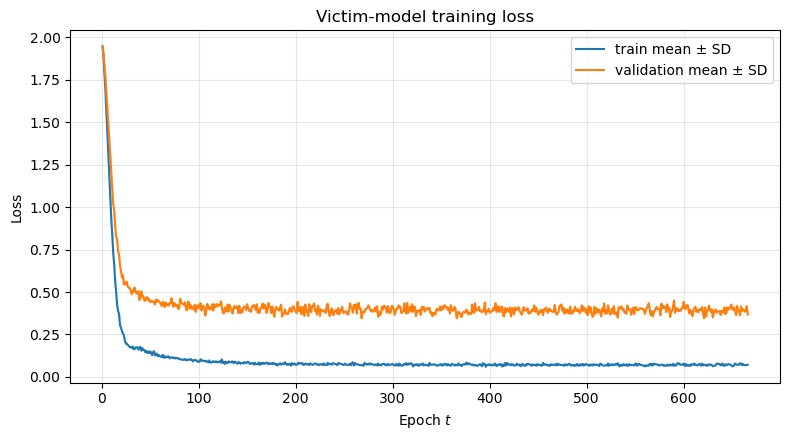

Victim accuracy over 1 seeds: 83.52% ± 0.00% SD


,n_seeds,clean_accuracy_mean,clean_accuracy_std,clean_accuracy_count,clean_accuracy_sem,n_train_epochs_mean,n_train_epochs_std,n_train_epochs_count,n_train_epochs_sem,n_val_epochs_mean,n_val_epochs_std,n_val_epochs_count,n_val_epochs_sem
0,1,0.835178,0.0,1,0.0,666.0,0.0,1,0.0,666.0,0.0,1,0.0


In [3]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display

seed_victim_runs = []
train_curve_rows = []
train_summary_rows = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for seed in SEEDS:
    print(f"Training victim model for seed={seed}")

    stats = experiment_train.run(
        data_dir='./data',
        dataset=DATASET,
        model_params=dict(
            label=MODEL_LABEL,
            model=MODEL_NAME,
            do_cache_adj_prep=True,
            n_filters=64,
            dropout=DROPOUT_VICTIM,
            svd_params=None,
            jaccard_params=None,
            gdc_params={"alpha": 0.15, "k": 64},
        ),
        train_params=dict(
            lr=LR_VICTIM,
            weight_decay=WEIGHT_DECAY_VICTIM,
            patience=PATIENCE_VICTIM,
            max_epochs=MAX_EPOCHS_VICTIM,
        ),
        binary_attr=False,
        make_undirected=True,
        seed=seed,
        artifact_dir='cache',
        model_storage_type='demo_custom_split',
        ppr_cache_params=dict(),
        device="cpu",
        data_device="cpu",
        display_steps=100,
        debug_level="info",
        custom_split_ratios=None,
    )

    model_seed = stats["model"]
    graph_seed = stats["graph"]
    idx_train_seed = stats["idx_train"]
    idx_val_seed = stats["idx_val"]
    idx_test_seed = stats["idx_test"]
    model_seed.eval()

    attr_matrix_seed, adj_matrix_seed, labels_raw_seed = graph_seed[:3]
    model_device = next(model_seed.parameters()).device
    row, col, value = adj_matrix_seed.coo()
    edge_index_seed = torch.stack([row, col], dim=0).long().to(model_device)
    edge_weight_seed = (
        torch.ones(edge_index_seed.size(1), dtype=torch.float32, device=model_device)
        if value is None else value.float().to(model_device)
    )
    attr_seed = attr_matrix_seed.float().to(model_device)
    labels_seed = labels_raw_seed.long().to(model_device)
    n_nodes_seed = int(adj_matrix_seed.sizes()[0])
    n_edges_directed_seed = int(adj_matrix_seed.nnz())
    n_undirected_seed = n_edges_directed_seed // 2
    n_edges_possible_seed = n_nodes_seed * (n_nodes_seed - 1) // 2
    clean_acc_seed = float(stats["accuracy"])

    context = {
        "seed": int(seed),
        "dataset": DATASET,
        "train_statistics": stats,
        "clean_acc": clean_acc_seed,
        "model": model_seed,
        "graph": graph_seed,
        "idx_train": idx_train_seed,
        "idx_val": idx_val_seed,
        "idx_test": idx_test_seed,
        "device": model_device,
        "n_nodes": n_nodes_seed,
        "n_edges_directed": n_edges_directed_seed,
        "n_edges_undirected": n_undirected_seed,
        "n_edges_possible": n_edges_possible_seed,
        "attr_matrix": attr_matrix_seed,
        "adj_matrix": adj_matrix_seed,
        "labels_raw": labels_raw_seed,
        "edge_index": edge_index_seed,
        "edge_weight": edge_weight_seed,
        "attr": attr_seed,
        "labels": labels_seed,
    }
    seed_victim_runs.append(context)

    for split, values in (
        ("train", stats.get("trace_train", [])),
        ("validation", stats.get("trace_val", [])),
    ):
        for epoch, loss in enumerate(values, start=1):
            train_curve_rows.append({
                "seed": int(seed),
                "split": split,
                "epoch": int(epoch),
                "loss": float(loss),
            })

    train_summary_rows.append({
        "seed": int(seed),
        "clean_accuracy": clean_acc_seed,
        "n_train_epochs": len(stats.get("trace_train", [])),
        "n_val_epochs": len(stats.get("trace_val", [])),
    })

SEED_CONTEXTS = seed_victim_runs

train_curve_df = pd.DataFrame(train_curve_rows)
train_summary_raw_df = pd.DataFrame(train_summary_rows)
train_summary_df = aggregate_over_seeds(
    train_summary_raw_df,
    group_cols=[],
    metric_cols=["clean_accuracy", "n_train_epochs", "n_val_epochs"],
)

curve_summary = (
    train_curve_df.groupby(["split", "epoch"], as_index=False)
    .agg(loss_mean=("loss", "mean"), loss_std=("loss", "std"), n_seeds=("seed", "nunique"))
)
curve_summary["loss_std"] = curve_summary["loss_std"].fillna(0.0)
curve_summary = curve_summary[curve_summary["n_seeds"] == N_SEEDS].copy()
if curve_summary.empty:
    raise RuntimeError("No victim-training epochs are shared by every configured seed.")

fig, ax = plt.subplots(figsize=(8, 4.5))
for split, group in curve_summary.groupby("split", sort=False):
    group = group.sort_values("epoch")
    add_mean_std_band(
        ax,
        group["epoch"],
        group["loss_mean"],
        group["loss_std"],
        label=f"{split} mean ± SD",
    )
ax.set_xlabel('Epoch $t$')
ax.set_ylabel("Loss")
ax.set_title("Victim-model training loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

clean_mean = train_summary_raw_df["clean_accuracy"].mean()
clean_std = train_summary_raw_df["clean_accuracy"].std(ddof=1) if N_SEEDS > 1 else 0.0
print(f"Victim accuracy over {N_SEEDS} seeds: {100*clean_mean:.2f}% ± {100*clean_std:.2f}% SD")
display(train_summary_df)


# RQ2 — Mining and Evaluating Harmful Edge Perturbations

RQ1 showed that the scalability of PR-BCD depends on restricting optimization to a sampled candidate block. RQ2 therefore studies whether victim-model evaluations can produce a useful harmfulness ranking over candidate edge flips.

For `subset_accuracy_drop`, one random subset of candidate flips is applied at a time. Let \(d_t=A(G)-A(G\oplus S_t)\) be the signed evaluation-accuracy drop of subset \(S_t\). For candidate edge \(e_i\), the canonical mined target is

\[
s_i
=
\frac{\sum_{t:e_i\in S_t}\max(0,d_t)}
     {\sum_t \mathbf{1}[e_i\in S_t]}.
\]

Thus, \(s_i\) is the **mean harmful subset drop observed when edge \(e_i\) was selected**. It corrects for unequal inclusion frequency.

This is an edge-associated subset score, not an isolated causal effect. Interactions, redundancy, and cancellation between jointly flipped edges remain part of the signal. The later oracle and PR-BCD experiments test whether the resulting noisy score nevertheless provides a useful ranking.

Every mining run stores:

- signed and harmful subset drops;
- inclusion counts;
- raw mean harmful scores;
- normalized scores in \([0,1]\);
- within-run percentile ranks;
- an explicit schema version and score definition.


In [4]:
from helpers.selector_pipeline_helpers import _edge_set
from IPython.display import display
import random
import pandas as pd


def _safe_config_value(value):
    text = f"{value:.12g}" if isinstance(value, float) else str(value)
    return (
        text.strip()
        .replace(" ", "")
        .replace("/", "-")
        .replace("\\", "-")
        .replace(".", "p")
        .replace("+", "")
        .replace("-", "m")
    )

def sample_random_candidates(num_nodes: int, count: int, *, seed: int,):
    """Sample candidate edges"""
    n_possible = num_nodes * (num_nodes - 1) // 2
    rng = random.Random(int(seed))
    sampled = set()
    while len(sampled) < count:
        u = rng.randrange(num_nodes)
        v = rng.randrange(num_nodes)
        if u == v:
            continue
        sampled.add((min(u, v), max(u, v)))
    return sampled

# ---------------------------------------------------------
# Build random candidate sets
# ---------------------------------------------------------

candidate_runs = []

for context in SEED_CONTEXTS:
    seed = int(context["seed"])
    n_nodes = int(context["n_nodes"])
    edge_index = context["edge_index"]
    orig_edges = _edge_set(edge_index)
    for candidate_set_size in CANDIDATE_SET_SIZES:
        candidate_seed = (seed + 20 * candidate_set_size + 17)
        random_candidates = sample_random_candidates(
            num_nodes=n_nodes,
            count=candidate_set_size,
            seed=candidate_seed,
        )
        candidates_for_config = list(random_candidates)
        random.Random(candidate_seed + 1).shuffle(candidates_for_config)
        n_delete_candidates = sum(edge in orig_edges for edge in candidates_for_config)
        n_add_candidates = (candidate_set_size - n_delete_candidates)
        candidate_runs.append({
            "seed": seed,
            "context": context,
            "candidate_set_size": candidate_set_size,
            "n_add_candidates": n_add_candidates,
            "n_delete_candidates": n_delete_candidates,
            "candidates": candidates_for_config,
        })

# ---------------------------------------------------------
# Summary table
# ---------------------------------------------------------

candidate_config_raw_df = pd.DataFrame([
    {
        key: value
        for key, value in run.items()
        if key not in {
            "context",
            "candidates",
        }
    }
    for run in candidate_runs
])
candidate_config_df = aggregate_over_seeds(
    candidate_config_raw_df,
    ["candidate_set_size"],
    ["n_add_candidates", "n_delete_candidates"],
)
display(candidate_config_df)
print(
    f"Created {len(candidate_runs)} candidate runs = "
    f"{len(SEEDS)} seeds × "
    f"{len(CANDIDATE_SET_SIZES)} candidate-set sizes."
)

,candidate_set_size,n_add_candidates_mean,n_add_candidates_std,n_add_candidates_count,n_delete_candidates_mean,n_delete_candidates_std,n_delete_candidates_count,n_add_candidates_sem,n_delete_candidates_sem,n_seeds
0,1000,999.0,0.0,1,1.0,0.0,1,0.0,0.0,1


Created 1 candidate runs = 1 seeds × 1 candidate-set sizes.


---
## §2  Subset Scoring

We run `N_SUBSETS` random subsets of the candidate pool and apply each subset jointly.

For each subset, the notebook stores both:

- the signed accuracy drop \(A(G)-A(G\oplus S)\);
- the harmful-only drop \(\max(0, A(G)-A(G\oplus S))\).

For every edge, the harmful drops are divided by the number of subsets in which that edge appeared. The canonical raw score is therefore the **mean harmful subset drop when selected**, rather than the accumulated sum.

The run also stores a max-normalized score in \([0,1]\), a percentile rank, the inclusion count, and an observed mask. Unobserved candidates are marked as unobserved rather than being treated as genuine zero-score edges.


---

## Experiment 1 — Direct Mining of Harmful Candidates

### Research objective

This experiment constructs candidate edge perturbations and evaluates them against the fixed victim model.

For `subset_accuracy_drop`, random candidate subsets are flipped jointly. Every selected edge receives the subset's harmful accuracy drop, and its final raw score is the average of those assigned drops over all subsets in which it appeared.

The resulting value is an observational, subset-associated harmfulness score. It should not be interpreted as the isolated accuracy effect of the edge.

### Execution block

The following cell:

- loads or computes versioned mining results;
- rejects caches created with the previous accumulated-sum target;
- filters candidates that were never observed;
- exposes raw, normalized, and percentile score representations;
- preserves signed-drop, harmful-drop, and inclusion-count diagnostics;
- creates the standardized `mining_runs` objects used downstream.


In [5]:
from pathlib import Path
from IPython.display import display

import numpy as np
import pandas as pd
import torch

from helpers.selector_pipeline_helpers import (
    mine_candidate_edge_scores,
    _dense_adj,
)
# ---------------------------------------------------------
# Score candidate sets
# ---------------------------------------------------------

mining_runs = []

for candidate_run in candidate_runs:

    context = candidate_run["context"]
    seed = int(candidate_run["seed"])
    model = context["model"]
    attr = context["attr"]
    edge_index = context["edge_index"]
    labels = context["labels"]
    idx_test = context["idx_test"]
    n_nodes = int(context["n_nodes"])
    device = attr.device
    candidates = list(candidate_run["candidates"])

    for scoring_mode in SCORING_MODES:
        print(f"\nScoring seed={seed} | "f"{candidate_run['candidate_set_size']} | "f"mode={scoring_mode}")
        result = mine_candidate_edge_scores(
            model=model,
            attr=attr,
            edge_index=edge_index,
            labels=labels,
            eval_idx=idx_test,
            candidates=candidates,
            n_nodes=n_nodes,
            mode=scoring_mode,
            subset_fraction=SUBSET_FRACTION,
            n_subsets=N_SUBSETS,
            seed=seed,
            device=device,
        )
        scored_candidates = list(candidates)

        score_raw = np.asarray(result["labels_raw"], dtype=np.float64).reshape(-1)
        score_norm = np.asarray(result["labels_norm"],dtype=np.float32).reshape(-1)

        exists = np.asarray(result.get("exists").reshape(-1))

        # Remove unobserved candidate edges, only relevant for subset accuracy drop scores.
        if scoring_mode == "subset_accuracy_drop":
            inclusion_count = np.asarray(result["inclusion_count"],dtype=np.int64).reshape(-1)
            observed_mask = inclusion_count > 0
        else:
            inclusion_count = np.ones(len(scored_candidates),dtype=np.int64)
            observed_mask = np.ones(len(scored_candidates),dtype=bool)

        n_total = len(scored_candidates)
        n_observed = int(observed_mask.sum())
        n_unobserved = n_total - n_observed
        scored_candidates = [
            candidate
            for candidate, observed
            in zip(scored_candidates, observed_mask)
            if observed
        ]
        score_raw = score_raw[observed_mask]
        score_norm = score_norm[observed_mask]
        exists = exists[observed_mask]
        inclusion_count = inclusion_count[observed_mask]
        src = np.asarray([u for u, _ in scored_candidates],dtype=np.int64)
        dst = np.asarray([v for _, v in scored_candidates],dtype=np.int64)
        n_positive = int(np.sum(score_norm > 0))
        clean_accuracy = float(result["clean_accuracy"])

        # Store results for RQ2 experiments and selector training
        run = {
            "seed": seed,
            "context": context,
            "candidate_set_size": candidate_run["candidate_set_size"],
            "scoring_mode": scoring_mode,
            "candidate_pool": candidates,
            "candidates": scored_candidates,
            "n_candidates_total": n_total,
            "n_cands": n_observed,
            "n_unobserved_candidates": n_unobserved,
            "score_raw": score_raw,
            "score_norm": score_norm,
            "labels_raw":score_raw,
            "labels_norm": score_norm,
            "labels_changed":
                torch.tensor(
                    score_norm,
                    dtype=torch.float32,
                    device=device,
                ),
            "src":
                torch.tensor(
                    src,
                    dtype=torch.long,
                    device=device,
                ),
            "dst":
                torch.tensor(
                    dst,
                    dtype=torch.long,
                    device=device,
                ),
            "exists":
                torch.tensor(
                    exists,
                    dtype=torch.float32,
                    device=device,
                ),
            "inclusion_count":inclusion_count,
            "clean_accuracy": clean_accuracy,
            "n_positive_labels": n_positive,
            "mining_result": result,
        }

        mining_runs.append(run)


Scoring seed=0 | 1000 | mode=endpoint
Clean accuracy: 0.8352
Candidates evaluated: 1000
Endpoint hits: 105/1000 (10.50%)

Scoring seed=0 | 1000 | mode=subset_accuracy_drop
Clean evaluation accuracy: 0.8352
Subset size: 50.0 (5% of 1000 candidates)
Subsets run: 1000
Accuracy drop per subset: mean=0.0022  max=0.0075  zero_rate=11.00%
Edges with score > 0: 1000/1000 (100.0%)


---
## §3  Continuous Score Distribution

The canonical raw label is the mean harmful subset accuracy drop observed when an edge was selected. It remains in the original accuracy-drop scale.

For selector training, the raw score is divided by the largest observed raw score within the mining run, producing `score_norm` in \([0,1]\). This is a relative harmfulness score, not a probability.

`score_percentile` stores the tie-aware within-run rank. `observed_mask` distinguishes evaluated zero-score candidates from candidates that were never included in any sampled subset.


### Analysis and plotting block

The following cells characterize the candidates obtained through direct mining.

The analysis examines:

- the number and proportion of positive labels;
- the balance between label-1 and label-0 candidates;
- edge additions versus edge deletions;
- the number of distinct affected endpoints;
- structural differences between label groups;
- the distribution of accuracy-drop scores;
- the overlap between local endpoint harmfulness and global accuracy effects.

This analysis addresses the first step of the RQ2 argument:

> Are harmful candidates observable through direct local or global evaluations, and how are they distributed within the candidate space?

These descriptive results do not yet establish that the candidates remain harmful when several perturbations are applied jointly. That question is addressed by the oracle and injection experiments.

In [6]:
# ============================================================
# RQ2: Compare graph/model properties of candidate edges
#
# endpoint:
#   group 1 = harmful
#   group 0 = non-harmful
#
# subset_accuracy_drop:
#   group 1 = top 10% raw score
#   group 0 = bottom 10% raw score
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import torch
import networkx as nx

from scipy.stats import mannwhitneyu, fisher_exact
from IPython.display import display

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

RQ2_SUBSET_EXTREME_FRACTION = 0.10

RQ2_LABEL_NODE_LEVEL_OUT_DIR = RQ2_OUT_DIR / "rq2_label_node_level_stats"
RQ2_LABEL_NODE_LEVEL_OUT_DIR.mkdir(parents=True,exist_ok=True)

# ------------------------------------------------------------
# Small helpers
# ------------------------------------------------------------

def _to_numpy(value):
    if torch.is_tensor(value):
        return value.detach().cpu().numpy()

    return np.asarray(value)


def _compute_clean_stats(context):
    """
    Compute edge node- level comparison statistics.

    Returns:
        degree
        PageRank
        prediction
        confidence
        margin
        true label
    """

    n_nodes = context["n_nodes"]
    edge_index = context["edge_index"]
    attr = context["attr"]
    adj = context["adj_matrix"]
    labels = context["labels"]
    model = context["model"]
    device = attr.device

    # Build nx Graph for degree and pagerank
    graph = nx.Graph()
    graph.add_nodes_from(range(n_nodes))
    graph.add_edges_from(
        (int(u),int(v))
        for u, v in zip(
            edge_index[0],
            edge_index[1],
        )
        if u != v
    )

    # Compute degree and pagerank from reconstructed nx Graph
    degree = np.asarray([graph.degree(node) for node in range(n_nodes)],dtype=float)
    pagerank_dict = nx.pagerank(graph,alpha=0.85)
    pagerank = np.asarray([pagerank_dict[node] for node in range(n_nodes)],dtype=float)

    model.eval()

    with torch.no_grad():
        # Compute confidence and margin
        logits = model(attr, adj)
        probabilities = torch.softmax(logits, dim=-1)
        prediction = logits.argmax(dim=-1)
        confidence = probabilities.max(dim=-1).values

        top2 = torch.topk(probabilities,k=2,dim=-1).values
        margin = (top2[:, 0] - top2[:, 1])

    return {
        "degree":degree,
        "pagerank":pagerank,
        "prediction":prediction.detach().cpu().numpy(),
        "confidence":confidence.detach().cpu().numpy(),
        "margin": margin.detach().cpu().numpy(),
        "labels": labels.detach().cpu().numpy(),
    }

# ------------------------------------------------------------
# Build candidate-level dataframe
# ------------------------------------------------------------

rows = []

for run_index, run in enumerate(mining_runs):

    seed = int(run["seed"])
    scoring_mode = str(run["scoring_mode"])
    context = run["context"]
    candidate_set_size = run["candidate_set_size"]

    clean_stats = _compute_clean_stats(context)
    candidates = list(run["candidates"])
    exists = _to_numpy(run["exists"]).astype(bool).reshape(-1)
    score_raw = np.asarray(run["score_raw"],dtype=float).reshape(-1)
    labels_changed = _to_numpy(run["labels_changed"]).astype(float).reshape(-1)
    n_candidates = run["n_cands"]

    # Make sure everything is aligned.
    if not (
        len(exists)
        == len(score_raw)
        == len(labels_changed)
        == n_candidates
    ):
        raise ValueError(
            f"Candidate arrays are not aligned for "
            f"seed={seed}, "
            f"size={candidate_set_size}, "
            f"mode={scoring_mode}."
        )

    # Build comparison groups from ordered scores on the candidate set.
    if scoring_mode == "endpoint":
        selected_indices = np.arange(n_candidates)
        comparison_groups = (labels_changed > 0.5).astype(int) # indicates which candidates are used
    else:
        n_valid = len(score_raw)
        n_per_group = int(np.floor(RQ2_SUBSET_EXTREME_FRACTION * n_valid))

        ordered_indices = np.argsort(score_raw)

        bottom_indices = (ordered_indices[:n_per_group])
        top_indices = (ordered_indices[-n_per_group:])
        selected_indices = np.concatenate([bottom_indices,top_indices])
        comparison_groups = np.concatenate([np.zeros(n_per_group,dtype=int),np.ones(n_per_group,dtype=int)])

        print(
            f"[subset] "
            f"seed={seed} | "
            f"size={candidate_set_size} | "
            f"valid={n_valid} | "
            f"bottom={n_per_group} | "
            f"top={n_per_group} | "
            f"bottom cutoff="
            f"{score_raw[bottom_indices[-1]]:.6f} | "
            f"top cutoff="
            f"{score_raw[top_indices[0]]:.6f}"
        )

    # ========================================================
    # Build selected candidate rows
    # ========================================================

    for local_index, candidate_index in enumerate(selected_indices):

        u, v = candidates[candidate_index]
        group = int(comparison_groups[local_index])

        # ----------------------------------------------------
        # Addition / deletion
        # ----------------------------------------------------

        action = ("delete" if exists[candidate_index] else "add")

        # Compute node level statistics for candidate comparison groups
        degree_u = float(clean_stats["degree"][u])
        degree_v = float(clean_stats["degree"][v])
        pagerank_u = float(clean_stats["pagerank"][u])
        pagerank_v = float(clean_stats["pagerank"][v])
        confidence_u = float(clean_stats["confidence"][u])
        confidence_v = float(clean_stats["confidence"][v])
        margin_u = float(clean_stats["margin"][u])
        margin_v = float(clean_stats["margin"][v])
        true_u = int(clean_stats["labels"][u])
        true_v = int(clean_stats["labels"][v])
        pred_u = int(clean_stats["prediction"][u])
        pred_v = int(clean_stats["prediction"][v])


        rows.append({
            "run_index": run_index,
            "seed": seed,
            "candidate_set_size":candidate_set_size,
            "scoring_mode":scoring_mode,
            "candidate_index": candidate_index,
            "u": u,
            "v": v,
            "group": group,
            "group_name":
                (
                    "harmful"
                    if scoring_mode == "endpoint"
                    and group == 1

                    else "non_harmful"
                    if scoring_mode == "endpoint"

                    else "top_10_percent"
                    if group == 1

                    else "bottom_10_percent"
                ),
            "score_raw": float(score_raw[candidate_index]),
            "action": action,

            "u_degree": degree_u,
            "v_degree": degree_v,
            "mean_degree": (degree_u + degree_v) / 2.0,

            "u_pagerank": pagerank_u,
            "v_pagerank": pagerank_v,
            "mean_pagerank": (pagerank_u + pagerank_v) / 2.0,

            "u_margin": margin_u,
            "v_margin": margin_v,
            "min_margin": min(margin_u, margin_v),

            "u_confidence": confidence_u,
            "v_confidence": confidence_v,

            "min_confidence": min(confidence_u, confidence_v),

            "same_true_class": bool(true_u == true_v),
            "same_clean_prediction": bool(pred_u == pred_v),

            "both_endpoints_clean_correct": bool(pred_u == true_u and pred_v == true_v),
        })

#
node_statistics_df = pd.DataFrame(rows)

result_rows = []
for (seed, candidate_set_size, scoring_mode), frame in node_statistics_df.groupby(
    ["seed", "candidate_set_size", "scoring_mode"]
):

    group_harmful = frame[frame["group"] == 1]
    group_nonharmful = frame[frame["group"] == 0]

    result_rows.append({
        "seed": seed,
        "candidate_set_size": candidate_set_size,
        "scoring_mode": scoring_mode,

        "group_1_n": len(group_harmful),
        "group_0_n": len(group_nonharmful),

        "group_1_prevalence": (
            float((frame["group"] == 1).mean())
            if scoring_mode == "endpoint"
            else np.nan
        ),

        "group_0_prevalence": (
            float((frame["group"] == 0).mean())
            if scoring_mode == "endpoint"
            else np.nan
        ),

        "group_1_raw_score": (
            float(group_harmful["score_raw"].mean())
            if scoring_mode == "subset_accuracy_drop"
            else np.nan
        ),

        "group_0_raw_score": (
            float(group_nonharmful["score_raw"].mean())
            if scoring_mode == "subset_accuracy_drop"
            else np.nan
        ),

        "group_1_min_confidence": float(group_harmful["min_confidence"].mean()),
        "group_0_min_confidence": float(group_nonharmful["min_confidence"].mean()),
        "difference_min_confidence": float(
            group_harmful["min_confidence"].mean()
            - group_nonharmful["min_confidence"].mean()
        ),

        "group_1_min_margin": float(group_harmful["min_margin"].mean()),
        "group_0_min_margin": float(group_nonharmful["min_margin"].mean()),
        "difference_min_margin": float(
            group_harmful["min_margin"].mean()
            - group_nonharmful["min_margin"].mean()
        ),

        "group_1_both_clean_correct": float(
            group_harmful["both_endpoints_clean_correct"].mean()
        ),
        "group_0_both_clean_correct": float(
            group_nonharmful["both_endpoints_clean_correct"].mean()
        ),
        "difference_both_clean_correct": float(
            group_harmful["both_endpoints_clean_correct"].mean()
            - group_nonharmful["both_endpoints_clean_correct"].mean()
        ),

        "group_1_same_true_class": float(group_harmful["same_true_class"].mean()),
        "group_0_same_true_class": float(group_nonharmful["same_true_class"].mean()),
        "difference_same_true_class": float(
            group_harmful["same_true_class"].mean()
            - group_nonharmful["same_true_class"].mean()
        ),

        "group_1_same_clean_prediction": float(
            group_harmful["same_clean_prediction"].mean()
        ),
        "group_0_same_clean_prediction": float(
            group_nonharmful["same_clean_prediction"].mean()
        ),
        "difference_same_clean_prediction": float(
            group_harmful["same_clean_prediction"].mean()
            - group_nonharmful["same_clean_prediction"].mean()
        ),

        "group_1_mean_degree": float(group_harmful["mean_degree"].mean()),
        "group_0_mean_degree": float(group_nonharmful["mean_degree"].mean()),
        "difference_mean_degree": float(
            group_harmful["mean_degree"].mean()
            - group_nonharmful["mean_degree"].mean()
        ),

        "group_1_mean_pagerank": float(group_harmful["mean_pagerank"].mean()),
        "group_0_mean_pagerank": float(group_nonharmful["mean_pagerank"].mean()),
        "difference_mean_pagerank": float(
            group_harmful["mean_pagerank"].mean()
            - group_nonharmful["mean_pagerank"].mean()
        ),
    })

rq2_node_level_label_statistics_raw = pd.DataFrame(result_rows)

rq2_node_level_label_statistics_results = (
    rq2_node_level_label_statistics_raw
    .drop(columns="seed")
    .groupby(["candidate_set_size", "scoring_mode"])
    .agg(["mean", "std"])
    .reset_index()
)

rq2_node_level_label_statistics_results.columns = [
    "_".join(str(part) for part in column if str(part))
    if isinstance(column, tuple)
    else column
    for column in rq2_node_level_label_statistics_results.columns
]

display(rq2_node_level_label_statistics_results)

rq2_node_level_label_statistics_results.to_csv(
    RQ2_LABEL_NODE_LEVEL_OUT_DIR
    / (
        f"rq2_node_level_label_statistics_{DATASET}"
        f"_candidates{'-'.join(map(str, CANDIDATE_SET_SIZES))}"
        f"_seeds{'-'.join(map(str, SEEDS))}.csv"
    ),
    index=False,
)

print(f"\nSaved to: {RQ2_LABEL_NODE_LEVEL_OUT_DIR.resolve()}")

[subset] seed=0 | size=1000 | valid=1000 | bottom=100 | top=100 | bottom cutoff=0.085375 | top cutoff=0.135572


,candidate_set_size,scoring_mode,group_1_n_mean,group_1_n_std,group_0_n_mean,group_0_n_std,group_1_prevalence_mean,group_1_prevalence_std,group_0_prevalence_mean,group_0_prevalence_std,...,group_0_mean_degree_mean,group_0_mean_degree_std,difference_mean_degree_mean,difference_mean_degree_std,group_1_mean_pagerank_mean,group_1_mean_pagerank_std,group_0_mean_pagerank_mean,group_0_mean_pagerank_std,difference_mean_pagerank_mean,difference_mean_pagerank_std
0,1000,endpoint,105.0,NaN,895.0,NaN,0.105,NaN,0.895,NaN,...,5.764246,NaN,-2.107103,NaN,0.000264,NaN,0.000353,NaN,-0.000089,NaN
1,1000,subset_accuracy_drop,100.0,NaN,100.0,NaN,NaN,NaN,NaN,NaN,...,4.875000,NaN,0.265000,NaN,0.000336,NaN,0.000314,NaN,0.000022,NaN



Saved to: E:\Masterarbeit\AttackerGNN\extendedPlotting\rq2_simple_endpoint_and_subset_stats


---

## Experiment 3 — Oracle Evaluation of Joint and Conditional Harmfulness

### Research objective

An edge that is harmful when evaluated individually does not necessarily remain harmful when combined with other perturbations.

The oracle experiment applies candidate perturbations cumulatively and compares two orderings:

1. candidates ordered by their mined harmfulness score;
2. candidates placed in a random order.

For an ordering \(e_1,\ldots,e_n\), define the cumulative perturbation block

\[
B_k=\{e_1,\ldots,e_k\}.
\]

The test accuracy after applying the first \(k\) candidates is

\[
A_k=A(G\oplus B_k).
\]

The experiment first determines whether mined candidates construct a stronger standalone attack than random candidates. It then examines whether each newly added flip block remains harmful under the perturbations already present.

### Execution block

Candidates are added cumulatively in steps of `BLOCK_STEP_ORACLE`.

For every step, the experiment records:

- the previous cumulative block size;
- the new cumulative block size;
- the number of newly added edges;
- accuracy before adding the new flip block;
- accuracy after adding the new flip block;
- cumulative accuracy drop;
- maximum accuracy drop observed so far.

The marginal conditional effect of the newly added flip block is

\[
\Delta A_k
=
A(B_{k-1})-A(B_k).
\]

The newly added block is classified as:

- **conditionally harmful** when \(\Delta A_k>0\);
- **neutral** when \(\Delta A_k\approx 0\);
- **cancelling** when \(\Delta A_k<0\).

With `BLOCK_STEP_ORACLE = 10`, the conditional effect refers to a block of up to ten newly added perturbations. Setting the value to one produces an individual-edge conditional analysis.

In [14]:
# ============================================================
# RQ2: Conjunction experiment accuracy trajectories
#
# endpoint:
#   label 1 first vs label 0 first vs random
#
# subset_accuracy_drop:
#   highest score first vs lowest score first vs random
# ============================================================

from helpers.selector_pipeline_helpers import accuracy
from tqdm.auto import tqdm

import numpy as np
import pandas as pd

from torch_sparse import SparseTensor

RQ2_CONJUNCTION_EXP_OUT_DIR = RQ2_OUT_DIR / "rq2_conjunction_experiment"
RQ2_CONJUNCTION_EXP_OUT_DIR.mkdir(parents=True,exist_ok=True)

BLOCK_STEP_CONJUNCTION = 10 # How many edges are flipped at once
conjunction_rows = []

# Flips one edge from the candidate set identified by the index
def _flip_candidate_sparse(adj, candidates, exists, candidate_index):
    u, v = candidates[candidate_index]
    delta = -1.0 if exists[candidate_index] else 1.0
    change = SparseTensor(
        row=torch.tensor([u, v], device=adj.device()),
        col=torch.tensor([v, u], device=adj.device()),
        value=torch.tensor([delta, delta], device=adj.device()),
        sparse_sizes=adj.sparse_sizes(),
    )
    return (adj + change).coalesce()


# Run conjunction experiment
for run_index, run in enumerate(mining_runs):

    seed = run["seed"]
    scoring_mode = run["scoring_mode"]
    candidate_set_size = run["candidate_set_size"]
    context = run["context"]

    candidates = list(run["candidates"])
    exists = run["exists"].numpy().astype(bool)
    score_raw = np.asarray(run["score_raw"], dtype=float)
    labels_changed = (run["labels_changed"]).numpy()
    n_candidates = run["n_cands"]

    # Build orderings for the evaluated run
    orders = {}
    if scoring_mode == "endpoint":
        # Endpoint label 1 first, then label 0
        orders["endpoint_label_desc"] = np.argsort(-labels_changed)
        # Endpoint label 0 first, then label 1
        orders["endpoint_label_asc"] = np.argsort(labels_changed)
    else:
        # Highest subset accuracy drop scores first
        orders["subset_score_desc"] = np.argsort(-score_raw)
        # Lowest subset accuracy drop score first
        orders["subset_score_asc"] = np.argsort(score_raw)

    # Random control ordering
    rng = np.random.default_rng(seed + run_index)
    orders["random"] = rng.permutation(n_candidates)

    # ========================================================
    # Evaluation steps
    # ========================================================

    block_sizes = list(range(BLOCK_STEP_CONJUNCTION, n_candidates + 1, BLOCK_STEP_CONJUNCTION))

    if not block_sizes or block_sizes[-1] != n_candidates:
        block_sizes.append(n_candidates)

    # ========================================================
    # Evaluate every ordering
    # ========================================================

    for ordering_name, order in orders.items():
        # Every ordering starts from the clean graph
        adj = context["adj_matrix"].clone()
        previous_k = 0

        # Append for the initial conjunction experiment epoch
        conjunction_rows.append({
            "seed": seed,
            "candidate_set_size": candidate_set_size,
            "scoring_mode": scoring_mode,
            "ordering": ordering_name,
            "k": 0,
            "victim_accuracy_drop": 0.0,
        })

        for k in tqdm(block_sizes,
            desc=f"seed={seed}, size={candidate_set_size}, mode={scoring_mode}, order={ordering_name}"
        ):
            # Only flip the newly added candidates
            for candidate_index in order[previous_k:k]:
                adj = _flip_candidate_sparse(adj, candidates, exists, candidate_index)
            # Compute victim accuracy after k flips
            victim_accuracy = float(accuracy(context["model"], context["attr"], context["labels"], context["idx_test"], edge_index=adj))

            # Compute victim accuracy drop from clean baseline after k flips
            victim_accuracy_drop = run["clean_accuracy"] - victim_accuracy
            conjunction_rows.append({
                "seed": seed,
                "candidate_set_size": candidate_set_size,
                "scoring_mode": scoring_mode,
                "ordering": ordering_name,
                "k": k,
                "victim_accuracy_drop": victim_accuracy_drop,
            })
            previous_k = k


# ============================================================
# Final dataframe
# ============================================================

rq2_conjunction_accuracy_raw = pd.DataFrame(
    conjunction_rows
)

rq2_conjunction_accuracy_results = (
    rq2_conjunction_accuracy_raw
    .drop(columns="seed")
    .groupby(["candidate_set_size", "scoring_mode", "ordering", "k"])
    .agg(["mean", "std"])
    .reset_index()
)

rq2_conjunction_accuracy_results.columns = [
    "_".join(str(part) for part in column if str(part))
    if isinstance(column, tuple)
    else column
    for column in rq2_conjunction_accuracy_results.columns
]

display(rq2_conjunction_accuracy_results)

rq2_conjunction_accuracy_results.to_csv(
    RQ2_CONJUNCTION_EXP_OUT_DIR
    / (
        f"rq2_conjunction_experiment_{DATASET}"
        f"_candidates{'-'.join(map(str, CANDIDATE_SET_SIZES))}"
        f"_seeds{'-'.join(map(str, SEEDS))}.csv"
    ),
    index=False,
)

print(f"\nSaved to: {RQ2_CONJUNCTION_EXP_OUT_DIR.resolve()}")

,seed,candidate_set_size,scoring_mode,ordering,k,victim_accuracy_drop
0,0,1000,endpoint,endpoint_label_desc,0,0.000000
1,0,1000,endpoint,endpoint_label_desc,10,0.002767
2,0,1000,endpoint,endpoint_label_desc,20,0.006719
3,0,1000,endpoint,endpoint_label_desc,30,0.010672
4,0,1000,endpoint,endpoint_label_desc,40,0.013834
...,...,...,...,...,...,...
4219,1,2500,subset_accuracy_drop,random,2460,0.040316
4220,1,2500,subset_accuracy_drop,random,2470,0.040316
4221,1,2500,subset_accuracy_drop,random,2480,0.040316
4222,1,2500,subset_accuracy_drop,random,2490,0.040316


### Analysis and plotting block

The oracle results are analyzed at two levels.

#### Step-level analysis

The step-level analysis reports the evolution of:

- cumulative attacked accuracy;
- marginal conditional effect \(\Delta A_k\);
- cumulative accuracy drop;
- maximum accuracy drop reached so far.

#### Run-level analysis

For each victim seed, candidate configuration, and ordering, the following measures are computed:

- proportion of conditionally harmful additions;
- proportion of neutral additions;
- proportion of cancelling additions;
- final cumulative accuracy drop;
- maximum achieved accuracy drop;
- number of edges at which the maximum drop occurs;
- number of edges required to reach fixed accuracy reductions;
- largest harmful marginal step;
- largest cancelling marginal step.

The main comparison is

\[
\text{mined ordering}
\quad\text{versus}\quad
\text{random ordering}.
\]

This experiment provides the central evidence for conditional harmfulness. It determines whether the mined ordering produces more damaging combinations and reveals how often harmfulness persists, disappears, or reverses as the perturbation block grows.

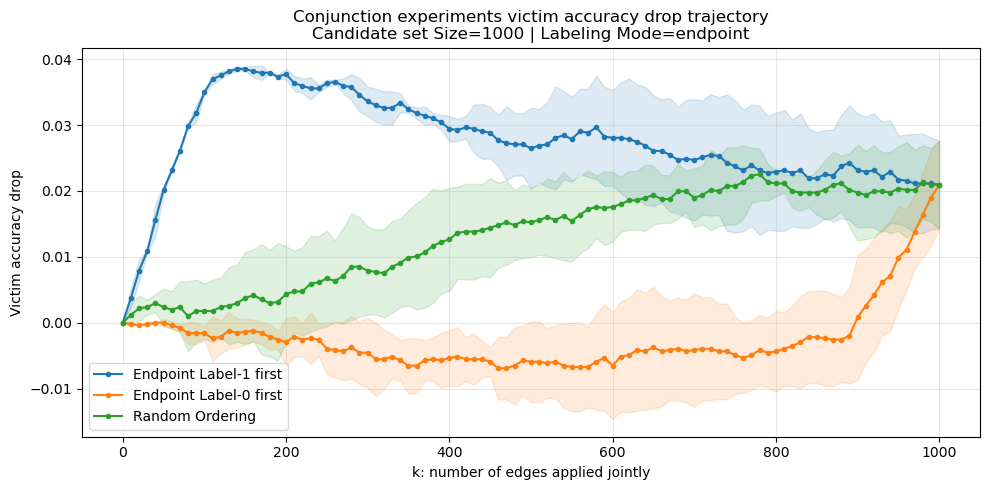

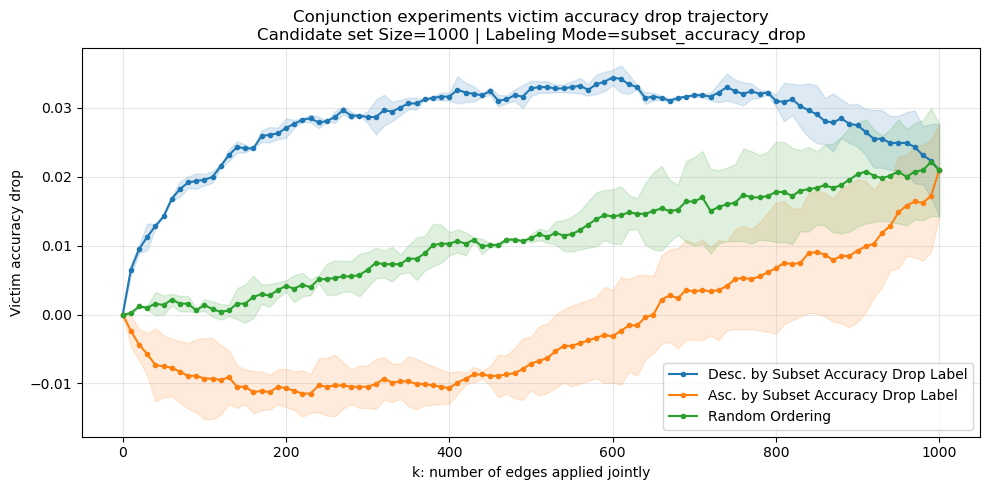

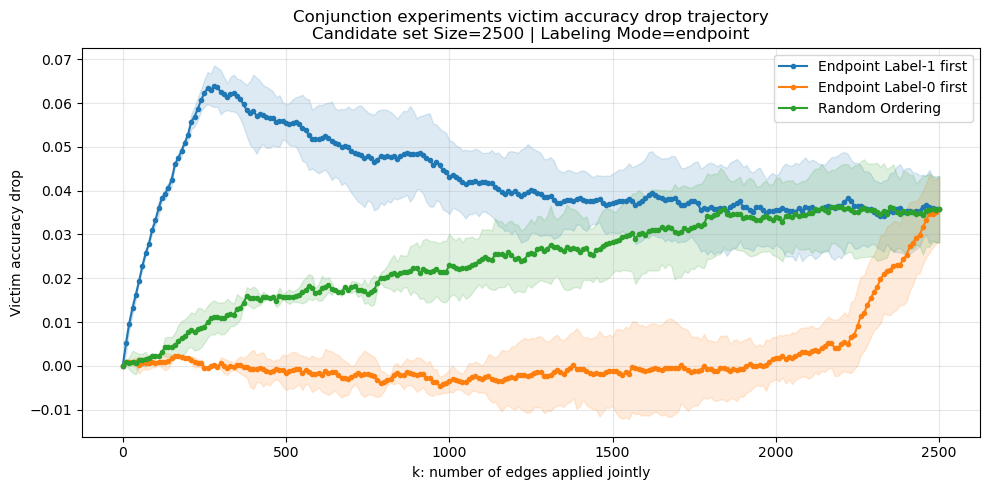

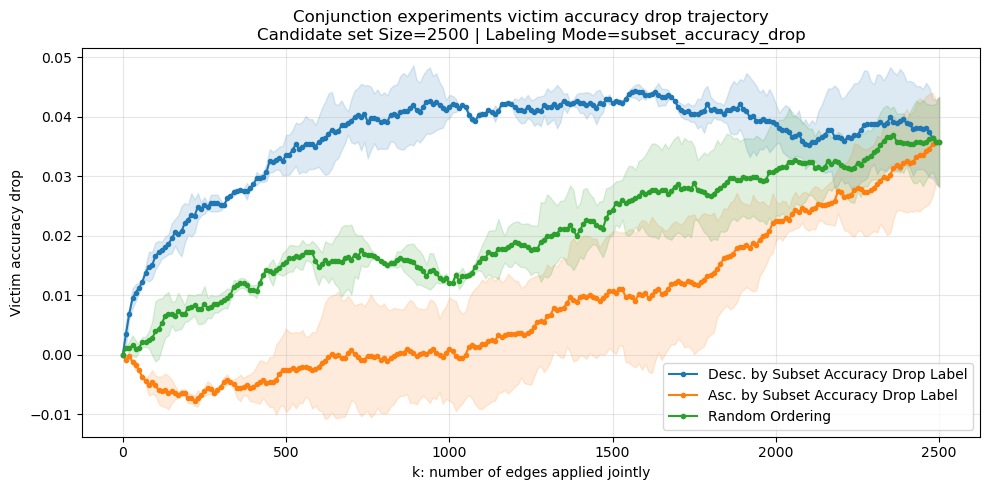

Saved conjunction experiment plots to: E:\Masterarbeit\AttackerGNN\extendedPlotting\conjunction_experiment


In [15]:
# ============================================================
# Plot conjunction experiment trajectories
#
# One plot per:
#   candidate_set_size × scoring_mode
#
# y-axis:
#   victim_accuracy_drop
#
# lines:
#   descending / ascending / random
#
# shading:
#   ±1 standard deviation across seeds
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

CONJUNCTION_PLOT_DIR = RQ2_CONJUNCTION_EXP_OUT_DIR / "plots"
CONJUNCTION_PLOT_DIR.mkdir(parents=True, exist_ok=True)

conjunction_plot_df = (
    rq2_conjunction_accuracy_raw
    .groupby(["candidate_set_size", "scoring_mode", "ordering", "k"], dropna=False)
    .agg(
        victim_accuracy_drop_mean=("victim_accuracy_drop", "mean"),
        victim_accuracy_drop_std=("victim_accuracy_drop", "std"),
        n_seeds=("seed", "nunique"),
    )
    .reset_index()
)

conjunction_plot_df["victim_accuracy_drop_std"] = (
    conjunction_plot_df["victim_accuracy_drop_std"]
    .fillna(0.0)
)


# ------------------------------------------------------------
# Labels for legend
# ------------------------------------------------------------

ordering_labels = {
    "endpoint_label_desc": "Endpoint Label-1 first",
    "endpoint_label_asc": "Endpoint Label-0 first",
    "subset_score_desc": "Desc. by Subset Accuracy Drop Label",
    "subset_score_asc": "Asc. by Subset Accuracy Drop Label",
    "random": "Random Ordering",
}


# ------------------------------------------------------------
# Plot one figure per candidate_set_size × scoring_mode
# ------------------------------------------------------------

for (candidate_set_size, scoring_mode), frame in conjunction_plot_df.groupby(
    ["candidate_set_size", "scoring_mode"],
    dropna=False,
):

    if scoring_mode == "endpoint":
        ordering_sequence = [
            "endpoint_label_desc",
            "endpoint_label_asc",
            "random",
        ]
    elif scoring_mode == "subset_accuracy_drop":
        ordering_sequence = [
            "subset_score_desc",
            "subset_score_asc",
            "random",
        ]
    else:
        continue

    fig, ax = plt.subplots(figsize=(10, 5))

    for ordering in ordering_sequence:

        ordering_df = frame[frame["ordering"] == ordering].copy()
        ordering_df = ordering_df.sort_values("k")

        x = ordering_df["k"].to_numpy(dtype=float)
        mean = ordering_df["victim_accuracy_drop_mean"].to_numpy(dtype=float)
        std = ordering_df["victim_accuracy_drop_std"].to_numpy(dtype=float)

        line = ax.plot(
            x,
            mean,
            marker="o",
            markersize=3,
            label=ordering_labels.get(ordering, ordering),
        )[0]

        ax.fill_between(
            x,
            mean - std,
            mean + std,
            alpha=0.15,
            color=line.get_color(),
        )

    ax.set_xlabel("k: number of edges applied jointly")
    ax.set_ylabel("Victim accuracy drop")
    ax.set_title(
        f"Conjunction experiments victim accuracy drop trajectory\n"
        f"Candidate set Size={candidate_set_size} | Labeling Mode={scoring_mode}"
    )

    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()

    safe_mode = "".join(
        c if c.isalnum() or c in "-_" else "_"
        for c in str(scoring_mode)
    )

    fig.savefig(
        CONJUNCTION_PLOT_DIR
        / f"conjunction_experiment__candN-{candidate_set_size}_{DATASET}_{safe_mode}.png",
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()


print("Saved conjunction experiment plots to:", CONJUNCTION_PLOT_DIR.resolve())

---

## Experiment 4 — Balanced Label-Conditioned PR-BCD Initialization

### Research objective

RQ1 showed that PR-BCD can only optimize candidates contained in its restricted search block. This experiment tests whether endpoint label-1 candidates define a more useful PR-BCD candidate space than label-0 or random candidates.

Three initial block types are compared:

1. endpoint label-1 candidates;
2. endpoint label-0 candidates;
3. random candidates from the full edge-perturbation space.

The label-conditioned blocks are balanced to a common size:

\[
b
=
\min
\left(
n_{\mathrm{label\,1}},
n_{\mathrm{label\,0}}
\right).
\]

The larger label group is sampled without replacement to match the smaller group. The random control receives the same block size.

This balancing ensures that attack differences cannot be attributed to different numbers of available candidate coordinates.


### Execution block

Each of the three initializations is evaluated under two optimization conditions.

#### Fixed candidate block

The candidate block remains fixed throughout optimization. PR-BCD can update the relaxed weights but cannot introduce new candidate edges.

This condition isolates candidate quality:

> Does a block of locally harmful candidates provide a better restricted optimization space than an equally sized label-0 or random block?

#### Random coordinate resampling

PR-BCD performs its standard WeightOnly retention and random refill procedure.

This condition evaluates whether the initial candidate advantage persists when the attack can introduce new coordinates.

The resulting six conditions are:

1. label 1 with a fixed block;
2. label 1 with random resampling;
3. label 0 with a fixed block;
4. label 0 with random resampling;
5. random initialization with a fixed block;
6. random initialization with random resampling.

Within each victim seed and repeat, the attack configuration and stochastic seeds are paired as closely as possible.

In [ ]:
# ============================================================
# RQ2: PRBCD initial-block experiment
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import torch
from IPython.display import display

from experiments import experiment_global_attack_direct
from rgnn_at_scale.attacks.prbcd import PRBCD

RQ2_INITIAL_BLOCK_EXP_OUT_DIR = RQ2_OUT_DIR / "rq2_initial_block"
RQ2_INITIAL_BLOCK_EXP_OUT_DIR.mkdir(parents=True,exist_ok=True)

# Experiment Parameters
RQ2_BLOCK_SUBSET_EXTREME_FRACTION = 0.10

# PR-BCD Parameters
RQ2_BLOCK_ATTACK_BUDGET_FRACTION = 0.003
RQ2_BLOCK_EPOCHS = 100
RQ2_BLOCK_RESAMPLING_EPOCHS = 50 # Only when resampling is not disabled

# Helper functions
def _sample_random_candidates(candidates, n, seed):
    rng = np.random.default_rng(seed)
    indices = rng.choice(len(candidates), size=n, replace=False)
    return [candidates[i] for i in indices]

def _candidates_to_linear_ids(candidates, n_nodes):
    pairs = torch.tensor(candidates, dtype=torch.long).T
    linear_ids = PRBCD.pairs_to_linear_uppertri(pairs, n_nodes).long()
    return linear_ids

def _to_numpy(values):
    if torch.is_tensor(values):
        return values.detach().cpu().numpy().astype(float).reshape(-1)

    return np.asarray([
        float(torch.as_tensor(value).detach().cpu().item())
        for value in values
    ])


# Run PR-BCD with initial blocks supplied
prbcd_initial_block_rows = []
for run in mining_runs:

    # Initial Block construction required variables
    seed = run["seed"]
    candidate_set_size = run["candidate_set_size"]
    scoring_mode = run["scoring_mode"]
    candidates = list(run["candidates"])

    # PR-BCD required variables
    context = run["context"]
    graph = context["graph"]
    n_nodes = context["n_nodes"]
    n_edges = context["n_edges_undirected"]
    n_possible_edges = context["n_edges_possible"]
    attack_budget = max(1, round(RQ2_BLOCK_ATTACK_BUDGET_FRACTION * n_edges))
    fine_tune_epochs = RQ2_BLOCK_EPOCHS - RQ2_BLOCK_RESAMPLING_EPOCHS

    # Build PR-BCD blocks for both labeling objectives
    if scoring_mode == "endpoint":
        labels = run["labels_changed"].detach().cpu().numpy()
        group_harmful = [
            candidate
            for candidate, label in zip(candidates, labels)
            if label > 0.5
        ]
        group_nonharmful = [
            candidate
            for candidate, label in zip(candidates, labels)
            if label < 0.5
        ]
        block_size = len(group_harmful)
        if len(group_nonharmful) < block_size:
            raise ValueError(
                f"Not enough group_nonharmful candidates for seed={seed}, "
                f"size={candidate_set_size}."
            )
        blocks = {
            "group_harmful": group_harmful,
            "group_nonharmful": _sample_random_candidates(
                group_nonharmful,
                block_size,
                seed,
            ),
        }

    else:
        scores = np.asarray(run["labels_changed"], dtype=float)
        block_size = int(np.floor(RQ2_BLOCK_SUBSET_EXTREME_FRACTION * len(candidates)))
        order = np.argsort(scores)
        blocks = {
            "group_nonharmful": [
                candidates[i]
                for i in order[:block_size]
            ],
            "group_harmful": [
                candidates[i]
                for i in order[-block_size:]
            ],
        }

    # From initial PR-BCD implementation.
    if block_size <= attack_budget:
        raise ValueError(
            f"block_size={block_size} must be larger "
            f"than attack_budget={attack_budget}."
        )

    # Convert blocks to linear ids as in original PR-BCD search space.
    block_as_linear_ids = {block_name: _candidates_to_linear_ids(block_candidates,n_nodes)
        for block_name, block_candidates in blocks.items()
    }

    # Sample random edges like PR-BCD random block sampling
    # Guarantees unique edges and consistent block size
    block_as_linear_ids["group_random"] = torch.randperm(n_possible_edges)[:block_size]

    # Run PR-BCD for harmful, nonharmful and random blocks
    for block_name, linear_ids in block_as_linear_ids.items():
        for resampling_enabled in [True, False]:

            # Pass attack parameters and blocks
            attack_params = {
                "block_size": block_size,
                "epochs": RQ2_BLOCK_EPOCHS,
                "fine_tune_epochs": fine_tune_epochs,
                "with_early_stopping": False,
                "keep_heuristic": "WeightOnly",
                "loss_type": "tanhMargin",
                "initial_block_label": block_name,
                "initial_block_linear_ids": linear_ids,
                "resampling_enabled": resampling_enabled,
                "attack_sampling_seed": seed,
            }

            print(
                f"PRBCD | seed={seed} | label_type={scoring_mode}"
                f"Candidate set size={candidate_set_size} | "
                f"block={block_name} | resampling={resampling_enabled}"
            )

            result = experiment_global_attack_direct.run(
                graph=graph,
                data_dir="./data",
                dataset=DATASET,
                attack="PRBCD",
                attack_params=attack_params,
                selector_params={},
                epsilons=[RQ2_BLOCK_ATTACK_BUDGET_FRACTION],
                binary_attr=False,
                make_undirected=True,
                seed=seed,
                artifact_dir="cache",
                pert_adj_storage_type="evasion_global_adj",
                pert_attr_storage_type="evasion_global_attr",
                model_label=MODEL_LABEL,
                model_storage_type="demo_custom_split", # Model storage is bypassed.
                device="cpu",
                data_device="cpu",
                debug_level="info",
                semi=True,
                use_cert="none",
            )

            accuracy_values = result["attack_statistics"]["accuracy"]

            if accuracy_values is None:
                raise RuntimeError(
                    "Could not find PRBCD accuracy trajectory."
                )

            accuracies = _to_numpy(accuracy_values)

            for i, victim_accuracy in enumerate(accuracies):
                prbcd_initial_block_rows.append({
                    "seed": seed,
                    "candidate_set_size": candidate_set_size,
                    "scoring_mode": scoring_mode,
                    "resampling_enabled": resampling_enabled,
                    "block": block_name,
                    "block_size": block_size,
                    "prbcd_epoch": i - 1,
                    "accuracy_drop": run["clean_accuracy"] - victim_accuracy,
                })


rq2_prbcd_block_accuracy_raw = pd.DataFrame(prbcd_initial_block_rows)
display(rq2_prbcd_block_accuracy_raw)

rq2_prbcd_block_accuracy_results = (
    rq2_prbcd_block_accuracy_raw
    .drop(columns="seed")
    .groupby([
        "candidate_set_size",
        "scoring_mode",
        "block",
        "resampling_enabled",
        "prbcd_epoch",
    ])
    .agg(["mean", "std"])
    .reset_index()
)

rq2_prbcd_block_accuracy_results.columns = [
    "_".join(str(part) for part in column if str(part))
    if isinstance(column, tuple)
    else column
    for column in rq2_prbcd_block_accuracy_results.columns
]

display(rq2_prbcd_block_accuracy_results)

rq2_prbcd_block_accuracy_results.to_csv(
    RQ2_INITIAL_BLOCK_EXP_OUT_DIR
    / (
        f"rq2_initial_block_experiment_{DATASET}"
        f"_candidates{'-'.join(map(str, CANDIDATE_SET_SIZES))}"
        f"_seeds{'-'.join(map(str, SEEDS))}.csv"
    ),
    index=False,
)

print(f"\nSaved to: {RQ2_INITIAL_BLOCK_EXP_OUT_DIR.resolve()}")

### Analysis and plotting block

The following cell evaluates attack strength, optimization dynamics, and block retention.

#### Attack outcomes

The analysis reports:

- final attacked accuracy;
- final accuracy drop;
- minimum relaxed accuracy;
- maximum relaxed accuracy drop;
- integrated accuracy drop;
- number of epochs required to reach fixed accuracy reductions.

#### Candidate utilization

The analysis also reports:

- fraction of final perturbations originating from the initial block;
- fraction of final perturbations carrying label 1;
- fraction of final perturbations carrying label 0;
- retention of the original block over optimization epochs;
- label composition of the final candidate block;
- label composition of the final discrete perturbation set.

#### Main comparisons

The paired comparisons are:

\[
\text{label 1}
\quad\text{versus}\quad
\text{label 0},
\]

\[
\text{label 1}
\quad\text{versus}\quad
\text{random},
\]

and

\[
\text{fixed block}
\quad\text{versus}\quad
\text{random resampling}.
\]

This experiment connects local harmfulness directly to the candidate-coverage limitation identified in RQ1.

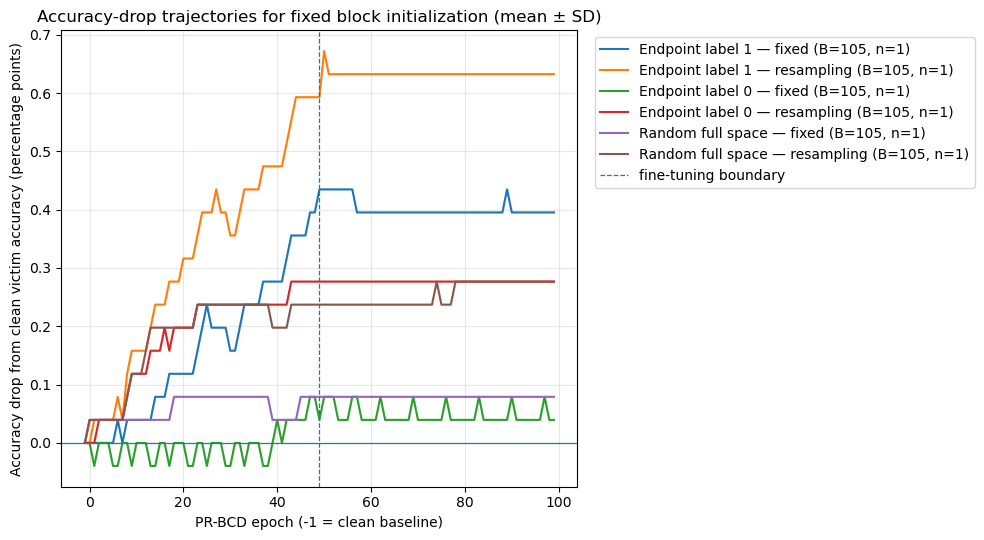

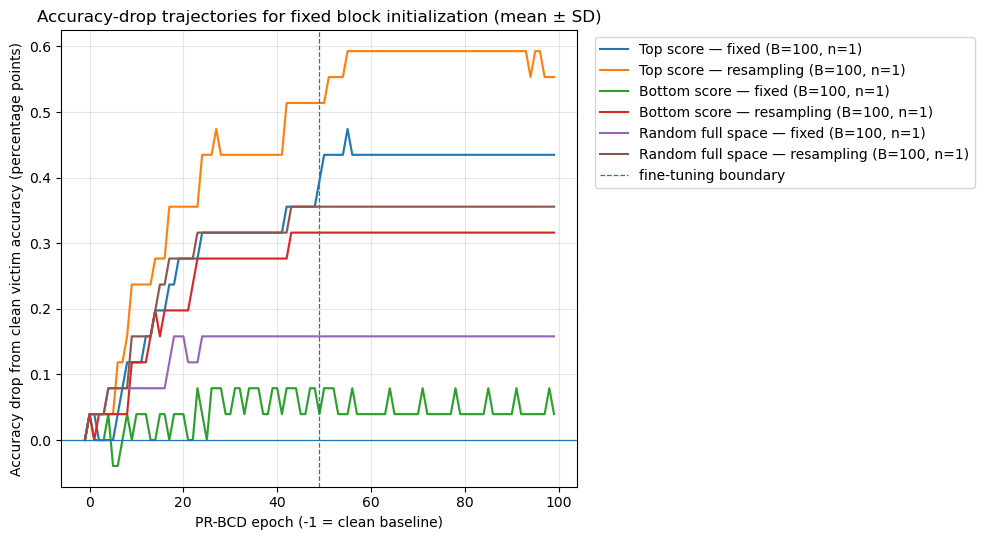

In [8]:
# ============================================================
# RQ2: Plot PRBCD initial-block trajectories
# ============================================================

import matplotlib.pyplot as plt

RQ2_INITIAL_BLOCK_PLOT_DIR = RQ2_INITIAL_BLOCK_EXP_OUT_DIR / "plots"
RQ2_INITIAL_BLOCK_PLOT_DIR.mkdir(parents=True, exist_ok=True)

# Mean and standard deviation across seeds
trajectory_summary = (
    rq2_prbcd_block_accuracy_raw
    .groupby([
        "candidate_set_size",
        "scoring_mode",
        "block",
        "resampling_enabled",
        "prbcd_epoch",
    ])["accuracy_drop"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

for scoring_mode in ["endpoint", "subset_accuracy_drop"]:

    frame = trajectory_summary[trajectory_summary["scoring_mode"] == scoring_mode]

    for candidate_set_size, size_df in frame.groupby("candidate_set_size"):

        fig, ax = plt.subplots(figsize=(10, 5.5))

        for (block, resampling_enabled), condition_df in size_df.groupby([
            "block",
            "resampling_enabled",
        ]):

            condition_df = condition_df.sort_values("prbcd_epoch")

            if scoring_mode == "endpoint":
                block_label = {
                    "group_harmful": "Endpoint label 1",
                    "group_nonharmful": "Endpoint label 0",
                    "group_random": "Random full space",
                }[block]
            else:
                block_label = {
                    "group_harmful": "Top score",
                    "group_nonharmful": "Bottom score",
                    "group_random": "Random full space",
                }[block]

            resampling_label = (
                "resampling"
                if resampling_enabled
                else "fixed"
            )

            block_size = int(
                rq2_prbcd_block_accuracy_raw.loc[
                    (rq2_prbcd_block_accuracy_raw["candidate_set_size"] == candidate_set_size)
                    & (rq2_prbcd_block_accuracy_raw["scoring_mode"] == scoring_mode)
                    & (rq2_prbcd_block_accuracy_raw["block"] == block),
                    "block_size",
                ].iloc[0]
            )

            n_seeds = int(condition_df["count"].max())

            label = (
                f"{block_label} — {resampling_label} "
                f"(B={block_size}, n={n_seeds})"
            )

            x = condition_df["prbcd_epoch"].to_numpy()
            mean = condition_df["mean"].to_numpy() * 100
            std = condition_df["std"].fillna(0).to_numpy() * 100

            line = ax.plot(
                x,
                mean,
                label=label,
            )[0]

            ax.fill_between(
                x,
                mean - std,
                mean + std,
                alpha=0.15,
                color=line.get_color(),
            )

        ax.axvline(
            RQ2_BLOCK_RESAMPLING_EPOCHS - 1,
            linestyle="--",
            linewidth=0.9,
            label="fine-tuning boundary",
        )

        ax.axhline(
            0,
            linewidth=0.9,
        )

        ax.set_xlabel("PR-BCD epoch (-1 = clean baseline)")
        ax.set_ylabel("Accuracy drop from clean victim accuracy ""(percentage points)")
        ax.set_title("Accuracy-drop trajectories for fixed block initialization (mean ± SD)")

        ax.grid(
            True,
            alpha=0.3,
        )

        ax.legend(
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
        )

        plot_path = (
            RQ2_INITIAL_BLOCK_PLOT_DIR
            / f"rq2_initial_block_{DATASET}_{scoring_mode}_candN-{candidate_set_size}.png"
        )

        fig.savefig(
            plot_path,
            dpi=300,
            bbox_inches="tight",
        )

        fig.tight_layout()
        plt.show()

---

# RQ2 Synthesis — From Individual Harmfulness to PR-BCD Usefulness

The RQ2 experiments investigate progressively stronger notions of harmfulness.

## 1. Individual harmfulness

Direct mining determines whether an edge causes observable damage when evaluated individually.

Endpoint mining captures local harmfulness:

\[
e
\rightarrow
H_{\mathrm{loc}}(e;G).
\]

Accuracy-drop mining captures an individual global effect:

\[
e
\rightarrow
A(G)-A(G\oplus e).
\]

## 2. Conditional harmfulness under joint perturbations

The oracle experiment determines whether mined candidates continue to contribute damage after other perturbations have already been applied:

\[
e
\rightarrow
H_{\mathrm{cond}}(e\mid B;G).
\]

This separates conditionally harmful, neutral, and cancelling additions.

## 3. Conditional harmfulness during optimization

The injection experiment evaluates whether a mined candidate remains useful inside an evolving PR-BCD state:

\[
e
\rightarrow
H_{\mathrm{inj}}(e\mid S_t).
\]

This measures harmfulness under the current block composition, relaxed weights, and optimization history.

## 4. Candidate-space usefulness

The balanced initialization experiment evaluates whether local harmfulness information improves the restricted PR-BCD search space:

\[
H_{\mathrm{loc}}
\rightarrow
\text{label-informed block}
\rightarrow
\text{PR-BCD attack effectiveness}.
\]

Together, the experiments test the chain

\[
\boxed{
\text{individually harmful}
\rightarrow
\text{conditionally harmful}
\rightarrow
\text{useful as a PR-BCD candidate}
}
\]

The results also decompose candidate-block quality into two components:

\[
\boxed{
\text{candidate coverage}
+
\text{candidate compatibility}
}
\]

Endpoint label-1 initialization primarily addresses candidate coverage. The oracle and injection experiments examine whether the selected candidates remain compatible and harmful under joint or algorithmic conditions.

## Construct and persist the RQ3 source-subgraph candidate-mining sweep

This block now uses two independent cache layers:

1. **Candidate-pool cache:** stores the selected source nodes and the maximum
   sampled candidate pool once per victim seed, subgraph method, subgraph seed,
   and subgraph fraction.
2. **Label cache:** stores the expensive victim-query labels once per exact
   candidate size and scoring mode.

The sweep is resumable at configuration level: existing artifacts are loaded
individually, and only missing or explicitly invalidated configurations are
computed again. Progress is written continuously to a CSV manifest.


### Whole-graph selector condition (`subgraph_fraction = 1.0`)

When the requested fraction is `1.0`, the pipeline uses every graph node and every structural edge for selector message passing. Candidate pairs are still sampled from the complete upper-triangular pair space and labeled with the same resumable per-configuration cache. `subgraph_seed` remains useful as an independent candidate-pool sampling replicate; the graph itself is not resampled.


In [37]:
from helpers.selector_pipeline_helpers import train_selector
import torch

RQ3_SELECTOR_TRAINING_STATS_OUT_DIR = RQ3_OUT_DIR / "rq3_selector_training_stats"
RQ3_SELECTOR_TRAINING_STATS_OUT_DIR.mkdir(parents=True, exist_ok=True)

selector_training_rows = []
for run in mining_runs:

    context = run["context"]
    device = context["attr"].device

    attr = context["attr"].to(device)
    edge_index_struct = context["edge_index"]

    # Construct edge index tensor of labeled candidate edges
    src = run["src"].long().to(device)
    dst = run["dst"].long().to(device)
    edge_index_lab = torch.stack([src, dst],dim=0)

    # Extract label vector for labeled candidate edges
    y_label = run["labels_changed"]
    print(
        f"\nTraining selector | "
        f"seed={run['seed']} | "
        f"candidates={run['candidate_set_size']} | "
        f"mode={run['scoring_mode']} | "
        f"training pairs={y_label.numel()}"
    )

    # Train Selector
    selector_model = train_selector(
        attr=attr,
        edge_index_struct=edge_index_struct,
        edge_index_lab=edge_index_lab,
        y_label=y_label,
        label_mode=run["scoring_mode"],
        device=device,
        num_epochs=SCORER_EPOCHS,
        hidden_dim=SCORER_HIDDEN,
        out_dim=SCORER_HIDDEN,
        lr=SCORER_LR,
        weight_decay=5e-4,
        early_stop=True,
        patience=PATIENCE,
        split_ratios=(0.70, 0.15, 0.15),
    )

    history = selector_model.training_history

    # Log Train and Validation Losses for later plotting
    for epoch, (train_loss, val_loss) in enumerate(
        zip(history["train_losses"], history["val_losses"]),
        start=1,
    ):
        selector_training_rows.append({
            "seed": run["seed"],
            "candidate_set_size": run["candidate_set_size"],
            "scoring_mode": run["scoring_mode"],
            "epoch": epoch,
            "train_loss": train_loss,
            "validation_loss": val_loss,
            "best_epoch": history["best_epoch"],
            "is_best_epoch": epoch == history["best_epoch"],
        })

    run["selector_model"] = selector_model

    run["edge_index_lab"] = edge_index_lab.detach().cpu()
    run["y_label"] = y_label.detach().cpu()

selector_training_stats_raw = pd.DataFrame(selector_training_rows)
display(selector_training_stats_raw)

# ------------------------------------------------------------
# Aggregate training trajectories across seeds
# ------------------------------------------------------------

selector_training_stats_results = (
    selector_training_stats_raw
    .groupby([
        "candidate_set_size",
        "scoring_mode",
        "epoch",
    ])
    .agg(
        train_loss_mean=("train_loss", "mean"),
        train_loss_std=("train_loss", "std"),
        validation_loss_mean=("validation_loss", "mean"),
        validation_loss_std=("validation_loss", "std"),
        n_seeds=("seed", "nunique"),
    )
    .reset_index()
)

display(selector_training_stats_results)

selector_training_stats_raw.to_csv(
    RQ3_SELECTOR_TRAINING_STATS_OUT_DIR
    / (
        f"rq3_selector_training_stats_raw_{DATASET}"
        f"_candidates{'-'.join(map(str, CANDIDATE_SET_SIZES))}"
        f"_seeds{'-'.join(map(str, SEEDS))}.csv"
    ),
    index=False,
)

selector_training_stats_results.to_csv(
    RQ3_SELECTOR_TRAINING_STATS_OUT_DIR
    / (
        f"rq3_selector_training_stats_{DATASET}"
        f"_candidates{'-'.join(map(str, CANDIDATE_SET_SIZES))}"
        f"_seeds{'-'.join(map(str, SEEDS))}.csv"
    ),
    index=False,
)

print(
    f"\nSaved selector training statistics to: "
    f"{RQ3_SELECTOR_TRAINING_STATS_OUT_DIR.resolve()}"
)



Training selector | seed=0 | candidates=1000 | mode=endpoint | training pairs=1000
[LP-GNN] Epoch 001/200 | train_loss=1.4514 | val_loss=1.2450 |  | early_stopping_metric=val_ap | current_best=0.1414 | patience_left=20 | new_best
[LP-GNN] Epoch 020/200 | train_loss=0.8069 | val_loss=1.3382 |  | early_stopping_metric=val_ap | current_best=0.2063 | patience_left=20
[LP-GNN] Epoch 040/200 | train_loss=0.7932 | val_loss=1.4216 |  | early_stopping_metric=val_ap | current_best=0.2063 | patience_left=19
Selector Training stopping at epoch 59. Best early_stopping_metric=0.2063 at epoch 6.

Training selector | seed=0 | candidates=1000 | mode=subset_accuracy_drop | training pairs=1000
[LP-GNN] Epoch 001/200 | train_loss=0.6948 | val_loss=0.6901 |  | early_stopping_metric=val_loss | current_best=0.6901 | patience_left=20 | new_best
[LP-GNN] Epoch 020/200 | train_loss=0.6865 | val_loss=0.6872 |  | early_stopping_metric=val_loss | current_best=0.6871 | patience_left=20
[LP-GNN] Epoch 040/200 | tra

,seed,candidate_set_size,scoring_mode,epoch,train_loss,validation_loss,best_epoch,is_best_epoch
0,0,1000,endpoint,1,1.451387,1.244957,6,False
1,0,1000,endpoint,2,1.429183,1.265627,6,False
2,0,1000,endpoint,3,1.399977,1.298090,6,False
3,0,1000,endpoint,4,1.376500,1.256548,6,False
4,0,1000,endpoint,5,1.326748,1.241910,6,False
...,...,...,...,...,...,...,...,...
113,0,1000,subset_accuracy_drop,55,0.671864,0.699318,8,False
114,0,1000,subset_accuracy_drop,56,0.671227,0.700449,8,False
115,0,1000,subset_accuracy_drop,57,0.671367,0.695658,8,False
116,0,1000,subset_accuracy_drop,58,0.670994,0.695808,8,False


,candidate_set_size,scoring_mode,epoch,train_loss_mean,train_loss_std,validation_loss_mean,validation_loss_std,n_seeds
0,1000,endpoint,1,1.451387,0.0,1.244957,0.0,1
1,1000,endpoint,2,1.429183,0.0,1.265627,0.0,1
2,1000,endpoint,3,1.399977,0.0,1.298090,0.0,1
3,1000,endpoint,4,1.376500,0.0,1.256548,0.0,1
4,1000,endpoint,5,1.326748,0.0,1.241910,0.0,1
...,...,...,...,...,...,...,...,...
113,1000,subset_accuracy_drop,55,0.671864,0.0,0.699318,0.0,1
114,1000,subset_accuracy_drop,56,0.671227,0.0,0.700449,0.0,1
115,1000,subset_accuracy_drop,57,0.671367,0.0,0.695658,0.0,1
116,1000,subset_accuracy_drop,58,0.670994,0.0,0.695808,0.0,1



Saved selector training statistics to: E:\Masterarbeit\AttackerGNN\extendedPlotting\final_runs\RQ3\rq3_selector_test_metrics\rq3_selector_training_stats


### RQ3 selector-training statistics across the complete subgraph sweep

The following diagnostic cells evaluate every trained selector in `RQ3_SUBGRAPH_TRAINING_RUNS`. The later fixed-block experiment still uses only the configured primary selector through `lp_training_runs`, while §8 uses the complete selector registry.


In [36]:
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    r2_score,
    ndcg_score,
)

# Generated by ChatGPT 5.1
# Calculates pearson Correlation
def safe_correlation(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) < 2:
        return np.nan

    if np.std(x) <= 1e-12 or np.std(y) <= 1e-12:
        return np.nan

    return float(np.corrcoef(x, y)[0, 1])

# Generated by ChatGPT 5.1
# Calculates Spearman Correlation
def spearman_correlation(x, y):
    x_rank = pd.Series(x).rank(method="average").to_numpy()
    y_rank = pd.Series(y).rank(method="average").to_numpy()

    return safe_correlation(x_rank, y_rank)

RQ3_SELECTOR_TEST_METRICS = RQ3_OUT_DIR / "rq3_selector_test_metrics"
RQ3_SELECTOR_TEST_METRICS.mkdir(parents=True, exist_ok=True)

# ============================================================
# Evaluate untouched test sets
# ============================================================

selector_on_test_rows = []

for run in mining_runs:

    model = run["selector_model"]
    history = model.training_history
    device = next(model.parameters()).device
    context = run["context"]
    attr = context["attr"].to(device)

    edge_index_struct = context["edge_index"].long().to(device)
    src = run["src"].long().to(device)
    dst = run["dst"].long().to(device)
    candidates = torch.stack([src, dst], dim=0)

    y_labels = run["labels_changed"].float().to(device)
    test_idx = history["test_idx"].long().to(device)
    candidates_test = candidates[:, test_idx]
    y_labels_test = y_labels[test_idx].numpy()

    # Evaluate Selector on Test Set
    model.eval()
    with torch.no_grad():
        logits_test = model(attr, edge_index_struct, candidates_test).view(-1)
        scores_test = torch.sigmoid(logits_test)

    y_score = scores_test.detach().cpu().numpy()

    # Endpoint ranking evaluation for selector scores
    if run["scoring_mode"] == "endpoint":

        # Straight forward
        ap = average_precision_score(y_labels_test, y_score)
        roc_auc = roc_auc_score(y_labels_test, y_score)

        # take top 10% of scores for precision@k
        k = max(1, int(0.10 * len(y_score)))
        ranked_idx = np.argsort(y_score)[::-1].copy()
        top_k_idx = ranked_idx[:k]

        # Fraction of test candidates labeled 1
        label_1_rate = float(y_labels_test.mean())

        # Fraction of label-1 edges among the top-k scored candidates
        precision_at_k = float(y_labels_test[top_k_idx].mean())

        # Enrichment of top 10% compared to the actual rate
        lift_at_k = precision_at_k / label_1_rate

        row = {
            "seed": run["seed"],
            "candidate_set_size": run["candidate_set_size"],
            "scoring_mode": run["scoring_mode"],
            "test_pairs": len(y_labels_test),
            "label_1_rate": label_1_rate,
            "ap": float(ap),
            "roc_auc": float(roc_auc),
            "k": k,
            "precision_at_k": precision_at_k,
            "lift_at_k": float(lift_at_k),
        }


    # Regression metrics for subset accuracy drop scores
    else:
        # take top 10% of scores for NDCG@k
        k = max(1, int(0.10 * len(y_score)))

        ndcg_at_k = ndcg_score(y_labels_test.reshape(1, -1), y_score.reshape(1, -1), k=k)

        row = {
            "seed": run["seed"],
            "candidate_set_size": run["candidate_set_size"],
            "scoring_mode": run["scoring_mode"],
            "test_pairs": len(y_labels_test),
            "pearson": safe_correlation(y_labels_test, y_score),
            "spearman": spearman_correlation(y_labels_test, y_score),
            "r2": r2_score(y_labels_test, y_score),
            "target_sd": np.std(y_labels_test, ddof=0),
            "prediction_sd": np.std(y_score, ddof=0),
            "k": k,
            "ndcg_at_k": float(ndcg_at_k),
        }

    # Attach the results to the corresponding trained selector
    run["selector_test_results"] = row
    selector_on_test_rows.append(row)


# Log and save results
selector_metrics_on_test_raw = pd.DataFrame(selector_on_test_rows)

selector_metrics_on_test_results = (
    selector_metrics_on_test_raw
    .drop(columns="seed")
    .groupby(["candidate_set_size", "scoring_mode"])
    .agg(["mean", "std"])
    .reset_index()
)

selector_metrics_on_test_results.columns = [
    "_".join(str(part) for part in column if str(part))
    if isinstance(column, tuple)
    else column
    for column in selector_metrics_on_test_results.columns
]

selector_metrics_on_test_results.to_csv(
    RQ3_OUT_DIR
    / (
        f"rq3_diagnostic_statistics_{DATASET}"
        f"_candidates{'-'.join(map(str, CANDIDATE_SET_SIZES))}"
        f"_seeds{'-'.join(map(str, SEEDS))}.csv"
    ),
    index=False,
)

display(selector_metrics_on_test_results)

,candidate_set_size,scoring_mode,test_pairs_mean,test_pairs_std,positive_rate_mean,positive_rate_std,ap_mean,ap_std,roc_auc_mean,roc_auc_std,...,spearman_mean,spearman_std,r2_mean,r2_std,target_sd_mean,target_sd_std,prediction_sd_mean,prediction_sd_std,ndcg_at_k_mean,ndcg_at_k_std
0,1000,endpoint,150.0,NaN,0.1,NaN,0.256651,NaN,0.643951,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1000,subset_accuracy_drop,150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.085345,NaN,-0.001152,NaN,0.111862,NaN,0.001621,NaN,0.717839,NaN


In [ ]:
from helpers.selector_pipeline_helpers import accuracy
from pathlib import Path
from IPython.display import display
import hashlib
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch


# ============================================================
# Fixed shared-oracle setup
# ============================================================

BLOCK_STEP_SELECTOR = 10
SCORE_BATCH_SIZE = 100_000
ORACLE_CANDIDATE_SIZE = 10_000
ORACLE_CANDIDATE_SEED = 123
ORACLE_RANDOM_RANKING_SEED = 42

OUT_DIR = (
    Path("extendedPlotting")
    / "selector_evaluation_fixed_shared_oracle"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

PLOT_DIR = Path(globals().get("RUN_PLOTS_DIR", OUT_DIR))
PLOT_DIR.mkdir(parents=True, exist_ok=True)

EXPORT_FORMATS = tuple(
    globals().get("SELECTOR_EVAL_EXPORT_FORMATS", ("png", "pdf", "svg"))
)
PNG_DPI = int(globals().get("SELECTOR_EVAL_PNG_DPI", 300))
SHOW_PLOTS = bool(globals().get("SELECTOR_EVAL_SHOW_PLOTS", True))

if "RQ3_TRAINING_STAT_RUNS" not in globals():
    raise RuntimeError(
        "RQ3_TRAINING_STAT_RUNS is unavailable. Run the selector-training "
        "cells first."
    )

RUNS = list(RQ3_TRAINING_STAT_RUNS)
if not RUNS:
    raise RuntimeError("No trained selectors are available.")


# ============================================================
# Metadata
# ============================================================

CONFIG_FIELDS = [
    "lp_model_group_label",
    "candidate_config_id",
    "subgraph_method",
    "subgraph_seed",
    "subgraph_fraction_requested",
    "training_candidate_size",
    "prbcd_candidate_fraction",
    "scoring_mode",
    "endpoint_mining_hop",
    "label_mode",
    "extreme_fraction",
    "selector_training_scope",
    "victim_query_scope",
]

COMPARISON_FIELDS = [
    field
    for field in CONFIG_FIELDS
    if field not in {
        "lp_model_group_label",
        "candidate_config_id",
        "training_candidate_size",
    }
]


def _value(run, key, default=""):
    value = run.get(key, default)
    if value in (None, ""):
        for nested_key in (
            "subgraph_stats",
            "sampler_metadata",
            "construction_metadata",
        ):
            nested = run.get(nested_key, {})
            if isinstance(nested, dict) and key in nested:
                value = nested.get(key, default)
                break
    if isinstance(value, np.generic):
        value = value.item()
    if isinstance(value, float) and not np.isfinite(value):
        return ""
    return value if isinstance(value, (str, int, float, bool)) else str(value)


def _hash_record(record, fields, length=12):
    payload = {field: record.get(field, "") for field in fields}
    text = json.dumps(payload, sort_keys=True, separators=(",", ":"))
    return hashlib.sha1(text.encode("utf-8")).hexdigest()[:length]


def _metadata(run):
    record = {
        "seed": int(run["seed"]),
        "lp_model_label": str(run.get("lp_model_label", "")),
    }
    for field in CONFIG_FIELDS:
        record[field] = _value(run, field)

    if record.get("training_candidate_size", "") in (None, ""):
        record["training_candidate_size"] = _value(
            run,
            "candidate_set_size",
        )

    if not str(record.get("subgraph_method", "")).strip():
        try:
            if np.isclose(
                float(record.get("subgraph_fraction_requested", "")),
                1.0,
            ):
                record["subgraph_method"] = "whole_graph"
        except (TypeError, ValueError):
            record["subgraph_method"] = "unknown"

    record["selector_eval_config_id"] = _hash_record(
        record,
        CONFIG_FIELDS,
    )
    record["selector_comparison_id"] = _hash_record(
        record,
        COMPARISON_FIELDS,
    )
    return record


# ============================================================
# Shared oracle candidate pool
# ============================================================


def sample_undirected_pairs(num_nodes, num_candidates, seed):
    total = num_nodes * (num_nodes - 1) // 2
    count = min(int(num_candidates), total)
    linear_ids = torch.tensor(
        random.Random(int(seed)).sample(range(total), count),
        dtype=torch.long,
    )

    row_lengths = torch.arange(num_nodes - 1, 0, -1, dtype=torch.long)
    row_starts = torch.zeros(num_nodes, dtype=torch.long)
    row_starts[1:] = torch.cumsum(row_lengths, dim=0)
    src = torch.searchsorted(row_starts, linear_ids, right=True) - 1
    dst = src + 1 + linear_ids - row_starts[src]
    return linear_ids, src, dst


N_NODES = int(RUNS[0]["context"]["n_nodes"])
if any(int(run["context"]["n_nodes"]) != N_NODES for run in RUNS):
    raise RuntimeError("The selector runs do not use the same graph size.")

ORACLE_LINEAR_IDS, ORACLE_SRC, ORACLE_DST = sample_undirected_pairs(
    N_NODES,
    ORACLE_CANDIDATE_SIZE,
    ORACLE_CANDIDATE_SEED,
)
ORACLE_SIZE = int(ORACLE_LINEAR_IDS.numel())
ORACLE_POOL_HASH = hashlib.sha1(
    ORACLE_LINEAR_IDS.numpy().tobytes()
).hexdigest()[:12]
ORACLE_RANDOM_ORDER = np.random.default_rng(
    ORACLE_RANDOM_RANKING_SEED
).permutation(ORACLE_SIZE)

reference_adj = RUNS[0]["adj_orig"]
REFERENCE_EXISTS = (
    reference_adj[
        ORACLE_SRC.to(reference_adj.device),
        ORACLE_DST.to(reference_adj.device),
    ]
    != 0
).detach().cpu().bool()

print(
    f"Shared oracle pool: n={ORACLE_SIZE:,}, "
    f"candidate_seed={ORACLE_CANDIDATE_SEED}, "
    f"random_seed={ORACLE_RANDOM_RANKING_SEED}, "
    f"hash={ORACLE_POOL_HASH}"
)


# ============================================================
# Evaluation
# ============================================================


def evaluate_run(run, run_index):
    seed = int(run["seed"])
    context = run["context"]
    selector = run["lp_model"]
    adj_base = run["adj_orig"]
    metadata = _metadata(run)

    set_global_seed(seed)

    exists = (
        adj_base[
            ORACLE_SRC.to(adj_base.device),
            ORACLE_DST.to(adj_base.device),
        ]
        != 0
    ).detach().cpu().bool()
    if not torch.equal(exists, REFERENCE_EXISTS):
        raise RuntimeError(
            "The supposedly shared oracle pool has different edge states "
            "across runs."
        )

    device = next(selector.parameters()).device
    edge_lab = torch.stack([ORACLE_SRC, ORACLE_DST]).to(device)

    selector.eval()
    with torch.no_grad():
        h = selector.encoder(
            context["attr"].to(device),
            context["edge_index"].to(device),
        )
        scores = torch.cat([
            torch.sigmoid(
                selector.edge_head(
                    h,
                    edge_lab[:, start:start + SCORE_BATCH_SIZE],
                ).view(-1)
            ).cpu()
            for start in range(0, ORACLE_SIZE, SCORE_BATCH_SIZE)
        ])

    if scores.numel() != ORACLE_SIZE or not torch.isfinite(scores).all():
        raise RuntimeError("Invalid selector scores in oracle evaluation.")

    orders = {
        "LP-GNN ranking": torch.argsort(scores, descending=True).numpy(),
        "Random ranking": ORACLE_RANDOM_ORDER,
    }

    k_values = list(range(0, ORACLE_SIZE, BLOCK_STEP_SELECTOR))
    if k_values[-1] != ORACLE_SIZE:
        k_values.append(ORACLE_SIZE)

    rows = []
    for attack_name, order in orders.items():
        adj = adj_base.clone()
        previous_k = 0

        for k in k_values:
            for position in order[previous_k:k].tolist():
                u = int(ORACLE_SRC[position])
                v = int(ORACLE_DST[position])
                value = 1.0 - float(exists[position])
                adj[u, v] = value
                adj[v, u] = value

            test_acc = float(
                accuracy(
                    context["model"],
                    context["attr"],
                    context["labels"],
                    context["idx_test"],
                    edge_index=adj,
                )
            )
            clean_acc = float(run["clean_accuracy"])

            rows.append({
                **metadata,
                "run_index": int(run_index),
                "oracle_candidate_size": ORACLE_SIZE,
                "oracle_candidate_seed": ORACLE_CANDIDATE_SEED,
                "oracle_random_ranking_seed": ORACLE_RANDOM_RANKING_SEED,
                "oracle_pool_hash": ORACLE_POOL_HASH,
                "k": int(k),
                "k_fraction": float(k) / float(ORACLE_SIZE),
                "addition_step": int(np.ceil(k / BLOCK_STEP_SELECTOR)),
                "attack": attack_name,
                "test_accuracy": test_acc,
                "clean_accuracy": clean_acc,
                "accuracy_drop": clean_acc - test_acc,
            })
            previous_k = k

    return pd.DataFrame(rows)


selector_eval_df = pd.concat(
    [evaluate_run(run, i) for i, run in enumerate(RUNS)],
    ignore_index=True,
)

if selector_eval_df["oracle_pool_hash"].nunique() != 1:
    raise RuntimeError("More than one oracle pool was used.")

expected_n_seeds = int(
    globals().get(
        "N_SEEDS",
        selector_eval_df.groupby("selector_eval_config_id")["seed"]
        .nunique()
        .max(),
    )
)
coverage = selector_eval_df.groupby("selector_eval_config_id")["seed"].nunique()
if (coverage != expected_n_seeds).any():
    raise RuntimeError(
        "Missing victim seeds:\n" + coverage.to_string()
    )


# ============================================================
# Manifest and trajectory CSVs
# ============================================================

manifest_fields = [
    "selector_eval_config_id",
    "selector_comparison_id",
    "lp_model_group_label",
    "lp_model_label",
    "candidate_config_id",
    "subgraph_method",
    "subgraph_seed",
    "subgraph_fraction_requested",
    "training_candidate_size",
    "prbcd_candidate_fraction",
    "scoring_mode",
    "endpoint_mining_hop",
    "label_mode",
    "extreme_fraction",
    "selector_training_scope",
    "victim_query_scope",
]
manifest_fields = [c for c in manifest_fields if c in selector_eval_df.columns]

manifest_agg = {
    c: (c, "first")
    for c in manifest_fields
    if c != "selector_eval_config_id"
}
manifest_agg["n_seeds"] = ("seed", "nunique")

manifest_df = (
    selector_eval_df
    .groupby("selector_eval_config_id", as_index=False)
    .agg(**manifest_agg)
)
manifest_df["oracle_candidate_size"] = ORACLE_SIZE
manifest_df["oracle_candidate_seed"] = ORACLE_CANDIDATE_SEED
manifest_df["oracle_random_ranking_seed"] = ORACLE_RANDOM_RANKING_SEED
manifest_df["oracle_pool_hash"] = ORACLE_POOL_HASH
manifest_df.to_csv(
    OUT_DIR / "selector_evaluation_configuration_manifest.csv",
    index=False,
)

agg_spec = {
    "test_accuracy_mean": ("test_accuracy", "mean"),
    "test_accuracy_std": ("test_accuracy", "std"),
    "clean_accuracy_mean": ("clean_accuracy", "mean"),
    "clean_accuracy_std": ("clean_accuracy", "std"),
    "accuracy_drop_mean": ("accuracy_drop", "mean"),
    "accuracy_drop_std": ("accuracy_drop", "std"),
    "k_fraction_mean": ("k_fraction", "mean"),
    "addition_step_mean": ("addition_step", "mean"),
    "n_seeds_at_k": ("seed", "nunique"),
}

selector_eval_averaged_df = (
    selector_eval_df
    .groupby(["selector_eval_config_id", "k", "attack"], as_index=False)
    .agg(**agg_spec)
    .merge(manifest_df, on="selector_eval_config_id", how="left")
)
selector_eval_averaged_df[
    [c for c in selector_eval_averaged_df if c.endswith("_std")]
] = selector_eval_averaged_df[
    [c for c in selector_eval_averaged_df if c.endswith("_std")]
].fillna(0.0)

selector_eval_df.to_csv(
    OUT_DIR / "selector_eval_raw_all_seeds.csv",
    index=False,
)
selector_eval_averaged_df.to_csv(
    OUT_DIR / "selector_eval_averaged.csv",
    index=False,
)


# ============================================================
# Paired selector-versus-random CSVs
# ============================================================

keys = [
    "selector_eval_config_id",
    "seed",
    "k",
    "k_fraction",
    "addition_step",
]

lp = selector_eval_df[selector_eval_df["attack"] == "LP-GNN ranking"][
    keys + ["test_accuracy", "accuracy_drop"]
].rename(columns={
    "test_accuracy": "lp_gnn_accuracy",
    "accuracy_drop": "lp_gnn_accuracy_drop",
})

rnd = selector_eval_df[selector_eval_df["attack"] == "Random ranking"][
    keys + ["test_accuracy", "accuracy_drop"]
].rename(columns={
    "test_accuracy": "random_accuracy",
    "accuracy_drop": "random_accuracy_drop",
})

paired_df = lp.merge(rnd, on=keys, validate="one_to_one")
paired_df["lp_gnn_advantage"] = (
    paired_df["random_accuracy"] - paired_df["lp_gnn_accuracy"]
)
paired_df["accuracy_drop_advantage"] = (
    paired_df["lp_gnn_accuracy_drop"] - paired_df["random_accuracy_drop"]
)
paired_df = paired_df.merge(manifest_df, on="selector_eval_config_id", how="left")

paired_avg_df = (
    paired_df
    .groupby(["selector_eval_config_id", "k"], as_index=False)
    .agg(
        k_fraction_mean=("k_fraction", "mean"),
        addition_step_mean=("addition_step", "mean"),
        lp_gnn_accuracy_mean=("lp_gnn_accuracy", "mean"),
        lp_gnn_accuracy_std=("lp_gnn_accuracy", "std"),
        random_accuracy_mean=("random_accuracy", "mean"),
        random_accuracy_std=("random_accuracy", "std"),
        lp_gnn_accuracy_drop_mean=("lp_gnn_accuracy_drop", "mean"),
        lp_gnn_accuracy_drop_std=("lp_gnn_accuracy_drop", "std"),
        lp_gnn_advantage_mean=("lp_gnn_advantage", "mean"),
        lp_gnn_advantage_std=("lp_gnn_advantage", "std"),
        n_seeds_at_k=("seed", "nunique"),
    )
    .merge(manifest_df, on="selector_eval_config_id", how="left")
)
paired_avg_df[
    [c for c in paired_avg_df if c.endswith("_std")]
] = paired_avg_df[
    [c for c in paired_avg_df if c.endswith("_std")]
].fillna(0.0)

paired_df.to_csv(
    OUT_DIR / "selector_eval_paired_all_seeds.csv",
    index=False,
)
paired_avg_df.to_csv(
    OUT_DIR / "selector_eval_paired_averaged.csv",
    index=False,
)


# ============================================================
# Standalone-attack summary
# ============================================================


def integrate(y, x):
    if hasattr(np, "trapezoid"):
        return float(np.trapezoid(y, x))
    return float(np.trapz(y, x))


summary_rows = []
for (config_id, seed), group in paired_df.groupby(
    ["selector_eval_config_id", "seed"]
):
    group = group.sort_values("k").reset_index(drop=True)
    optimum = group.loc[group["lp_gnn_accuracy"].idxmin()]

    row = {
        "selector_eval_config_id": config_id,
        "seed": int(seed),
        "minimum_lp_gnn_accuracy": float(optimum["lp_gnn_accuracy"]),
        "maximum_lp_gnn_accuracy_drop": float(
            optimum["lp_gnn_accuracy_drop"]
        ),
        "k_star": int(optimum["k"]),
        "k_star_fraction": float(optimum["k_fraction"]),
        "addition_step_star": int(optimum["addition_step"]),
        "lp_gnn_advantage_at_k_star": float(
            optimum["lp_gnn_advantage"]
        ),
        "integrated_lp_gnn_advantage": integrate(
            group["lp_gnn_advantage"].to_numpy(float),
            group["k_fraction"].to_numpy(float),
        ),
    }

    for budget in (100, 500, 1_000, 2_000):
        budget_row = group.iloc[
            (group["k"] - min(budget, ORACLE_SIZE)).abs().argsort()[:1]
        ].iloc[0]
        row[f"accuracy_drop_at_{budget}"] = float(
            budget_row["lp_gnn_accuracy_drop"]
        )
        row[f"advantage_at_{budget}"] = float(
            budget_row["lp_gnn_advantage"]
        )

    summary_rows.append(row)

summary_seed_df = pd.DataFrame(summary_rows).merge(
    manifest_df,
    on="selector_eval_config_id",
    how="left",
)

numeric_summary_cols = [
    c
    for c in summary_seed_df.columns
    if c not in set(manifest_df.columns) | {"seed"}
    and pd.api.types.is_numeric_dtype(summary_seed_df[c])
]
summary_agg = {}
for c in numeric_summary_cols:
    summary_agg[f"{c}_mean"] = (c, "mean")
    summary_agg[f"{c}_std"] = (c, "std")
summary_agg["n_seeds_summary"] = ("seed", "nunique")

summary_avg_df = (
    summary_seed_df
    .groupby("selector_eval_config_id", as_index=False)
    .agg(**summary_agg)
    .merge(manifest_df, on="selector_eval_config_id", how="left")
)
summary_avg_df[
    [c for c in summary_avg_df if c.endswith("_std")]
] = summary_avg_df[
    [c for c in summary_avg_df if c.endswith("_std")]
].fillna(0.0)

summary_seed_df.to_csv(
    OUT_DIR / "selector_eval_standalone_summary_all_seeds.csv",
    index=False,
)
summary_avg_df.to_csv(
    OUT_DIR / "selector_eval_standalone_summary_averaged.csv",
    index=False,
)


# ============================================================
# Training-size comparison plots
# ============================================================


def plot_band(ax, frame, label):
    frame = frame.sort_values("k")
    x = frame["k"].to_numpy(float)
    mean = frame["accuracy_drop_mean"].to_numpy(float)
    std = frame["accuracy_drop_std"].to_numpy(float)
    line = ax.plot(x, mean, label=label)[0]
    ax.fill_between(
        x,
        mean - std,
        mean + std,
        color=line.get_color(),
        alpha=0.15,
        linewidth=0,
    )


def save_plot(fig, stem):
    for extension in EXPORT_FORMATS:
        extension = str(extension).lower().lstrip(".")
        path = PLOT_DIR / f"{stem}.{extension}"
        kwargs = {"bbox_inches": "tight", "facecolor": "white"}
        if extension == "png":
            kwargs["dpi"] = PNG_DPI
        fig.savefig(path, **kwargs)
        print("Saved:", path)
    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close(fig)


for comparison_id, configs in manifest_df.groupby("selector_comparison_id"):
    sizes = sorted(
        pd.to_numeric(configs["training_candidate_size"], errors="coerce")
        .dropna()
        .astype(int)
        .unique()
        .tolist()
    )
    if len(sizes) < 2:
        continue

    config_ids = configs["selector_eval_config_id"].tolist()
    plot_df = selector_eval_averaged_df[
        selector_eval_averaged_df["selector_eval_config_id"].isin(config_ids)
    ]

    fig, ax = plt.subplots(figsize=(9.2, 5.4))

    # One shared random baseline.
    reference_id = config_ids[0]
    random_curve = plot_df[
        (plot_df["selector_eval_config_id"] == reference_id)
        & (plot_df["attack"] == "Random ranking")
    ]
    plot_band(ax, random_curve, "Shared random ranking")

    for size in sizes:
        matching = configs[
            pd.to_numeric(
                configs["training_candidate_size"],
                errors="coerce",
            ) == size
        ]
        if len(matching) != 1:
            raise RuntimeError(
                "Ambiguous comparison group for "
                f"training size {size}: {len(matching)} matches."
            )

        config_id = matching.iloc[0]["selector_eval_config_id"]
        curve = plot_df[
            (plot_df["selector_eval_config_id"] == config_id)
            & (plot_df["attack"] == "LP-GNN ranking")
        ]
        plot_band(ax, curve, f"LP-GNN, $N_{{train}}={size:,}$")

    example = configs.iloc[0]
    scoring = str(example.get("scoring_mode", "")).replace("_", " ")
    labels = str(example.get("label_mode", "")).replace("_", " ")

    ax.axhline(0.0, linestyle="--", linewidth=0.9, color="0.35")
    ax.set_xlabel("Candidate edges applied jointly, $k$")
    ax.set_ylabel("Accuracy drop from the clean graph")
    ax.set_title(
        "Standalone selector comparison on a shared oracle pool\n"
        f"scoring={scoring or 'not specified'}, "
        f"labels={labels or 'not specified'}, "
        f"oracle size={ORACLE_SIZE:,}"
    )
    ax.grid(True, alpha=0.25)
    ax.legend(frameon=False)
    fig.tight_layout()

    save_plot(
        fig,
        f"selector_training_size_comparison__{comparison_id}"
        f"__oracle-{ORACLE_POOL_HASH}",
    )


# ============================================================
# Notebook summaries
# ============================================================

print("\nConfiguration manifest")
display(manifest_df)

print("\nStandalone-attack summary")
summary_display_cols = [
    c
    for c in [
        "training_candidate_size",
        "scoring_mode",
        "label_mode",
        "minimum_lp_gnn_accuracy_mean",
        "maximum_lp_gnn_accuracy_drop_mean",
        "k_star_mean",
        "addition_step_star_mean",
        "lp_gnn_advantage_at_k_star_mean",
        "integrated_lp_gnn_advantage_mean",
        "accuracy_drop_at_1000_mean",
        "advantage_at_1000_mean",
        "n_seeds_summary",
    ]
    if c in summary_avg_df.columns
]
display(
    summary_avg_df[summary_display_cols].sort_values(
        [
            c
            for c in [
                "scoring_mode",
                "label_mode",
                "training_candidate_size",
            ]
            if c in summary_display_cols
        ]
    )
)

print("\nSaved output directory:", OUT_DIR.resolve())


---
## §6  Score Distributions & Ranking Quality

We score every candidate and ask:
- Do edges with V4 label > 0 (appeared in at least one harmful subset) receive higher logits?
- Does the predicted score *correlate* with the true continuous label?
- AUC-ROC (binary: scored vs unscored) and precision@k are computed as proxy metrics.

In [ ]:
from pathlib import Path
import torch
import numpy as np
import pandas as pd
from IPython.display import display

SCORE_DIAGNOSTIC_OUT_DIR = Path("extendedPlotting") / "score_diagnostics_multiseed"
SCORE_DIAGNOSTIC_OUT_DIR.mkdir(parents=True, exist_ok=True)


def _tensor_stats(values):
    values = values.detach().cpu().float().flatten()
    if not values.numel(): return {k: np.nan for k in ["mean","std","min","max"]} | {"count": 0}
    return {"count": values.numel(), "mean": values.mean().item(), "std": values.std(unbiased=False).item(),
            "min": values.min().item(), "max": values.max().item()}


def score_candidate_run_with_lp_gnn(run):
    scorer, context = run["lp_model"], run["context"]
    dev = next(scorer.parameters()).device; scorer.eval()
    edge_lab = torch.stack([run["src"].long(), run["dst"].long()]).to(dev)
    with torch.no_grad():
        logits = scorer(context["attr"].to(dev), context["edge_index"].to(dev), edge_lab).view(-1)
        probs = torch.sigmoid(logits)
    logits, probs = logits.cpu(), probs.cpu()
    labels_cont = run["labels_changed"].cpu().float().view(-1); labels_binary = labels_cont > 0
    pos, neg = labels_binary, ~labels_binary
    output_df = pd.DataFrame({
        "seed": run["seed"], "candidate_idx": np.arange(len(labels_cont)),
        "src": run["src"].cpu().numpy(), "dst": run["dst"].cpu().numpy(),
        "exists": run["exists"].cpu().numpy(), "label": labels_cont.numpy(),
        "label_binary": labels_binary.numpy().astype(int), "logit": logits.numpy(), "probability": probs.numpy(),
        "lp_model_group_label": run["lp_model_group_label"],
    })
    safe = _safe_config_value(run["lp_model_label"]); output_df.to_csv(SCORE_DIAGNOSTIC_OUT_DIR / f"score_outputs__{safe}.csv", index=False)
    ps, ns, pps, nps = _tensor_stats(logits[pos]), _tensor_stats(logits[neg]), _tensor_stats(probs[pos]), _tensor_stats(probs[neg])
    summary = {
        "seed": run["seed"], "lp_model_group_label": run["lp_model_group_label"],
        **{k: run.get(k, "") for k in ["candidate_config_id","candidate_set_size","prbcd_candidate_fraction","actual_prbcd_fraction","scoring_mode","endpoint_mining_hop","label_mode","extreme_fraction"]},
        "n_candidates": len(labels_cont), "n_positive_labels": labels_binary.sum().item(),
        "positive_fraction": labels_binary.float().mean().item(), "fraction_predicted_positive_at_0_5": (probs >= .5).float().mean().item(),
        "pos_logit_mean": ps["mean"], "pos_logit_std_within": ps["std"], "neg_logit_mean": ns["mean"], "neg_logit_std_within": ns["std"],
        "pos_prob_mean": pps["mean"], "pos_prob_std_within": pps["std"], "neg_prob_mean": nps["mean"], "neg_prob_std_within": nps["std"],
    }
    return {"run": run, "labels_cont": labels_cont, "labels_binary": labels_binary, "all_logits": logits,
            "all_probs": probs, "pos_logits": logits[pos], "neg_logits": logits[neg], "output_df": output_df, "summary_row": summary}

score_diagnostic_runs = [
    score_candidate_run_with_lp_gnn(run)
    for run in RQ3_TRAINING_STAT_RUNS
]
score_diagnostics_raw_df = pd.DataFrame([item["summary_row"] for item in score_diagnostic_runs])
score_group_cols = ["lp_model_group_label","candidate_config_id","candidate_set_size","prbcd_candidate_fraction","scoring_mode","endpoint_mining_hop","label_mode","extreme_fraction"]
score_diagnostics_df = aggregate_over_seeds(score_diagnostics_raw_df, score_group_cols, [
    "actual_prbcd_fraction","n_candidates","n_positive_labels","positive_fraction","fraction_predicted_positive_at_0_5",
    "pos_logit_mean","pos_logit_std_within","neg_logit_mean","neg_logit_std_within","pos_prob_mean","pos_prob_std_within","neg_prob_mean","neg_prob_std_within",
])
score_diagnostics_raw_df.to_csv(SCORE_DIAGNOSTIC_OUT_DIR / "score_diagnostics_raw.csv", index=False)
score_diagnostics_df.to_csv(SCORE_DIAGNOSTIC_OUT_DIR / "score_diagnostics_averaged.csv", index=False)
display(score_diagnostics_df)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

for label, group_items in pd.DataFrame([{"label": s["run"]["lp_model_group_label"], "scored": s} for s in score_diagnostic_runs]).groupby("label"):
    items = group_items.scored.tolist()
    all_logits = np.concatenate([s["all_logits"].numpy() for s in items])
    bins = np.linspace(all_logits.min()-.1, all_logits.max()+.1, 40)
    neg_counts = np.vstack([np.histogram(s["neg_logits"].numpy(), bins=bins)[0] for s in items])
    pos_counts = np.vstack([np.histogram(s["pos_logits"].numpy(), bins=bins)[0] for s in items])
    precision_rows, calibration_rows = [], []
    for s in items:
        logits = s["all_logits"].numpy(); binary = s["labels_binary"].numpy().astype(float); cont = s["labels_cont"].numpy()
        order = np.argsort(-logits); precision = binary[order].cumsum() / np.arange(1, len(binary)+1)
        precision_rows.extend({"seed": s["run"]["seed"], "k": k+1, "precision": value} for k, value in enumerate(precision))
        quantiles = np.linspace(0, 1, 11); edges = np.unique(np.quantile(cont, quantiles))
        if len(edges) < 2: edges = np.array([cont.min()-.5, cont.max()+.5])
        bins_id = np.clip(np.digitize(cont, edges[1:-1]), 0, len(edges)-2)
        for b in range(len(edges)-1):
            mask = bins_id == b
            if mask.any(): calibration_rows.append({"seed": s["run"]["seed"], "label_bin": b, "true_label": cont[mask].mean(), "logit": logits[mask].mean()})
    precision_df = pd.DataFrame(precision_rows).groupby("k", as_index=False).agg(mean=("precision","mean"), std=("precision","std")); precision_df["std"] = precision_df["std"].fillna(0)
    calibration_df = pd.DataFrame(calibration_rows).groupby("label_bin", as_index=False).agg(x=("true_label","mean"), y=("logit","mean"), ystd=("logit","std")); calibration_df["ystd"] = calibration_df.ystd.fillna(0)
    fig, axes = plt.subplots(1,3,figsize=(15,4)); centers=(bins[:-1]+bins[1:])/2
    for counts, name in [(neg_counts,"label = 0"),(pos_counts,"label > 0")]:
        mean,std=counts.mean(0),counts.std(0); axes[0].step(centers,mean,where="mid",label=name); axes[0].fill_between(centers,mean-std,mean+std,step="mid",alpha=.15)
    axes[0].set_xlabel("raw logit"); axes[0].set_ylabel("mean bin count ± SD"); axes[0].legend(); axes[0].grid(True,alpha=.3)
    add_mean_std_band(axes[1], precision_df.k, precision_df["mean"], precision_df["std"], label="precision@k")
    baseline=np.mean([s["labels_binary"].float().mean().item() for s in items]); axes[1].axhline(baseline,linestyle="--",label=f"baseline {baseline:.3f}")
    axes[1].set_xlabel("k"); axes[1].set_ylabel("precision"); axes[1].legend(); axes[1].grid(True,alpha=.3)
    axes[2].errorbar(calibration_df.x,calibration_df.y,yerr=calibration_df.ystd,marker="o",capsize=3)
    axes[2].set_xlabel("mean true mined label in bin"); axes[2].set_ylabel("mean predicted logit ± SD"); axes[2].grid(True,alpha=.3)
    fig.suptitle("Scorer quality"); fig.tight_layout(); fig.savefig(RUN_PLOTS_DIR / f"score_quality__{_safe_config_value(label)}.png",dpi=200,bbox_inches="tight"); plt.show()


---
## §7  Per-Node Analysis

For each node in the candidate set, we check:
- How many of its incident candidate edges have a non-zero V4 label?
- What is the mean predicted logit for scored vs unscored incident edges?
- A positive score gap means the scorer correctly prefers harmful incident edges for this node.

In [ ]:
from collections import defaultdict
import pandas as pd
import numpy as np
from IPython.display import display

node_frames=[]
for scored in score_diagnostic_runs:
    run=scored["run"]; src=run["src"].cpu().numpy(); dst=run["dst"].cpu().numpy(); labels_np=scored["labels_cont"].numpy(); logits=scored["all_logits"].numpy()
    degrees_run=np.bincount(run["context"]["edge_index"][0].cpu().numpy(),minlength=run["context"]["n_nodes"])
    mapping=defaultdict(list)
    for i,(u,v) in enumerate(zip(src,dst)):
        item=(labels_np[i]>0,labels_np[i],logits[i]); mapping[int(u)].append(item); mapping[int(v)].append(item)
    rows=[]
    for node,cands in mapping.items():
        pos=[lg for is_pos,_,lg in cands if is_pos]; neg=[lg for is_pos,_,lg in cands if not is_pos]
        rows.append({"seed":run["seed"],"lp_model_group_label":run["lp_model_group_label"],"node":node,"degree":degrees_run[node],
                     "n_incident":len(cands),"n_scored":sum(x[0] for x in cands),"scored_rate":np.mean([x[0] for x in cands]),
                     "mean_score_pos":np.mean(pos) if pos else np.nan,"mean_score_neg":np.mean(neg) if neg else np.nan})
    node_frames.append(pd.DataFrame(rows))
node_analysis_df=pd.concat(node_frames,ignore_index=True) if node_frames else pd.DataFrame()
node_seed_summary=(node_analysis_df.groupby(["seed","lp_model_group_label"],as_index=False).agg(nodes_with_incident_candidates=("node","count"),mean_scored_rate=("scored_rate","mean"),median_scored_rate=("scored_rate","median"),mean_score_pos=("mean_score_pos","mean"),mean_score_neg=("mean_score_neg","mean")))
node_summary_df=aggregate_over_seeds(node_seed_summary,["lp_model_group_label"],["nodes_with_incident_candidates","mean_scored_rate","median_scored_rate","mean_score_pos","mean_score_neg"])
node_analysis_df.to_csv(SCORE_DIAGNOSTIC_OUT_DIR / "node_analysis_raw.csv",index=False); node_summary_df.to_csv(SCORE_DIAGNOSTIC_OUT_DIR / "node_analysis_averaged.csv",index=False)
display(node_summary_df)


In [ ]:
for label, raw in node_analysis_df.groupby("lp_model_group_label"):
    node_avg=(raw.groupby("node",as_index=False).agg(scored_rate=("scored_rate","mean"),mean_score_pos=("mean_score_pos","mean"),mean_score_neg=("mean_score_neg","mean"),degree=("degree","mean")))
    fig,axes=plt.subplots(1,3,figsize=(14,4)); axes[0].hist(node_avg.scored_rate,bins=20,edgecolor="white")
    axes[0].set_xlabel("seed-averaged incident positive-label rate"); axes[0].set_ylabel("nodes"); axes[0].grid(True,alpha=.3)
    both=node_avg.dropna(subset=["mean_score_pos","mean_score_neg"])
    if not both.empty:
        axes[1].scatter(both.mean_score_neg,both.mean_score_pos,alpha=.5,s=20); lo=min(both.mean_score_neg.min(),both.mean_score_pos.min()); hi=max(both.mean_score_neg.max(),both.mean_score_pos.max()); axes[1].plot([lo,hi],[lo,hi],linestyle="--")
        gap=both.mean_score_pos-both.mean_score_neg; axes[2].hist(gap,bins=20,edgecolor="white"); axes[2].axvline(0,linestyle="--"); axes[2].axvline(gap.mean(),label=f"mean={gap.mean():.3f}"); axes[2].legend()
    axes[1].set_xlabel("mean logit label=0"); axes[1].set_ylabel("mean logit label>0"); axes[1].grid(True,alpha=.3)
    axes[2].set_xlabel("seed-averaged score gap"); axes[2].set_ylabel("nodes"); axes[2].grid(True,alpha=.3)
    fig.suptitle("Per-node scorer analysis"); fig.tight_layout(); fig.savefig(RUN_PLOTS_DIR / f"node_analysis__{_safe_config_value(label)}.png",dpi=200,bbox_inches="tight"); plt.show()


## Fixed block selector informed amendment

## 8. Model Guided PR-BCD

In [ ]:
# %% Cell 1: define the sweep
from copy import deepcopy
from itertools import product

# Values in these dictionaries are combined with a Cartesian product.
EXPERIMENT_SWEEP = {
    "attack": ["PRBCD"],
    "semi": [True],
    "epsilon": [0.05, 0.1, 0.20],
    "use_cert": ["accuracy_drop_selector_with_resampling", "none"],
    "seed": list(SEEDS),
}

ATTACK_SWEEP = {
    "block_size": [5000, 10000, 20000],
    "epochs": [150],
    "fine_tune_epochs": [100],
    "keep_heuristic": ["WeightOnly"],
    "do_synchronize": [True],
    "loss_type": ["tanhMargin"],
}

SELECTOR_SWEEP = {
    "accuracy_drop_selector_mode": ["one_sample"],
    "n_candidates_k_sample": [2_000],
    "n_candidates_one_sample": [5_000],
    "drop_mode": ["endpoint"],
    "acc_drop_threshold_k_samples": [1e-3],
    "loss_drop_threshold_k_samples": [1e-3],
    "k_samples_batch": [10],
    "training_data_node_cap": [15],
    "tau": [0.7],
    "score_batch_size": [1_000],
    "max_sampling_tries": [2_000_000],
    "exclude_tried": [True],
    "resampling_mode": ["topk"],  # "threshold", "topk"
}

# Passed to every selector run, but not expanded as sweep dimensions.
SELECTOR_FIXED = {
    "lp_hit_rate_detour": False,
    "lp_hit_rate_top_k": 200,
    "lp_hit_rate_out_dir": "extendedPlotting/lpEndpointHitRate",

    # Default for all selector-guided resampling configurations.
    # Overridden to 300 only for Citeseer with B=10,000.
    "top_k_per_batch": 100,
}

# Temporary filter:
# Do not include these LP/mining variants in sweep_configs at all.
EXCLUDED_SCORING_MODES = {
    "subset_accuracy_drop",
}

EXCLUDED_LABEL_MODES = {
    "subset_accuracy_drop",
}

# Keep Python model objects out of the CSV. §8 deliberately consumes the
# complete RQ3 subgraph selector sweep, while earlier cells keep using the
# primary-only `LP_MODEL_VARIANTS` compatibility registry.
if (
    "MODEL_GUIDED_PRBCD_LP_MODEL_VARIANTS" in globals()
    and MODEL_GUIDED_PRBCD_LP_MODEL_VARIANTS
):
    MODEL_GUIDED_LP_MODEL_VARIANTS = (
        MODEL_GUIDED_PRBCD_LP_MODEL_VARIANTS
    )
elif (
    "RQ3_SUBGRAPH_LP_MODEL_VARIANTS" in globals()
    and RQ3_SUBGRAPH_LP_MODEL_VARIANTS
):
    MODEL_GUIDED_LP_MODEL_VARIANTS = (
        RQ3_SUBGRAPH_LP_MODEL_VARIANTS
    )
elif "lp_model_variants" in globals() and lp_model_variants:
    MODEL_GUIDED_LP_MODEL_VARIANTS = lp_model_variants
else:
    MODEL_GUIDED_LP_MODEL_VARIANTS = {
        "default": {
            "model": selector_model,
            "seed": globals().get("SEED", 0),
            "candidate_config_id": "default",
            "candidate_set_size": globals().get("n_cands", ""),
            "training_candidate_size": globals().get("n_cands", ""),
            "subgraph_seed": "",
            "subgraph_fraction_requested": "",
            "subgraph_fraction_actual": "",
            "n_source_nodes": "",
            "n_target_nodes": "",
            "prbcd_candidate_fraction": globals().get(
                "PRBCD_CANDIDATE_FRACTION",
                "",
            ),
            "actual_prbcd_fraction": globals().get(
                "actual_prbcd_fraction",
                "",
            ),
            "scoring_mode": globals().get("SCORING_MODE", ""),
            "endpoint_mining_hop": globals().get(
                "ENDPOINT_MINING_HOP",
                0,
            ),
            "n_prbcd_requested": "",
            "n_prbcd_mined_unique": "",
            "n_prbcd_selected": "",
            "n_random_candidates": "",
            "n_positive_labels": "",
            "label_mode": globals().get("LABEL_MODE", ""),
            "extreme_fraction": globals().get(
                "EXTREME_FRACTION",
                "",
            ),
        }
    }

ADS_CERTS = {
    "accuracy_drop_selector",
    "accuracy_drop_selector_with_resampling",
    "direct_selector",
}

RESAMPLING_CERT = "accuracy_drop_selector_with_resampling"

ADS_ONLY_SELECTOR_KEYS = {
    "accuracy_drop_selector_mode",
    "n_candidates_k_sample",
    "n_candidates_one_sample",
    "drop_mode",
    "acc_drop_threshold_k_samples",
    "loss_drop_threshold_k_samples",
    "k_samples_batch",
    "training_data_node_cap",
    "resampling_mode",
    "top_k_per_batch",
}


def expand_grid(grid):
    """Yield one dictionary for every Cartesian-product combination."""
    keys = list(grid)

    for values in product(*(grid[key] for key in keys)):
        yield dict(zip(keys, values))


def _normalize_dataset_name(value):
    """Normalize common spellings such as cite-seer and cite_seer."""
    return (
        str(value)
        .strip()
        .lower()
        .replace("-", "")
        .replace("_", "")
        .replace(" ", "")
    )


def _split_lp_model_variant(lp_model_variant):
    if isinstance(lp_model_variant, dict) and "model" in lp_model_variant:
        lp_model_object = lp_model_variant["model"]
        lp_model_metadata = {
            key: value
            for key, value in lp_model_variant.items()
            if key != "model"
        }
    else:
        lp_model_object = lp_model_variant
        lp_model_metadata = {}

    return lp_model_object, lp_model_metadata


def _is_excluded_lp_variant(lp_model_metadata):
    scoring_mode = str(
        lp_model_metadata.get("scoring_mode", "")
    ).strip()

    label_mode = str(
        lp_model_metadata.get("label_mode", "")
    ).strip()

    return (
        scoring_mode in EXCLUDED_SCORING_MODES
        or label_mode in EXCLUDED_LABEL_MODES
    )


def build_sweep_configs():
    experiment_configs = list(expand_grid(EXPERIMENT_SWEEP))
    attack_configs = list(expand_grid(ATTACK_SWEEP))
    selector_configs = list(expand_grid(SELECTOR_SWEEP))

    dataset_key = _normalize_dataset_name(
        globals().get("DATASET", "")
    )

    configs = []
    skipped_configs = []

    for experiment_cfg in experiment_configs:
        use_cert = experiment_cfg["use_cert"]

        for attack_cfg in attack_configs:
            for selector_cfg_full in selector_configs:
                # resampling_mode only applies to the resampling attack.
                # Without this, "none" and other methods are duplicated once
                # for every configured resampling mode.
                if (
                    use_cert != RESAMPLING_CERT
                    and selector_cfg_full.get("resampling_mode")
                    != SELECTOR_SWEEP["resampling_mode"][0]
                ):
                    continue

                selector_cfg = deepcopy(selector_cfg_full)
                selector_cfg.update(deepcopy(SELECTOR_FIXED))

                # Use k=300 only for selector-guided Citeseer attacks
                # with block size B=10,000. All other selector-guided
                # resampling configurations retain the default k=100.
                if use_cert == RESAMPLING_CERT:
                    is_citeseer = dataset_key == "citeseer"
                    is_block_10000 = (
                        int(attack_cfg["block_size"]) == 10_000
                    )

                    selector_cfg["top_k_per_batch"] = (
                        300
                        if is_citeseer and is_block_10000
                        else 100
                    )

                # These parameters are relevant only for the selector-guided
                # resampling condition.
                if use_cert != RESAMPLING_CERT:
                    selector_cfg.pop(
                        "resampling_mode",
                        None,
                    )
                    selector_cfg.pop(
                        "top_k_per_batch",
                        None,
                    )

                # Do not pass ADS-only parameters to unrelated attack modes.
                if use_cert not in ADS_CERTS:
                    selector_cfg = {
                        key: value
                        for key, value in selector_cfg.items()
                        if key not in ADS_ONLY_SELECTOR_KEYS
                    }

                matching_variants = []

                for lp_model_label, lp_model_variant in (
                    MODEL_GUIDED_LP_MODEL_VARIANTS.items()
                ):
                    lp_model_object, lp_model_metadata = (
                        _split_lp_model_variant(lp_model_variant)
                    )

                    variant_seed = lp_model_metadata.get(
                        "seed",
                        experiment_cfg.get("seed"),
                    )

                    if int(variant_seed) != int(
                        experiment_cfg.get("seed")
                    ):
                        continue

                    matching_variants.append(
                        (
                            lp_model_label,
                            lp_model_object,
                            lp_model_metadata,
                        )
                    )

                if not matching_variants:
                    continue

                # Selector-enabled PRBCD expands over every trained subgraph
                # selector. Non-selector baselines are run only once per seed.
                if use_cert not in ADS_CERTS:
                    matching_variants = [matching_variants[0]]

                for (
                    lp_model_label,
                    lp_model_object,
                    lp_model_metadata,
                ) in matching_variants:
                    # --------------------------------------------------------
                    # Filter unwanted LP/mining variants at sweep-definition
                    # time. These configs are not added to sweep_configs.
                    # --------------------------------------------------------
                    if (
                        use_cert in ADS_CERTS
                        and _is_excluded_lp_variant(lp_model_metadata)
                    ):
                        skipped_configs.append(
                            {
                                "use_cert": use_cert,
                                "lp_model_label": lp_model_label,
                                "candidate_config_id": (
                                    lp_model_metadata.get(
                                        "candidate_config_id",
                                        "",
                                    )
                                ),
                                "scoring_mode": (
                                    lp_model_metadata.get(
                                        "scoring_mode",
                                        "",
                                    )
                                ),
                                "endpoint_mining_hop": (
                                    lp_model_metadata.get(
                                        "endpoint_mining_hop",
                                        0,
                                    )
                                ),
                                "label_mode": (
                                    lp_model_metadata.get(
                                        "label_mode",
                                        "",
                                    )
                                ),
                                "extreme_fraction": (
                                    lp_model_metadata.get(
                                        "extreme_fraction",
                                        "",
                                    )
                                ),
                                "candidate_set_size": (
                                    lp_model_metadata.get(
                                        "candidate_set_size",
                                        "",
                                    )
                                ),
                                "prbcd_candidate_fraction": (
                                    lp_model_metadata.get(
                                        "prbcd_candidate_fraction",
                                        "",
                                    )
                                ),
                            }
                        )
                        continue

                    log_label = lp_model_label
                    log_metadata = deepcopy(lp_model_metadata)

                    if use_cert not in ADS_CERTS:
                        log_label = "no_selector_baseline"
                        log_metadata = {
                            "seed": int(experiment_cfg["seed"]),
                            "candidate_config_id": "no_selector",
                            "candidate_set_size": "",
                            "training_candidate_size": "",
                            "subgraph_seed": "",
                            "subgraph_fraction_requested": "",
                            "subgraph_fraction_actual": "",
                            "n_source_nodes": "",
                            "n_target_nodes": "",
                            "selector_training_scope": (
                                "not_applicable"
                            ),
                            "prbcd_candidate_fraction": "",
                            "actual_prbcd_fraction": "",
                            "scoring_mode": "",
                            "endpoint_mining_hop": "",
                            "n_prbcd_requested": "",
                            "n_prbcd_mined_unique": "",
                            "n_prbcd_selected": "",
                            "n_random_candidates": "",
                            "n_positive_labels": "",
                            "label_mode": "",
                            "extreme_fraction": "",
                        }

                    configs.append(
                        {
                            "experiment": deepcopy(experiment_cfg),
                            "attack_params": {
                                **deepcopy(attack_cfg),
                                "lp_model": lp_model_object,
                            },
                            "selector_params": deepcopy(
                                selector_cfg
                            ),
                            "log_values": {
                                "lp_model_label": log_label,
                                **log_metadata,
                            },
                        }
                    )

    print(
        "Skipped configurations during sweep construction: "
        f"{len(skipped_configs)}"
    )

    if skipped_configs:
        print("Skipped variants:")

        for index, skipped in enumerate(
            skipped_configs,
            start=1,
        ):
            print(
                f"  {index:03d}: "
                f"cert={skipped['use_cert']}, "
                f"lp_model={skipped['lp_model_label']}, "
                f"candidate_config="
                f"{skipped.get('candidate_config_id', '-')}, "
                f"scoring_mode="
                f"{skipped.get('scoring_mode', '-')}, "
                f"h={skipped.get('endpoint_mining_hop', 0)}, "
                f"label_mode="
                f"{skipped.get('label_mode', '-')}, "
                f"extreme_fraction="
                f"{skipped.get('extreme_fraction', '-')}, "
                f"candidate_set_size="
                f"{skipped.get('candidate_set_size', '-')}, "
                f"prbcd_fraction="
                f"{skipped.get('prbcd_candidate_fraction', '-')}"
            )

    return configs


EXPERIMENT_COLUMNS = list(EXPERIMENT_SWEEP)
ATTACK_COLUMNS = list(ATTACK_SWEEP)

SELECTOR_COLUMNS = list(SELECTOR_SWEEP) + [
    key
    for key in SELECTOR_FIXED
    if key not in SELECTOR_SWEEP
]

LOG_COLUMNS = [
    "lp_model_label",
    "lp_model_group_label",
    "seed",
    "candidate_config_id",
    "candidate_set_size",
    "training_candidate_size",
    "subgraph_seed",
    "subgraph_fraction_requested",
    "subgraph_fraction_actual",
    "n_source_nodes",
    "n_target_nodes",
    "selector_training_scope",
    "prbcd_candidate_fraction",
    "actual_prbcd_fraction",
    "scoring_mode",
    "endpoint_mining_hop",
    "n_prbcd_requested",
    "n_prbcd_mined_unique",
    "n_prbcd_selected",
    "n_random_candidates",
    "n_positive_labels",
    "label_mode",
    "extreme_fraction",
]

ALL_CONFIG_COLUMNS = (
    [
        f"experiment__{key}"
        for key in EXPERIMENT_COLUMNS
    ]
    + [
        f"attack__{key}"
        for key in ATTACK_COLUMNS
    ]
    + [
        f"selector__{key}"
        for key in SELECTOR_COLUMNS
    ]
    + [
        f"log__{key}"
        for key in LOG_COLUMNS
    ]
)


def config_to_row(cfg):
    row = {}

    for key in EXPERIMENT_COLUMNS:
        row[f"experiment__{key}"] = (
            cfg["experiment"].get(key, "")
        )

    for key in ATTACK_COLUMNS:
        row[f"attack__{key}"] = (
            cfg["attack_params"].get(key, "")
        )

    for key in SELECTOR_COLUMNS:
        row[f"selector__{key}"] = (
            cfg["selector_params"].get(key, "")
        )

    for key in LOG_COLUMNS:
        row[f"log__{key}"] = (
            cfg["log_values"].get(key, "")
        )

    return row


sweep_configs = build_sweep_configs()
print(f"Number of configurations: {len(sweep_configs)}")

# Strictly verify the conditional top-k assignment before starting the runs.
dataset_key = _normalize_dataset_name(
    globals().get("DATASET", "")
)

for cfg in sweep_configs:
    use_cert = cfg["experiment"]["use_cert"]
    block_size = int(cfg["attack_params"]["block_size"])
    selector = cfg["selector_params"]

    if use_cert != RESAMPLING_CERT:
        assert "top_k_per_batch" not in selector
        continue

    expected_top_k = (
        300
        if dataset_key == "citeseer"
        and block_size == 10_000
        else 100
    )

    actual_top_k = int(
        selector["top_k_per_batch"]
    )

    assert actual_top_k == expected_top_k, (
        "Unexpected top_k_per_batch: "
        f"dataset={globals().get('DATASET', '')}, "
        f"block_size={block_size}, "
        f"expected={expected_top_k}, "
        f"actual={actual_top_k}"
    )

print("Conditional top-k configuration verified.")

for index, cfg in enumerate(
    sweep_configs,
    start=1,
):
    exp = cfg["experiment"]
    attack_params = cfg["attack_params"]
    selector = cfg["selector_params"]
    log_values = cfg["log_values"]

    print(
        f"{index:03d}: "
        f"attack={exp['attack']}, "
        f"cert={exp['use_cert']}, "
        f"epsilon={exp['epsilon']}, "
        f"seed={exp['seed']}, "
        f"block_size={attack_params['block_size']}, "
        f"candidate_config="
        f"{log_values.get('candidate_config_id', '-')}, "
        f"scoring_mode="
        f"{log_values.get('scoring_mode', '-')}, "
        f"label_mode="
        f"{log_values.get('label_mode', '-')}, "
        f"extreme_fraction="
        f"{log_values.get('extreme_fraction', '-')}, "
        f"candidate_set_size="
        f"{log_values.get('candidate_set_size', '-')}, "
        f"subgraph_fraction="
        f"{log_values.get('subgraph_fraction_requested', '-')}, "
        f"subgraph_seed="
        f"{log_values.get('subgraph_seed', '-')}, "
        f"prbcd_fraction="
        f"{log_values.get('prbcd_candidate_fraction', '-')}, "
        f"drop_mode={selector.get('drop_mode', '-')}, "
        f"tau={selector.get('tau', '-')}, "
        f"resampling_mode="
        f"{selector.get('resampling_mode', '-')}, "
        f"top_k_per_batch="
        f"{selector.get('top_k_per_batch', '-')}"
    )

In [ ]:
# ============================================================
# Verify which selector object is stored in every sweep config
# ============================================================

selector_configs_checked = 0

for config_index, cfg in enumerate(sweep_configs, start=1):
    experiment_seed = int(cfg["experiment"]["seed"])
    use_cert = str(cfg["experiment"]["use_cert"])

    if use_cert not in ADS_CERTS:
        continue

    selector_label = cfg["log_values"]["lp_model_label"]
    passed_model = cfg["attack_params"]["lp_model"]

    registry_variant = MODEL_GUIDED_LP_MODEL_VARIANTS[
        selector_label
    ]
    expected_model, metadata = _split_lp_model_variant(
        registry_variant
    )
    selector_seed = int(metadata["seed"])

    print(
        f"config={config_index:03d}",
        f"experiment_seed={experiment_seed}",
        f"selector_seed={selector_seed}",
        f"is_global_lp_model={passed_model is selector_model}",
        f"is_expected_registry_model={passed_model is expected_model}",
        f"label={selector_label}",
    )

    assert selector_seed == experiment_seed, (
        f"Seed mismatch in config {config_index}: "
        f"experiment={experiment_seed}, selector={selector_seed}"
    )

    assert passed_model is expected_model, (
        f"Wrong selector object in config {config_index}"
    )

    if experiment_seed != 0:
        assert passed_model is not selector_model, (
            f"Seed-{experiment_seed} config is using the global "
            "first-model alias!"
        )

    selector_configs_checked += 1

print(
    f"Successfully checked {selector_configs_checked} "
    "selector-enabled sweep configurations."
)

In [ ]:
from IPython.core.display_functions import clear_output
# %% Cell 2: run the sweep and append CSV logs
from DeleteCache import delete_pert_files_and_folders
from timeit import default_timer as timer
from datetime import datetime
import csv
import gc
import hashlib
import json
import os
import traceback

import numpy as np
import torch
from sparse_smoothing.utils import load_and_standardize

# -------------------------
# Behaviour
# -------------------------
STOP_ON_ERROR = False
SAVE_RAW_RESULTS = False

# Temporary skip settings
SKIP_LABEL_MODES = {
    "subset_accuracy_drop",
}

MODEL_STORAGE_TYPE = "demo_custom_split"
ARTIFACT_DIR = "cache"
PERT_ADJ_STORAGE_TYPE = "evasion_global_adj"
PERT_ATTR_STORAGE_TYPE = "evasion_global_attr"


def _folder_safe_value(value):
    """Convert a config value into a compact, filesystem-safe string."""
    if isinstance(value, torch.Tensor):
        value = value.detach().cpu().item() if value.numel() == 1 else value.detach().cpu().tolist()
    if isinstance(value, np.generic):
        value = value.item()
    if isinstance(value, (list, tuple)):
        return "-".join(_folder_safe_value(item) for item in value)
    if value is None:
        return "na"

    text = f"{value:.12g}" if isinstance(value, float) else str(value)
    return (
        text.strip()
        .replace(" ", "")
        .replace("/", "-")
        .replace("\\", "-")
        .replace(".", "p")
        .replace("+", "")
        .replace("-", "m")
    )


def _read_nested_config(cfg, candidate_paths):
    """Return the first configured value found among the candidate paths."""
    for section_name, key in candidate_paths:
        section = cfg.get(section_name, {})
        if key in section and section[key] is not None:
            return section[key]
    return None


def _collect_sweep_values(candidate_paths):
    """Collect unique values in sweep order for one signature field."""
    values = []
    seen = set()

    for cfg in sweep_configs:
        value = _read_nested_config(cfg, candidate_paths)
        safe_value = _folder_safe_value(value)
        if safe_value not in seen:
            seen.add(safe_value)
            values.append(safe_value)

    return "+".join(values) if values else "na"


# -------------------------
# Safe output directory
# -------------------------
FULL_FOLDER_SIGNATURE = "__".join([
    "block_size-" + _collect_sweep_values([
        ("attack_params", "block_size"),
    ]),
    "candN-" + _collect_sweep_values([
        ("log_values", "candidate_set_size"),
    ]),
    "subgraphFrac-" + _collect_sweep_values([
        ("log_values", "subgraph_fraction_requested"),
    ]),
    "subgraphSeed-" + _collect_sweep_values([
        ("log_values", "subgraph_seed"),
    ]),
    "prbcdFrac-" + _collect_sweep_values([
        ("log_values", "prbcd_candidate_fraction"),
    ]),
    "scoringMode-" + _collect_sweep_values([
        ("log_values", "scoring_mode"),
    ]),
    "h-" + _collect_sweep_values([
        ("log_values", "endpoint_mining_hop"),
    ]),
    "labelMode-" + _collect_sweep_values([
        ("log_values", "label_mode"),
    ]),
    "extremeFrac-" + _collect_sweep_values([
        ("log_values", "extreme_fraction"),
    ]),
    "tau-" + _collect_sweep_values([
        ("selector_params", "tau"),
        ("attack_params", "tau"),
        ("experiment", "tau"),
    ]),
    "resamplingMode-" + _collect_sweep_values([
        ("selector_params", "resampling_mode"),
        ("attack_params", "resampling_mode"),
    ]),
    "epsilon-" + _collect_sweep_values([
        ("experiment", "epsilon"),
        ("attack_params", "epsilon"),
        ("attack_params", "eps"),
    ]),
    "epochs-" + _collect_sweep_values([
        ("attack_params", "epochs"),
    ]),
])

SIGNATURE_HASH = hashlib.sha1(
    FULL_FOLDER_SIGNATURE.encode("utf-8")
).hexdigest()[:10]

FOLDER_SIGNATURE = f"sig-{SIGNATURE_HASH}"
RUN_GROUP_ID = datetime.now().strftime("%Y%m%d_%H%M%S")

OUT_DIR = os.path.join(
    "extendedPlotting",
    "sweeps",
    f"global_prbcd_{DATASET}__{FOLDER_SIGNATURE}__{RUN_GROUP_ID}",
)

os.makedirs(OUT_DIR, exist_ok=True)

# Store the full long signature separately, so it is not lost.
with open(os.path.join(OUT_DIR, "sweep_signature.json"), "w", encoding="utf-8") as handle:
    json.dump(
        {
            "run_group_id": RUN_GROUP_ID,
            "dataset": DATASET,
            "signature_hash": SIGNATURE_HASH,
            "folder_signature": FOLDER_SIGNATURE,
            "full_folder_signature": FULL_FOLDER_SIGNATURE,
            "endpoint_mining_hops": _collect_sweep_values([("log_values", "endpoint_mining_hop")]),
            "subgraph_fractions": _collect_sweep_values([("log_values", "subgraph_fraction_requested")]),
            "subgraph_seeds": _collect_sweep_values([("log_values", "subgraph_seed")]),
            "training_candidate_sizes": _collect_sweep_values([("log_values", "training_candidate_size")]),
            "resampling_modes": _collect_sweep_values([
                ("selector_params", "resampling_mode"),
                ("attack_params", "resampling_mode"),
            ]),
            "skipped_label_modes": sorted(SKIP_LABEL_MODES),
        },
        handle,
        indent=2,
        ensure_ascii=False,
    )

SUMMARY_CSV = os.path.join(OUT_DIR, "summary.csv")
EPOCHS_CSV = os.path.join(OUT_DIR, "epochs.csv")
RAW_RESULT_DIR = os.path.join(OUT_DIR, "raw_results")
if SAVE_RAW_RESULTS:
    os.makedirs(RAW_RESULT_DIR, exist_ok=True)

SUMMARY_HEADER = [
    "run_group_id",
    "run_id",
    "config_index",
    "status",
    "dataset",
    "model_label",
    "model_storage_type",
    "use_cert_label",
    "accuracy",
    "runtime_seconds",
    "error_type",
    "error_message",
    "raw_result_path",
] + ALL_CONFIG_COLUMNS

EPOCHS_HEADER = [
    "run_group_id",
    "run_id",
    "config_index",
    "dataset",
    "model_label",
    "use_cert_label",
    "stat_idx",
    "epoch_idx",
    "phase",
    "accuracy",
    "loss",
    "nonzero_weights",
    "prob_mass_update",
    "prob_mass_projected",
] + ALL_CONFIG_COLUMNS


def to_python_scalar(value):
    if isinstance(value, torch.Tensor):
        if value.numel() == 1:
            return value.detach().cpu().item()
        return str(value.detach().cpu().tolist())
    if isinstance(value, np.generic):
        return value.item()
    if value is None:
        return ""
    if isinstance(value, (str, int, float, bool)):
        return value
    return str(value)


def append_dict_rows(path, fieldnames, rows):
    rows = list(rows)
    if not rows:
        return

    file_exists = os.path.isfile(path)
    if file_exists:
        with open(path, "r", newline="", encoding="utf-8") as handle:
            existing_header = next(csv.reader(handle), None)
        if existing_header != fieldnames:
            raise RuntimeError(
                f"CSV header mismatch in {path}.\n"
                f"Found:    {existing_header}\n"
                f"Expected: {fieldnames}"
            )

    with open(path, "a", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames, extrasaction="raise")
        if not file_exists:
            writer.writeheader()
        writer.writerows(rows)
        handle.flush()
        os.fsync(handle.fileno())


def make_use_cert_label(
        experiment_cfg,
        selector_params,
):
    use_cert = experiment_cfg["use_cert"]
    parts = [str(use_cert)]

    if use_cert in ADS_CERTS:
        for key, prefix in (
            ("accuracy_drop_selector_mode", "mode"),
            ("drop_mode", "drop"),
            ("training_data_node_cap", "cap"),
        ):
            value = selector_params.get(key)

            if value not in (None, ""):
                parts.append(
                    f"{prefix}-{value}"
                )

    if use_cert == "accuracy_drop_selector_with_resampling":
        resampling_mode = selector_params.get(
            "resampling_mode"
        )

        if resampling_mode not in (None, ""):
            parts.append(
                f"resample-{resampling_mode}"
            )

    return "__".join(parts)


def make_run_id(config_index, cfg):
    serializable_cfg = {
        key: to_python_scalar(value)
        for key, value in config_to_row(cfg).items()
    }
    digest = hashlib.sha1(
        json.dumps(serializable_cfg, sort_keys=True).encode("utf-8")
    ).hexdigest()[:10]
    return f"{RUN_GROUP_ID}_{config_index:04d}_{digest}"


def make_config_run_group_id(cfg):
    """
    Keep all rows from one candidate-size × PRBCD-fraction × mining-mode
    configuration together, while still storing them in one sweep folder.
    This prevents plotting cells from averaging different candidate configs.
    """
    candidate_label = (
        cfg.get("log_values", {}).get("candidate_config_id")
        or cfg.get("log_values", {}).get("lp_model_label")
    )

    scoring_mode = cfg.get("log_values", {}).get("scoring_mode")
    endpoint_mining_hop = cfg.get("log_values", {}).get("endpoint_mining_hop")
    label_mode = cfg.get("log_values", {}).get("label_mode")
    extreme_fraction = cfg.get("log_values", {}).get("extreme_fraction")

    if candidate_label:
        suffix_parts = [str(candidate_label)]
        if scoring_mode:
            suffix_parts.append(f"score-{scoring_mode}")
        if endpoint_mining_hop not in (None, ""):
            suffix_parts.append(f"h-{endpoint_mining_hop}")
        if label_mode:
            suffix_parts.append(f"label-{label_mode}")
        if extreme_fraction not in (None, ""):
            suffix_parts.append(f"extremeFrac-{extreme_fraction}")
        return RUN_GROUP_ID + "__" + "__".join(suffix_parts)

    return RUN_GROUP_ID


def as_list(value):
    if value is None:
        return []
    if isinstance(value, torch.Tensor):
        value = value.detach().cpu()
        return [value.item()] if value.ndim == 0 else value.reshape(-1).tolist()
    if isinstance(value, np.ndarray):
        return value.reshape(-1).tolist()
    if isinstance(value, (list, tuple)):
        return [to_python_scalar(item) for item in value]
    return [to_python_scalar(value)]


def is_metric_series(value):
    return isinstance(value, (list, tuple, np.ndarray, torch.Tensor))


def find_attack_statistics(obj, seen=None):
    """Find a nested PRBCD attack-statistics dictionary."""
    if seen is None:
        seen = set()

    obj_id = id(obj)
    if obj_id in seen:
        return None
    seen.add(obj_id)

    if isinstance(obj, dict):
        for key in ("attack_statistics", "attack_stats", "stats"):
            candidate = obj.get(key)
            if isinstance(candidate, dict) and (
                is_metric_series(candidate.get("accuracy"))
                or is_metric_series(candidate.get("loss"))
            ):
                return candidate

        if (
            is_metric_series(obj.get("accuracy"))
            and is_metric_series(obj.get("loss"))
        ):
            return obj

        for value in obj.values():
            found = find_attack_statistics(value, seen)
            if found is not None:
                return found

    elif isinstance(obj, (list, tuple)):
        for value in obj:
            found = find_attack_statistics(value, seen)
            if found is not None:
                return found

    return None


def extract_final_accuracy(result):
    if isinstance(result, dict):
        results = result.get("results")
        if isinstance(results, (list, tuple)) and results:
            first = results[0]
            if isinstance(first, dict) and "accuracy" in first:
                return to_python_scalar(first["accuracy"])

        accuracy = result.get("accuracy")
        if accuracy is not None and not is_metric_series(accuracy):
            return to_python_scalar(accuracy)

    raise KeyError("Could not find final accuracy in the experiment result.")


def build_epoch_rows(stats, cfg, run_id, config_index, use_cert_label):
    if not stats:
        return []

    metric_lists = {
        "accuracy": as_list(stats.get("accuracy")),
        "loss": as_list(stats.get("loss")),
        "nonzero_weights": as_list(stats.get("nonzero_weights")),
        "prob_mass_update": as_list(stats.get("probability_mass_update")),
        "prob_mass_projected": as_list(stats.get("probability_mass_projected")),
    }

    length = max((len(values) for values in metric_lists.values()), default=0)
    configured_epochs = int(cfg["attack_params"].get("epochs", 0))
    has_baseline = configured_epochs > 0 and length == configured_epochs + 1
    config_row = {
        key: to_python_scalar(value)
        for key, value in config_to_row(cfg).items()
    }

    rows = []
    for stat_idx in range(length):
        is_baseline = has_baseline and stat_idx == 0
        epoch_idx = -1 if is_baseline else stat_idx - 1 if has_baseline else stat_idx

        row = {
            "run_group_id": make_config_run_group_id(cfg),
            "run_id": run_id,
            "config_index": config_index,
            "dataset": DATASET,
            "model_label": MODEL_LABEL,
            "use_cert_label": use_cert_label,
            "stat_idx": stat_idx,
            "epoch_idx": epoch_idx,
            "phase": "baseline" if is_baseline else "attack",
        }

        for metric_name, values in metric_lists.items():
            row[metric_name] = (
                to_python_scalar(values[stat_idx])
                if stat_idx < len(values)
                else ""
            )

        row.update(config_row)
        rows.append(row)

    return rows


# -------------------------
# Load the exact graph type required by the current run call
# -------------------------
graph_sparse = load_and_standardize(os.path.join("data", f"{DATASET}.npz"))

assert hasattr(graph_sparse, "attr_matrix")
assert hasattr(graph_sparse, "adj_matrix")
assert hasattr(graph_sparse, "labels")

print(
    "graph_sparse:",
    f"nodes={graph_sparse.attr_matrix.shape[0]}",
    f"features={graph_sparse.attr_matrix.shape[1]}",
    f"directed_edges={graph_sparse.adj_matrix.nnz}",
)
print("Output dir:", OUT_DIR)
print("Signature hash:", SIGNATURE_HASH)
print("Skipped label modes:", sorted(SKIP_LABEL_MODES))
print("Summary CSV:", SUMMARY_CSV)
print("Epoch CSV:", EPOCHS_CSV)

# -------------------------
# Sweep
# -------------------------
results_global_prbcd_cert = []

for config_index, cfg in enumerate(sweep_configs, start=1):
    experiment_cfg = dict(cfg["experiment"])
    attack_params = dict(cfg["attack_params"])
    selector_params = dict(cfg["selector_params"])

    epsilon = experiment_cfg["epsilon"]
    semi = experiment_cfg["semi"]
    use_cert = experiment_cfg["use_cert"]
    seed = experiment_cfg["seed"]
    attack_name = experiment_cfg["attack"]

    use_cert_label = make_use_cert_label(experiment_cfg, selector_params)
    run_id = make_run_id(config_index, cfg)
    config_row = {
        key: to_python_scalar(value)
        for key, value in config_to_row(cfg).items()
    }

    # --------------------------------------------------------
    # Temporary skip:
    # Skip all configurations with label_mode="subset_accuracy_drop".
    # --------------------------------------------------------
    log_values = cfg.get("log_values", {})
    label_mode = str(log_values.get("label_mode", "")).strip()

    if label_mode in SKIP_LABEL_MODES:
        print("=" * 80)
        print(f"Skipping run {config_index}/{len(sweep_configs)}: {run_id}")
        print("Reason: label_mode is disabled for now.")
        print("label_mode:", label_mode)

        summary_row = {
            "run_group_id": make_config_run_group_id(cfg),
            "run_id": run_id,
            "config_index": config_index,
            "status": "skipped",
            "dataset": DATASET,
            "model_label": MODEL_LABEL,
            "model_storage_type": MODEL_STORAGE_TYPE,
            "use_cert_label": use_cert_label,
            "accuracy": "",
            "runtime_seconds": 0,
            "error_type": "",
            "error_message": f"Skipped because label_mode={label_mode} is disabled for now.",
            "raw_result_path": "",
            **config_row,
        }

        append_dict_rows(SUMMARY_CSV, SUMMARY_HEADER, [summary_row])

        results_global_prbcd_cert.append({
            "run_id": run_id,
            "use_cert_label": use_cert_label,
            "accuracy": None,
            "runtime_seconds": 0,
            "status": "skipped",
            "reason": f"label_mode={label_mode} disabled",
        })

        continue

    print("=" * 80)
    print(f"Run {config_index}/{len(sweep_configs)}: {run_id}")
    print("attack:", attack_name)
    print("use_cert:", use_cert)
    print("attack_params:", attack_params)
    print("selector_params:", selector_params)
    print(
        "resampling_mode:",
        selector_params.get(
            "resampling_mode",
            "not-applicable",
        ),
    )

    delete_pert_files_and_folders(
        cache_dir=ARTIFACT_DIR,
        pert_adj_storage_type=PERT_ADJ_STORAGE_TYPE,
        pert_attr_storage_type=PERT_ATTR_STORAGE_TYPE,
    )

    start = timer()
    result = None
    raw_result_path = ""

    try:
        result = experiment_global_attack_direct.run(
            graph=graph_sparse,
            data_dir="./data",
            dataset=DATASET,
            attack=attack_name,
            attack_params=attack_params,
            selector_params=selector_params,
            epsilons=[epsilon],
            binary_attr=False,
            make_undirected=True,
            seed=seed,
            artifact_dir=ARTIFACT_DIR,
            pert_adj_storage_type=PERT_ADJ_STORAGE_TYPE,
            pert_attr_storage_type=PERT_ATTR_STORAGE_TYPE,
            model_label=MODEL_LABEL,
            model_storage_type=MODEL_STORAGE_TYPE,
            device="cpu",
            data_device="cpu",
            debug_level="info",
            semi=semi,
            use_cert=use_cert,
        )

        elapsed = timer() - start
        final_accuracy = extract_final_accuracy(result)

        stats = find_attack_statistics(result)

        if stats is None:
            raise RuntimeError(
                "No PRBCD attack statistics found in the returned result."
            )
        
        # Make attack statistics consistently available at the top level.
        result["attack_statistics"] = stats

        epoch_rows = build_epoch_rows(
            stats=stats,
            cfg=cfg,
            run_id=run_id,
            config_index=config_index,
            use_cert_label=use_cert_label,
        )
        append_dict_rows(EPOCHS_CSV, EPOCHS_HEADER, epoch_rows)

        if not epoch_rows:
            print("[warn] No per-epoch attack statistics found in the returned result.")

        if SAVE_RAW_RESULTS:
            raw_result_path = os.path.join(RAW_RESULT_DIR, f"{run_id}.pt")
            torch.save(result, raw_result_path)

        summary_row = {
            "run_group_id": make_config_run_group_id(cfg),
            "run_id": run_id,
            "config_index": config_index,
            "status": "ok",
            "dataset": DATASET,
            "model_label": MODEL_LABEL,
            "model_storage_type": MODEL_STORAGE_TYPE,
            "use_cert_label": use_cert_label,
            "accuracy": final_accuracy,
            "runtime_seconds": elapsed,
            "error_type": "",
            "error_message": "",
            "raw_result_path": raw_result_path,
            **config_row,
        }
        append_dict_rows(SUMMARY_CSV, SUMMARY_HEADER, [summary_row])

        results_global_prbcd_cert.append({
            "run_group_id": make_config_run_group_id(cfg),
            "run_id": run_id,
            "use_cert_label": use_cert_label,
            "seed": seed,
            "block_size": attack_params.get("block_size"),
            "candidate_config_id": cfg.get(
                "log_values",
                {},
            ).get(
                "candidate_config_id",
                "",
            ),
            "scoring_mode": cfg.get(
                "log_values",
                {},
            ).get(
                "scoring_mode",
                "",
            ),
            "training_candidate_size": cfg.get(
                "log_values", {}
            ).get("training_candidate_size", ""),
            "subgraph_seed": cfg.get(
                "log_values", {}
            ).get("subgraph_seed", ""),
            "subgraph_fraction_requested": cfg.get(
                "log_values", {}
            ).get("subgraph_fraction_requested", ""),
            "subgraph_fraction_actual": cfg.get(
                "log_values", {}
            ).get("subgraph_fraction_actual", ""),
            "n_source_nodes": cfg.get(
                "log_values", {}
            ).get("n_source_nodes", ""),
            "n_target_nodes": cfg.get(
                "log_values", {}
            ).get("n_target_nodes", ""),
            "accuracy": final_accuracy,
            "runtime_seconds": elapsed,
            "status": "ok",
            "attack_statistics": result["attack_statistics"],
        })

        print(f"Final accuracy: {final_accuracy}")
        print(f"Runtime: {elapsed:.2f} seconds")

        clear_output(wait=True)

    except Exception as exc:
        elapsed = timer() - start
        error_message = "".join(
            traceback.format_exception_only(type(exc), exc)
        ).strip()

        summary_row = {
            "run_group_id": make_config_run_group_id(cfg),
            "run_id": run_id,
            "config_index": config_index,
            "status": "error",
            "dataset": DATASET,
            "model_label": MODEL_LABEL,
            "model_storage_type": MODEL_STORAGE_TYPE,
            "use_cert_label": use_cert_label,
            "accuracy": "",
            "runtime_seconds": elapsed,
            "error_type": type(exc).__name__,
            "error_message": error_message,
            "raw_result_path": "",
            **config_row,
        }
        append_dict_rows(SUMMARY_CSV, SUMMARY_HEADER, [summary_row])

        results_global_prbcd_cert.append({
            "run_id": run_id,
            "use_cert_label": use_cert_label,
            "accuracy": None,
            "runtime_seconds": elapsed,
            "status": "error",
            "error": error_message,
        })

        print(f"[error] {error_message}")
        traceback.print_exc()

        if STOP_ON_ERROR:
            raise

    finally:
        del result
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

print("=" * 80)
print("Sweep finished.")
print("Output dir:", OUT_DIR)
print("Summary CSV:", SUMMARY_CSV)
print("Epoch CSV:", EPOCHS_CSV)

# -------------------------
# Seed-averaged sweep outputs
# -------------------------
if os.path.exists(SUMMARY_CSV):
    sweep_summary_raw_df = pd.read_csv(SUMMARY_CSV)
    completed = sweep_summary_raw_df[sweep_summary_raw_df["status"] == "ok"].copy()
    seed_col = "experiment__seed"
    non_group = {"run_id", "config_index", "run_group_id", seed_col, "log__seed", "log__lp_model_label", "accuracy", "runtime_seconds", "status", "error_type", "error_message", "raw_result_path"}
    sweep_group_cols = [column for column in completed.columns if column not in non_group and not column.startswith("selector__lp_model")]
    if not completed.empty:
        completed["seed"] = pd.to_numeric(completed[seed_col], errors="coerce")
        completed["accuracy"] = pd.to_numeric(completed["accuracy"], errors="coerce")
        completed["runtime_seconds"] = pd.to_numeric(completed["runtime_seconds"], errors="coerce")
        sweep_summary_averaged_df = aggregate_over_seeds(completed, sweep_group_cols, ["accuracy", "runtime_seconds"])
        sweep_summary_averaged_df.to_csv(os.path.join(OUT_DIR, "summary_averaged_over_seeds.csv"), index=False)
        display(sweep_summary_averaged_df)

if os.path.exists(EPOCHS_CSV):
    sweep_epochs_raw_df = pd.read_csv(EPOCHS_CSV)
    if not sweep_epochs_raw_df.empty:
        sweep_epochs_raw_df["seed"] = pd.to_numeric(sweep_epochs_raw_df["experiment__seed"], errors="coerce")
        epoch_group_cols = [column for column in ["run_group_id", "use_cert_label", "epoch_idx", "phase", "attack__block_size", "selector__resampling_mode", "log__candidate_config_id", "log__scoring_mode", "log__endpoint_mining_hop", "log__label_mode", "log__extreme_fraction"] if column in sweep_epochs_raw_df.columns]
        sweep_epochs_averaged_df = aggregate_over_seeds(sweep_epochs_raw_df, epoch_group_cols, ["accuracy", "loss", "nonzero_weights", "prob_mass_update", "prob_mass_projected"])
        sweep_epochs_averaged_df.to_csv(os.path.join(OUT_DIR, "epochs_averaged_over_seeds.csv"), index=False)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


rows = []

for run in results_global_prbcd_cert:
    if run.get("status") != "ok":
        continue

    stats = run.get("attack_statistics", {})

    epochs = as_list(stats.get("epoch"))
    mean_scores = as_list(
        stats.get("selector_score_mean")
    )
    max_scores = as_list(
        stats.get("selector_score_max")
    )

    # Backward-compatible fallback:
    # calculate the epoch maximum from per-try maxima.
    if not max_scores:
        try_maxes_by_epoch = as_list(
            stats.get("selector_score_try_maxes")
        )

        max_scores = []

        for try_maxes in try_maxes_by_epoch: 
            try:
                finite_try_maxes = [
                    float(value)
                    for value in as_list(try_maxes)
                    if np.isfinite(float(value))
                ]
            except (TypeError, ValueError):
                finite_try_maxes = []

            max_scores.append(
                max(finite_try_maxes)
                if finite_try_maxes
                else float("nan")
            )

    # Fallback when no explicit epoch list was recorded.
    # Index 0 is treated as the pre-attack baseline.
    number_of_rows = max(
        len(mean_scores),
        len(max_scores),
    )

    if not epochs and number_of_rows:
        epochs = list(
            range(-1, number_of_rows - 1)
        )

    for index, epoch in enumerate(epochs):
        try:
            epoch = int(epoch)
        except (TypeError, ValueError):
            continue

        mean_score = (
            mean_scores[index]
            if index < len(mean_scores)
            else float("nan")
        )

        max_score = (
            max_scores[index]
            if index < len(max_scores)
            else float("nan")
        )

        try:
            mean_score = float(mean_score)
        except (TypeError, ValueError):
            mean_score = float("nan")

        try:
            max_score = float(max_score)
        except (TypeError, ValueError):
            max_score = float("nan")

        # Remove baseline and epochs without selector resampling.
        if epoch < 0:
            continue

        if (
            not np.isfinite(mean_score)
            and not np.isfinite(max_score)
        ):
            continue

        rows.append({
            "run_group_id": run.get(
                "run_group_id",
                "",
            ),
            "use_cert_label": run.get(
                "use_cert_label",
                "",
            ),
            "seed": run.get("seed"),
            "block_size": run.get(
                "block_size"
            ),
            "candidate_config_id": run.get(
                "candidate_config_id",
                "",
            ),
            "scoring_mode": run.get(
                "scoring_mode",
                "",
            ),
            "training_candidate_size": run.get(
                "training_candidate_size",
                "",
            ),
            "subgraph_seed": run.get(
                "subgraph_seed",
                "",
            ),
            "subgraph_fraction_requested": run.get(
                "subgraph_fraction_requested",
                "",
            ),
            "epoch": epoch,
            "selector_score_mean": mean_score,
            "selector_score_max": max_score,
        })


selector_score_df = pd.DataFrame(rows)

if selector_score_df.empty:
    print(
        "No selector score values found. "
        "Run the selector-resampling attack first."
    )

else:
    group_columns = [
        "run_group_id",
        "use_cert_label",
        "block_size",
        "candidate_config_id",
        "scoring_mode",
        "training_candidate_size",
        "subgraph_seed",
        "subgraph_fraction_requested",
        "epoch",
    ]

    selector_score_averaged_df = (
        selector_score_df
        .groupby(
            group_columns,
            dropna=False,
            as_index=False,
        )
        .agg(
            mean_selector_score=(
                "selector_score_mean",
                "mean",
            ),
            std_selector_score=(
                "selector_score_mean",
                "std",
            ),
            mean_max_selector_score=(
                "selector_score_max",
                "mean",
            ),
            std_max_selector_score=(
                "selector_score_max",
                "std",
            ),
            n_seeds=(
                "seed",
                "nunique",
            ),
        )
        .sort_values("epoch")
    )

    display(selector_score_averaged_df)

    fig, ax = plt.subplots(
        figsize=(11, 6)
    )

    curve_columns = [
        "run_group_id",
        "use_cert_label",
        "block_size",
        "candidate_config_id",
        "scoring_mode",
        "training_candidate_size",
        "subgraph_seed",
        "subgraph_fraction_requested",
    ]

    for curve_key, curve in (
        selector_score_averaged_df.groupby(
            curve_columns,
            dropna=False,
        )
    ):
        (
            run_group_id,
            use_cert_label,
            block_size,
            candidate_config_id,
            scoring_mode,
            training_candidate_size,
            subgraph_seed,
            subgraph_fraction_requested,
        ) = curve_key

        curve = curve.sort_values("epoch")

        base_label = (
            f"{use_cert_label} | "
            f"block={block_size} | "
            f"{candidate_config_id} | "
            f"{scoring_mode} | "
            f"frac={subgraph_fraction_requested} | "
            f"trainN={training_candidate_size} | "
            f"sgSeed={subgraph_seed}"
        )

        # Mean selector score
        mean_mask = np.isfinite(
            curve["mean_selector_score"]
        )

        mean_curve = curve.loc[mean_mask]

        if not mean_curve.empty:
            mean_line, = ax.plot(
                mean_curve["epoch"],
                mean_curve["mean_selector_score"],
                marker="o",
                linewidth=1.8,
                linestyle="-",
                label=f"{base_label} — mean",
            )

            mean_std = (
                mean_curve["std_selector_score"]
                .fillna(0.0)
            )

            ax.fill_between(
                mean_curve["epoch"],
                mean_curve["mean_selector_score"]
                - mean_std,
                mean_curve["mean_selector_score"]
                + mean_std,
                alpha=0.12,
                color=mean_line.get_color(),
            )

            curve_color = mean_line.get_color()

        else:
            curve_color = None

        # Maximum selector score
        max_mask = np.isfinite(
            curve["mean_max_selector_score"]
        )

        max_curve = curve.loc[max_mask]

        if not max_curve.empty:
            max_line, = ax.plot(
                max_curve["epoch"],
                max_curve[
                    "mean_max_selector_score"
                ],
                marker="s",
                linewidth=1.8,
                linestyle="--",
                label=f"{base_label} — max",
                color=curve_color,
            )

            max_std = (
                max_curve[
                    "std_max_selector_score"
                ]
                .fillna(0.0)
            )

            ax.fill_between(
                max_curve["epoch"],
                max_curve[
                    "mean_max_selector_score"
                ] - max_std,
                max_curve[
                    "mean_max_selector_score"
                ] + max_std,
                alpha=0.08,
                color=max_line.get_color(),
            )

    ax.set_xlabel("PRBCD epoch")
    ax.set_ylabel("Selector score")
    ax.set_title(
        "Mean and maximum selector scores "
        "during PRBCD resampling"
    )
    ax.grid(True, alpha=0.3)
    ax.legend(
        fontsize=8,
        loc="best",
    )

    fig.tight_layout()
    fig.savefig(
        RUN_PLOTS_DIR / "selector_scores_during_resampling.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()

In [ ]:
from pathlib import Path
import re
import json
import hashlib

import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


# ============================================================
# Configuration
# ============================================================

SWEEP_ROOT = Path("extendedPlotting") / "sweeps"

# Plot only the sweep created by the current notebook run.
#
# In the sweep runner, OUT_DIR should point to the active sweep folder,
# for example:
#   extendedPlotting/sweeps/global_prbcd_...__20260721_153440
#
# Set this manually to a folder path only when the plotting cell is run
# independently of the sweep cell.
CURRENT_SWEEP_DIR = globals().get("OUT_DIR", None)

# RUN_GROUP_ID is used to exclude unrelated rows if an epochs.csv happens
# to contain data from more than one sweep.
CURRENT_SWEEP_ID = str(
    globals().get("RUN_GROUP_ID", "")
).strip()

# Epoch -1 represents the pre-attack baseline.
BASELINE_EPOCH = -1
INCLUDE_BASELINE = True

SAVE_PLOTS = True
SHOW_PLOTS = True

# Fixed accuracy range for epoch-accuracy plots.
ACCURACY_Y_MIN = 0.75
ACCURACY_Y_MAX = 0.90

# Show mean ± one standard deviation across seeds.
SHOW_STD_REGION = True
STD_REGION_ALPHA = 0.20

# Exclude selected methods from all plots.
EXCLUDED_METHODS = {
    "accuracy_drop_selector_k_hop",
}

SIGNATURE_JSON_NAME = "sweep_signature.json"


# ============================================================
# Possible column names
# ============================================================

EPOCH_CANDIDATES = [
    "epoch_idx",
    "epoch",
    "Epoch",
    "step",
]

ACCURACY_CANDIDATES = [
    "accuracy",
    "acc",
    "Accuracy",
]

METHOD_CANDIDATES = [
    "use_cert_label",
    "attack__use_cert",
    "use_cert",
]

BLOCK_SIZE_CANDIDATES = [
    "block_size",
    "attack__block_size",
    "attack_params__block_size",
    "attack_params.block_size",
]

RUN_GROUP_CANDIDATES = [
    "run_group_id",
    "sweep_id",
    "experiment_id",
]

DATASET_CANDIDATES = [
    "dataset",
]

SEED_CANDIDATES = [
    "seed",
    "experiment__seed",
    "experiment_params__seed",
    "experiment_params.seed",
    "log__seed",
    "log_values__seed",
    "log_values.seed",
]

CANDIDATE_SET_SIZE_CANDIDATES = [
    "candidate_set_size",
    "log_values__candidate_set_size",
    "log_values.candidate_set_size",
]

PRBCD_FRACTION_CANDIDATES = [
    "prbcd_candidate_fraction",
    "log_values__prbcd_candidate_fraction",
    "log_values.prbcd_candidate_fraction",
]

SCORING_MODE_CANDIDATES = [
    "scoring_mode",
    "log_values__scoring_mode",
    "log_values.scoring_mode",
]

ENDPOINT_MINING_HOP_CANDIDATES = [
    "endpoint_mining_hop",
    "log__endpoint_mining_hop",
    "log_values__endpoint_mining_hop",
    "log_values.endpoint_mining_hop",
    "h",
]

LABEL_MODE_CANDIDATES = [
    "label_mode",
    "log_values__label_mode",
    "log_values.label_mode",
]

EXTREME_FRACTION_CANDIDATES = [
    "extreme_fraction",
    "log_values__extreme_fraction",
    "log_values.extreme_fraction",
]

TAU_CANDIDATES = [
    "tau",
    "selector__tau",
    "selector_params__tau",
    "selector_params.tau",
    "attack__tau",
    "attack_params__tau",
    "attack_params.tau",
    "experiment__tau",
    "experiment.tau",
]

RESAMPLING_MODE_CANDIDATES = [
    "resampling_mode",
    "selector__resampling_mode",
    "selector_params__resampling_mode",
    "selector_params.resampling_mode",
    "attack__resampling_mode",
    "attack_params__resampling_mode",
    "attack_params.resampling_mode",
]

EPSILON_CANDIDATES = [
    "epsilon",
    "eps",
    "experiment__epsilon",
    "experiment.epsilon",
    "attack_params__epsilon",
    "attack_params.epsilon",
    "attack_params__eps",
    "attack_params.eps",
]

EPOCHS_TOTAL_CANDIDATES = [
    "epochs",
    "attack_params__epochs",
    "attack_params.epochs",
]

CANDIDATE_CONFIG_ID_CANDIDATES = [
    "candidate_config_id",
    "log__candidate_config_id",
    "log_values__candidate_config_id",
    "log_values.candidate_config_id",
]

LP_MODEL_LABEL_CANDIDATES = [
    "lp_model_label",
    "log__lp_model_label",
    "log_values__lp_model_label",
    "log_values.lp_model_label",
]

# Derived plotting columns. These deliberately remove only the victim/model
# seed token. They do NOT remove subgraphSeed, which is a real configuration
# variable and must remain fixed.
SEED_AGNOSTIC_RUN_GROUP_COLUMN = "_plot_run_group_seed_agnostic"
SEED_AGNOSTIC_CANDIDATE_CONFIG_COLUMN = (
    "_plot_candidate_config_seed_agnostic"
)


# ============================================================
# Helper functions
# ============================================================

def normalize_column_name(name):
    return (
        str(name)
        .lower()
        .replace(".", "_")
        .replace("-", "_")
        .replace(" ", "_")
    )


def strip_victim_seed_token(value):
    """
    Remove only seed tokens that identify the victim/model instance.

    Examples
    --------
    "...__seed-0"              -> "..."
    "...__seed-3__score-x"     -> "...__score-x"
    "...__victimSeed-2"        -> "..."

    ``subgraphSeed-20`` is intentionally preserved because it is part of the
    experimental configuration rather than the replicate identifier.
    """
    if pd.isna(value):
        return value

    result = str(value)

    result = re.sub(
        r"__(?:seed|victimSeed|experimentSeed)-[0-9]+(?=__|$)",
        "",
        result,
        flags=re.IGNORECASE,
    )

    # Defensive cleanup in case removal leaves repeated separators.
    result = re.sub(r"_{4,}", "__", result)
    return result.strip("_")


def find_candidate_configuration_column(dataframe):
    """
    Prefer a genuine candidate_config_id column.

    Only fall back to lp_model_label when no candidate_config_id exists.
    The fallback is safe because its seed suffix is removed before grouping.
    """
    column = find_flexible_column(
        dataframe,
        CANDIDATE_CONFIG_ID_CANDIDATES,
    )

    if column is not None:
        return column

    return find_flexible_column(
        dataframe,
        LP_MODEL_LABEL_CANDIDATES,
    )


def add_seed_agnostic_plot_identifiers(
        dataframe,
        run_group_col,
):
    """
    Add identifiers that are identical across victim seeds for the same
    experimental configuration.
    """
    result = dataframe.copy()

    if run_group_col is not None:
        result[SEED_AGNOSTIC_RUN_GROUP_COLUMN] = (
            result[run_group_col]
            .map(strip_victim_seed_token)
        )

    candidate_column = find_candidate_configuration_column(result)

    if candidate_column is not None:
        result[SEED_AGNOSTIC_CANDIDATE_CONFIG_COLUMN] = (
            result[candidate_column]
            .map(strip_victim_seed_token)
        )

    return result


def find_first_existing_column(dataframe, candidates):
    return next(
        (
            column
            for column in candidates
            if column in dataframe.columns
        ),
        None,
    )


def find_column_by_suffix(dataframe, suffixes):
    normalized_suffixes = [
        normalize_column_name(suffix)
        for suffix in suffixes
    ]

    for column in dataframe.columns:
        normalized_column = normalize_column_name(column)

        for suffix in normalized_suffixes:
            # One-character suffix matching is too permissive (for example,
            # candidate "h" would incorrectly match "epoch"). Exact
            # matches were already checked by find_first_existing_column().
            if len(suffix) < 2:
                continue

            if normalized_column.endswith(suffix):
                return column

    return None


def find_flexible_column(dataframe, candidates):
    column = find_first_existing_column(dataframe, candidates)

    if column is not None:
        return column

    return find_column_by_suffix(dataframe, candidates)


def find_block_size_column(dataframe):
    """
    Find the block-size column using known names or a normalized
    column name ending in 'block_size'.
    """
    column = find_first_existing_column(
        dataframe,
        BLOCK_SIZE_CANDIDATES,
    )

    if column is not None:
        return column

    return next(
        (
            column
            for column in dataframe.columns
            if normalize_column_name(column).endswith("block_size")
        ),
        None,
    )


def safe_filename(value):
    """
    Convert a run identifier into a filesystem-safe string.
    """
    value = str(value).strip()

    value = re.sub(
        r"[^A-Za-z0-9._-]+",
        "_",
        value,
    )

    return value.strip("._-") or "unknown_run"


def compact_safe_filename(value, max_length=90):
    """
    Make safe filenames short enough for operating systems.
    """
    safe = safe_filename(value)

    if len(safe) <= max_length:
        return safe

    digest = hashlib.sha1(
        safe.encode("utf-8")
    ).hexdigest()[:10]

    prefix_length = max(20, max_length - len(digest) - 2)

    return f"{safe[:prefix_length].rstrip('._-')}__{digest}"


def format_block_size(block_size):
    """
    Format block sizes without unnecessary decimal places.
    """
    value = float(block_size)

    if value.is_integer():
        return str(int(value))

    return str(value).replace(".", "p")


def normalize_method_name(value):
    return str(value).strip()


def is_excluded_method(method):
    return normalize_method_name(method) in EXCLUDED_METHODS


def attach_matching_none_baseline(
        all_df,
        run_df,
        method_col,
        block_size_col,
):
    """
    Add the matching ``use_cert=none`` rows to a method-specific run.

    ``run_group_id`` may identify individual configurations, including the
    method itself. Grouping by the full run id therefore separates the attack
    run from its ``none`` baseline. This helper restores the comparison by
    matching baseline rows on experiment properties that must be shared.
    """
    if method_col is None:
        return run_df.copy()

    run_method_labels = {
        normalize_method_name(value).lower()
        for value in run_df[method_col].dropna().unique()
    }

    # The baseline is already present, so do not add it twice.
    if "none" in run_method_labels:
        return run_df.copy()

    none_mask = (
        all_df[method_col]
        .astype(str)
        .str.strip()
        .str.lower()
        .eq("none")
    )

    none_df = all_df.loc[none_mask].copy()

    if none_df.empty:
        print("Warning: the current sweep contains no 'none' rows.")
        return run_df.copy()

    dataset_col = find_flexible_column(
        all_df,
        DATASET_CANDIDATES,
    )

    seed_col = find_flexible_column(
        all_df,
        SEED_CANDIDATES,
    )

    epsilon_col = find_flexible_column(
        all_df,
        EPSILON_CANDIDATES,
    )

    epochs_total_col = find_flexible_column(
        all_df,
        EPOCHS_TOTAL_CANDIDATES,
    )

    match_columns = []

    for column in [
        dataset_col,
        seed_col,
        block_size_col,
        epsilon_col,
        epochs_total_col,
    ]:
        if (
            column is not None
            and column in all_df.columns
            and column not in match_columns
        ):
            match_columns.append(column)

    # block_size_col is always available by this point, so this normally
    # performs a precise merge rather than attaching every baseline row.
    comparison_keys = (
        run_df[match_columns]
        .drop_duplicates()
    )

    matching_none_df = none_df.merge(
        comparison_keys,
        on=match_columns,
        how="inner",
    )

    if matching_none_df.empty:
        print(
            "Warning: no matching 'none' baseline found for run values "
            f"on columns {match_columns}."
        )
        return run_df.copy()

    print(
        f"Added {len(matching_none_df)} matching 'none' row(s) "
        f"using {match_columns}."
    )

    return pd.concat(
        [
            run_df.copy(),
            matching_none_df,
        ],
        ignore_index=True,
        sort=False,
    )


def display_encoded_value(value):
    """
    Convert folder-safe values such as 0p25 back to compact display values.
    Keeps categorical values unchanged.
    """
    if value is None:
        return ""

    value = str(value)

    if value in ("", "na"):
        return "na"

    parts = [
        part
        for part in value.split("+")
        if part != ""
    ]

    if not parts:
        return "na"

    decoded_parts = []

    for part in parts:
        decoded = part.replace("p", ".")

        decoded_parts.append(decoded)

    return ", ".join(decoded_parts)


def shorten_text(text, max_chars=115):
    text = str(text)

    if len(text) <= max_chars:
        return text

    return text[: max_chars - 3].rstrip() + "..."


def parse_folder_signature(signature):
    """
    Parse strings like:
        block_size-4000__candN-1000+2500__tau-0p8

    into:
        {"block_size": "4000", "candN": "1000+2500", "tau": "0p8"}
    """
    fields = {}

    if not signature:
        return fields

    for part in str(signature).split("__"):
        if "-" not in part:
            continue

        key, value = part.split("-", 1)
        fields[key] = value

    return fields


def load_sweep_metadata(sweep_dir):
    """
    Load sweep_signature.json from a sweep folder, if present.
    Works with both new hashed folders and older folders without JSON.
    """
    json_path = sweep_dir / SIGNATURE_JSON_NAME

    metadata = {
        "exists": False,
        "path": str(json_path),
        "raw": {},
        "fields": {},
        "error": "",
    }

    if not json_path.exists():
        return metadata

    try:
        with open(json_path, "r", encoding="utf-8") as handle:
            raw = json.load(handle)

        full_signature = raw.get("full_folder_signature", "")
        fields = parse_folder_signature(full_signature)

        metadata.update({
            "exists": True,
            "raw": raw,
            "fields": fields,
        })

    except Exception as exc:
        metadata["error"] = f"{type(exc).__name__}: {exc}"

    return metadata


def unique_values_from_column(dataframe, candidates, max_values=12):
    column = find_flexible_column(dataframe, candidates)

    if column is None:
        return None

    values = (
        dataframe[column]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

    if not values:
        return None

    values = sorted(values)

    if len(values) > max_values:
        shown = values[:max_values]
        return ", ".join(shown) + f", ... (+{len(values) - max_values})"

    return ", ".join(values)


def get_context_value(run_df, candidates, sweep_fields, sweep_key):
    """
    Prefer run-specific values from epochs.csv.
    Fall back to sweep-wide values from sweep_signature.json.
    """
    run_value = unique_values_from_column(run_df, candidates)

    if run_value not in (None, ""):
        return run_value

    sweep_value = sweep_fields.get(sweep_key)

    if sweep_value not in (None, ""):
        return display_encoded_value(sweep_value)

    return None


def build_plot_context_text(
        csv_path,
        run_df,
        sweep_metadata,
):
    """
    Create a compact text box with experimental metadata.

    The seed information is derived from the rows actually used for
    the plot. When multiple seeds are present, the plot is explicitly
    marked as a seed-averaged plot.
    """
    raw = sweep_metadata.get(
        "raw",
        {},
    )

    fields = sweep_metadata.get(
        "fields",
        {},
    )

    dataset = (
        raw.get("dataset")
        or unique_values_from_column(
            run_df,
            DATASET_CANDIDATES,
        )
        or "unknown"
    )

    signature_hash = (
        raw.get("signature_hash")
        or raw.get("folder_signature")
        or "no-signature-json"
    )

    # ========================================================
    # Determine the actual seeds represented in this plot
    # ========================================================

    seed_candidates = [
        "seed",
        "experiment__seed",
        "experiment_params__seed",
        "experiment_params.seed",
        "log__seed",
        "log_values__seed",
        "log_values.seed",
    ]

    seed_column = find_flexible_column(
        run_df,
        seed_candidates,
    )

    seed_label = None

    if seed_column is not None:
        seed_values = (
            run_df[seed_column]
            .dropna()
            .unique()
            .tolist()
        )

        def seed_sort_key(value):
            try:
                return float(value)
            except (TypeError, ValueError):
                return str(value)

        seed_values = sorted(
            seed_values,
            key=seed_sort_key,
        )

        seed_count = len(
            seed_values
        )

        if seed_count > 1:
            seed_label = (
                f"mean over {seed_count} seeds"
            )

        elif seed_count == 1:
            seed_value = seed_values[0]

            try:
                numeric_seed = float(
                    seed_value
                )

                if numeric_seed.is_integer():
                    seed_value = int(
                        numeric_seed
                    )

            except (TypeError, ValueError):
                pass

            seed_label = (
                f"single seed: {seed_value}"
            )

    # ========================================================
    # Construct context entries
    # ========================================================

    items = [
        (
            "dataset",
            dataset,
        ),
        (
            "sig",
            signature_hash,
        ),
        (
            "seed aggregation",
            seed_label,
        ),
        (
            "candN",
            get_context_value(
                run_df,
                CANDIDATE_SET_SIZE_CANDIDATES,
                fields,
                "candN",
            ),
        ),
        (
            "prbcdFrac",
            get_context_value(
                run_df,
                PRBCD_FRACTION_CANDIDATES,
                fields,
                "prbcdFrac",
            ),
        ),
        (
            "scoring",
            get_context_value(
                run_df,
                SCORING_MODE_CANDIDATES,
                fields,
                "scoringMode",
            ),
        ),
        (
            "h",
            get_context_value(
                run_df,
                ENDPOINT_MINING_HOP_CANDIDATES,
                fields,
                "h",
            ),
        ),
        (
            "label",
            get_context_value(
                run_df,
                LABEL_MODE_CANDIDATES,
                fields,
                "labelMode",
            ),
        ),
        (
            "extremeFrac",
            get_context_value(
                run_df,
                EXTREME_FRACTION_CANDIDATES,
                fields,
                "extremeFrac",
            ),
        ),
        (
            "tau",
            get_context_value(
                run_df,
                TAU_CANDIDATES,
                fields,
                "tau",
            ),
        ),
        (
            "resampling",
            get_context_value(
                run_df,
                RESAMPLING_MODE_CANDIDATES,
                fields,
                "resamplingMode",
            ),
        ),
        (
            "eps",
            get_context_value(
                run_df,
                EPSILON_CANDIDATES,
                fields,
                "epsilon",
            ),
        ),
        (
            "epochs",
            get_context_value(
                run_df,
                EPOCHS_TOTAL_CANDIDATES,
                fields,
                "epochs",
            ),
        ),
        (
            "candidate_cfg",
            unique_values_from_column(
                run_df,
                [SEED_AGNOSTIC_CANDIDATE_CONFIG_COLUMN],
            ),
        ),
    ]

    rendered = []

    for key, value in items:
        if value is None:
            continue

        value_text = str(
            value
        ).strip()

        if value_text.lower() in {
            "",
            "nan",
            "none",
        }:
            continue

        rendered.append(
            f"{key}="
            f"{shorten_text(value_text, max_chars=70)}"
        )

    if not rendered:
        return ""

    # Split context across lines to prevent overly wide boxes.
    lines = []
    current_line = ""

    for item in rendered:
        candidate_line = (
            item
            if not current_line
            else current_line + " | " + item
        )

        if len(candidate_line) <= 115:
            current_line = candidate_line

        else:
            if current_line:
                lines.append(
                    current_line
                )

            current_line = item

    if current_line:
        lines.append(
            current_line
        )

    return "\n".join(
        lines
    )




# ============================================================
# Thesis-oriented plotting helpers
# ============================================================

ACCURACY_DROP_COLUMN = "accuracy_drop_pp"
BASELINE_ACCURACY_COLUMN = "seed_baseline_accuracy"

# These columns define experiment configurations. Only columns that actually
# vary within a run group are used to split plots. Method and seed are handled
# separately, and block size remains a plot dimension.
CONFIGURATION_COLUMN_GROUPS = [
    ("epsilon", EPSILON_CANDIDATES),
    ("candidate_set_size", CANDIDATE_SET_SIZE_CANDIDATES),
    ("prbcd_candidate_fraction", PRBCD_FRACTION_CANDIDATES),
    ("scoring_mode", SCORING_MODE_CANDIDATES),
    ("endpoint_mining_hop", ENDPOINT_MINING_HOP_CANDIDATES),
    ("label_mode", LABEL_MODE_CANDIDATES),
    ("extreme_fraction", EXTREME_FRACTION_CANDIDATES),
    ("tau", TAU_CANDIDATES),
    ("resampling_mode", RESAMPLING_MODE_CANDIDATES),
    ("epochs", EPOCHS_TOTAL_CANDIDATES),
    (
        "candidate_config_id",
        [SEED_AGNOSTIC_CANDIDATE_CONFIG_COLUMN],
    ),
]


def display_method_name(method):
    """Return short, thesis-friendly method names."""
    normalized = normalize_method_name(method)
    lower = normalized.lower()

    if "accuracy_drop_selector_with_resampling" in lower:
        return "Selector with Resampling"

    if lower == "none":
        return "Standard PR-BCD"

    # Keep unknown methods readable without exposing snake_case internals.
    return normalized.replace("_", " ")


def format_config_value(value):
    if pd.isna(value):
        return "na"

    if isinstance(value, float) and value.is_integer():
        return str(int(value))

    return str(value)


def get_varying_configuration_columns(
        dataframe,
        epoch_col,
        method_col,
        block_size_col,
):
    """
    Return ``[(logical_name, real_column), ...]`` for configuration columns
    that vary among the non-baseline attack rows in this run group.

    Epsilon is therefore never averaged together with another epsilon. The
    same rule also applies to any other recognized configuration field.
    """
    reference_df = dataframe[dataframe[epoch_col] != BASELINE_EPOCH].copy()

    if method_col is not None:
        non_standard_mask = ~(
            reference_df[method_col]
            .astype(str)
            .str.strip()
            .str.lower()
            .eq("none")
        )
        if non_standard_mask.any():
            reference_df = reference_df.loc[non_standard_mask].copy()

    varying = []
    seen_columns = set()

    for logical_name, candidates in CONFIGURATION_COLUMN_GROUPS:
        column = find_flexible_column(reference_df, candidates)

        if (
            column is None
            or column in seen_columns
            or column in {epoch_col, method_col, block_size_col}
        ):
            continue

        if reference_df[column].nunique(dropna=False) > 1:
            varying.append((logical_name, column))
            seen_columns.add(column)

    return varying


def configuration_label(config_values):
    if not config_values:
        return "default configuration"

    return ", ".join(
        f"{name}={format_config_value(value)}"
        for name, value in config_values.items()
    )


def configuration_filename(config_values):
    if not config_values:
        return "config-default"

    raw = "__".join(
        f"{name}-{format_config_value(value)}"
        for name, value in config_values.items()
    )
    return compact_safe_filename(raw, max_length=110)


def select_configuration_rows(dataframe, columns, values):
    mask = pd.Series(True, index=dataframe.index)

    for column, value in zip(columns, values):
        if pd.isna(value):
            mask &= dataframe[column].isna()
        else:
            mask &= dataframe[column].eq(value)

    return dataframe.loc[mask].copy()


def iter_configuration_dataframes(
        all_df,
        run_df,
        epoch_col,
        method_col,
        block_size_col,
):
    """
    Split a run into fixed configurations, then attach the matching standard
    PR-BCD rows. Seeds remain inside each configuration and are the only
    dimension averaged by the plotting summaries.
    """
    varying_pairs = get_varying_configuration_columns(
        dataframe=run_df,
        epoch_col=epoch_col,
        method_col=method_col,
        block_size_col=block_size_col,
    )
    varying_columns = [column for _, column in varying_pairs]

    if method_col is not None:
        attack_rows = run_df.loc[
            ~(
                run_df[method_col]
                .astype(str)
                .str.strip()
                .str.lower()
                .eq("none")
            )
        ].copy()
    else:
        attack_rows = run_df.copy()

    if attack_rows.empty:
        return

    if varying_columns:
        grouped = attack_rows.groupby(
            varying_columns,
            dropna=False,
            sort=True,
        )
    else:
        grouped = [((), attack_rows)]

    for group_key, attack_config_df in grouped:
        if varying_columns:
            if len(varying_columns) == 1:
                single_value = (
                    group_key[0]
                    if isinstance(group_key, tuple)
                    else group_key
                )
                values = (single_value,)
            else:
                values = tuple(group_key)

            # Re-select explicitly so pandas' treatment of NaN group keys does
            # not leak rows from another configuration.
            attack_config_df = select_configuration_rows(
                attack_rows,
                varying_columns,
                values,
            )
        else:
            values = ()

        config_values = {
            logical_name: value
            for (logical_name, _), value in zip(varying_pairs, values)
        }

        if method_col is not None:
            config_df = attach_matching_none_baseline(
                all_df=all_df,
                run_df=attack_config_df,
                method_col=method_col,
                block_size_col=block_size_col,
            )
        else:
            config_df = attack_config_df.copy()

        yield config_values, config_df


def baseline_identity_columns(
        dataframe,
        seed_col,
        block_size_col,
):
    """Columns that identify the clean baseline belonging to an observation."""
    columns = [seed_col]

    for candidates in [
        DATASET_CANDIDATES,
        [block_size_col],
        EPSILON_CANDIDATES,
        EPOCHS_TOTAL_CANDIDATES,
    ]:
        column = find_flexible_column(dataframe, candidates)

        if column is not None and column not in columns:
            columns.append(column)

    return columns


def add_seed_specific_accuracy_drop(
        dataframe,
        epoch_col,
        accuracy_col,
        method_col,
        block_size_col,
):
    """
    Add accuracy drop in percentage points relative to each seed's own
    pre-attack baseline.

    The exact method-specific baseline is preferred. If a method does not have
    its own epoch -1 row, the matching seed/configuration baseline from another
    method (normally Standard PR-BCD) is used as a fallback.
    """
    seed_col = find_flexible_column(dataframe, SEED_CANDIDATES)

    if seed_col is None:
        raise RuntimeError(
            "Cannot compute seed-specific accuracy drops because no seed "
            "column was found."
        )

    work_df = dataframe.copy()
    baseline_rows = work_df.loc[
        work_df[epoch_col] == BASELINE_EPOCH
    ].copy()

    if baseline_rows.empty:
        raise RuntimeError(
            f"No epoch {BASELINE_EPOCH} rows were found, so seed-specific "
            "baselines cannot be computed."
        )

    identity_cols = baseline_identity_columns(
        dataframe=work_df,
        seed_col=seed_col,
        block_size_col=block_size_col,
    )

    # Shared fallback baseline. Duplicate method baselines are collapsed only
    # after matching the seed and configuration identity.
    shared_stats = (
        baseline_rows
        .groupby(identity_cols, dropna=False)[accuracy_col]
        .agg(["mean", "min", "max", "count"])
        .reset_index()
        .rename(columns={
            "mean": "_baseline_shared",
            "min": "_baseline_min",
            "max": "_baseline_max",
            "count": "_baseline_count",
        })
    )

    inconsistent = shared_stats.loc[
        (shared_stats["_baseline_max"] - shared_stats["_baseline_min"]).abs()
        > 1e-10
    ]
    if not inconsistent.empty:
        print(
            "Warning: baseline values differ across duplicate method rows for "
            f"{len(inconsistent)} seed/configuration combination(s). The "
            "method-specific baseline is used where available."
        )

    work_df = work_df.merge(
        shared_stats[identity_cols + ["_baseline_shared"]],
        on=identity_cols,
        how="left",
        validate="many_to_one",
    )

    if method_col is not None:
        exact_cols = identity_cols + [method_col]
        exact_baseline = (
            baseline_rows
            .groupby(exact_cols, dropna=False)[accuracy_col]
            .mean()
            .reset_index(name="_baseline_exact")
        )
        work_df = work_df.merge(
            exact_baseline,
            on=exact_cols,
            how="left",
            validate="many_to_one",
        )
        work_df[BASELINE_ACCURACY_COLUMN] = (
            work_df["_baseline_exact"]
            .combine_first(work_df["_baseline_shared"])
        )
    else:
        work_df[BASELINE_ACCURACY_COLUMN] = work_df["_baseline_shared"]

    missing_baseline = work_df[BASELINE_ACCURACY_COLUMN].isna()
    if missing_baseline.any():
        print(
            f"Warning: dropping {int(missing_baseline.sum())} row(s) without "
            "a matching seed-specific baseline."
        )
        work_df = work_df.loc[~missing_baseline].copy()

    work_df[ACCURACY_DROP_COLUMN] = 100.0 * (
        work_df[BASELINE_ACCURACY_COLUMN] - work_df[accuracy_col]
    )

    removable = ["_baseline_shared", "_baseline_exact"]
    work_df = work_df.drop(
        columns=[column for column in removable if column in work_df.columns]
    )

    return work_df


def aggregate_metric_across_seeds(
        dataframe,
        epoch_col,
        metric_col,
):
    """
    Aggregate one seed-independent fixed configuration over seeds only.

    Duplicate measurements inside the same seed and epoch are averaged first,
    so every seed receives equal weight. The returned ``std`` is the sample
    standard deviation across seed-level values (pandas ddof=1).
    """
    seed_col = find_flexible_column(dataframe, SEED_CANDIDATES)

    if seed_col is None:
        raise RuntimeError(
            "Seed aggregation requested, but no seed column was found."
        )

    work_df = (
        dataframe[[seed_col, epoch_col, metric_col]]
        .dropna(subset=[seed_col, epoch_col, metric_col])
        .copy()
    )

    if work_df.empty:
        return pd.DataFrame(columns=["mean", "std", "seed_count"])

    per_seed = (
        work_df
        .groupby([seed_col, epoch_col], dropna=False)[metric_col]
        .mean()
        .reset_index()
    )

    summary = (
        per_seed
        .groupby(epoch_col, dropna=False)[metric_col]
        .agg(mean="mean", std="std", seed_count="count")
        .sort_index()
    )
    summary["std"] = summary["std"].fillna(0.0)

    return summary


def add_std_ribbon_3d(
        axis,
        epoch_values,
        mean_values,
        std_values,
        block_size,
        color,
):
    if (
        not SHOW_STD_REGION
        or len(epoch_values) < 2
        or not any(value > 0 for value in std_values)
    ):
        return

    lower_values = mean_values - std_values
    upper_values = mean_values + std_values

    vertices = [
        list(zip(
            epoch_values,
            lower_values,
            [float(block_size)] * len(epoch_values),
        ))
        + list(zip(
            epoch_values[::-1],
            upper_values[::-1],
            [float(block_size)] * len(epoch_values),
        ))
    ]

    axis.add_collection3d(
        Poly3DCollection(
            vertices,
            facecolor=color,
            edgecolor="none",
            alpha=STD_REGION_ALPHA,
        )
    )


def deduplicated_legend(axis, **kwargs):
    handles, labels = axis.get_legend_handles_labels()
    unique = {}

    for handle, label in zip(handles, labels):
        if label and label != "_nolegend_" and label not in unique:
            unique[label] = handle

    if unique:
        axis.legend(
            unique.values(),
            unique.keys(),
            frameon=False,
            **kwargs,
        )


def style_2d_drop_axis(axis):
    axis.axhline(0.0, color="0.35", linewidth=0.9, alpha=0.75)
    axis.grid(visible=True, axis="y", alpha=0.20)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)


def save_or_show_figure(figure, plot_path):
    figure.tight_layout()

    if SAVE_PLOTS:
        figure.savefig(
            plot_path,
            dpi=300,
            bbox_inches="tight",
        )
        print("Saved:", plot_path)

    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close(figure)


def calculate_maximum_accuracy_drops(
        dataframe,
        epoch_col,
        method_col,
        block_size_col,
):
    """Maximum mean seed-normalized accuracy drop for every method/block size."""
    rows = []

    if method_col is None:
        method_groups = [("accuracy", dataframe)]
    else:
        method_groups = dataframe.groupby(method_col, dropna=False)

    for method, method_df in method_groups:
        raw_method = normalize_method_name(method)

        if is_excluded_method(raw_method):
            continue

        for block_size, block_df in method_df.groupby(
            block_size_col,
            dropna=False,
        ):
            if pd.isna(block_size):
                continue

            attack_df = block_df.loc[
                block_df[epoch_col] != BASELINE_EPOCH
            ].copy()

            summary = aggregate_metric_across_seeds(
                dataframe=attack_df,
                epoch_col=epoch_col,
                metric_col=ACCURACY_DROP_COLUMN,
            )

            if summary.empty:
                continue

            max_epoch = summary["mean"].idxmax()
            rows.append({
                "block_size": float(block_size),
                "raw_method": raw_method,
                "method": display_method_name(raw_method),
                "epoch": int(max_epoch),
                "mean_accuracy_drop_pp": float(summary.loc[max_epoch, "mean"]),
                "std_accuracy_drop_pp": float(summary.loc[max_epoch, "std"]),
                "seed_count": int(summary.loc[max_epoch, "seed_count"]),
            })

    return pd.DataFrame(rows)


# ============================================================
# Resolve the epochs.csv belonging to the current sweep only
# ============================================================

if CURRENT_SWEEP_DIR is None or str(CURRENT_SWEEP_DIR).strip() == "":
    raise RuntimeError(
        "OUT_DIR is not defined. Run the sweep cell first, or set "
        "CURRENT_SWEEP_DIR manually to the active sweep folder."
    )

current_sweep_dir = Path(CURRENT_SWEEP_DIR).expanduser()

if current_sweep_dir.name == "epochs.csv":
    current_epochs_csv = current_sweep_dir
    current_sweep_dir = current_sweep_dir.parent
else:
    current_epochs_csv = current_sweep_dir / "epochs.csv"

if not current_epochs_csv.exists():
    raise FileNotFoundError(
        "The current sweep has no epochs.csv:\n"
        f"  sweep folder: {current_sweep_dir.resolve()}\n"
        f"  expected CSV: {current_epochs_csv.resolve()}"
    )

# Preserve a notebook-provided output folder, but make the script executable
# independently as well.
RUN_PLOTS_DIR = Path(
    globals().get("RUN_PLOTS_DIR", current_sweep_dir / "plots")
)

csv_files = [current_epochs_csv]

print("Current sweep folder:", current_sweep_dir)
print("Current sweep id:", CURRENT_SWEEP_ID or "not available")
print("Processing only:", current_epochs_csv)
print(
    "Metric: accuracy drop in percentage points relative to each seed's "
    f"epoch {BASELINE_EPOCH} baseline."
)


# ============================================================
# Process the current epochs.csv
# ============================================================

for csv_path in csv_files:
    print()
    print("=" * 100)
    print("Processing:", csv_path)

    sweep_metadata = load_sweep_metadata(csv_path.parent)

    if sweep_metadata["exists"]:
        print("Sweep metadata:", sweep_metadata["path"])
        print("Signature hash:", sweep_metadata["raw"].get("signature_hash", ""))
        print("Parsed signature fields:", sweep_metadata["fields"])
    else:
        print("Sweep metadata: no sweep_signature.json found.")
        if sweep_metadata["error"]:
            print("Metadata error:", sweep_metadata["error"])

    df = pd.read_csv(csv_path)

    if df.empty:
        print("Skipping empty file.")
        continue

    epoch_col = find_flexible_column(df, EPOCH_CANDIDATES)
    accuracy_col = find_flexible_column(df, ACCURACY_CANDIDATES)
    method_col = find_flexible_column(df, METHOD_CANDIDATES)
    block_size_col = find_block_size_column(df)
    run_group_col = find_flexible_column(df, RUN_GROUP_CANDIDATES)

    if CURRENT_SWEEP_ID and run_group_col is not None:
        current_sweep_mask = (
            df[run_group_col]
            .astype(str)
            .str.startswith(CURRENT_SWEEP_ID)
        )

        if current_sweep_mask.any():
            skipped_rows = int((~current_sweep_mask).sum())
            df = df.loc[current_sweep_mask].copy()

            if skipped_rows:
                print(
                    f"Filtered out {skipped_rows} row(s) not belonging "
                    f"to current sweep {CURRENT_SWEEP_ID}."
                )
        else:
            raise RuntimeError(
                f"No rows in {csv_path} match current RUN_GROUP_ID "
                f"{CURRENT_SWEEP_ID!r}."
            )

    if epoch_col is None:
        print("Skipping: no compatible epoch column found.")
        continue
    if accuracy_col is None:
        print("Skipping: no compatible accuracy column found.")
        continue
    if block_size_col is None:
        print("Skipping: no compatible block-size column found.")
        continue

    df[epoch_col] = pd.to_numeric(df[epoch_col], errors="coerce")
    df[accuracy_col] = pd.to_numeric(df[accuracy_col], errors="coerce")
    df[block_size_col] = pd.to_numeric(df[block_size_col], errors="coerce")

    df = df.dropna(
        subset=[epoch_col, accuracy_col, block_size_col]
    ).copy()

    if df.empty:
        print("Skipping: no valid rows remained.")
        continue

    df[epoch_col] = df[epoch_col].astype(int)

    # --------------------------------------------------------
    # Collapse seed-specific selector labels into one configuration.
    #
    # Without this step, labels ending in ``__seed-0``, ``__seed-1``,
    # etc. are treated as different configurations before
    # aggregate_metric_across_seeds() is reached.
    # --------------------------------------------------------
    df = add_seed_agnostic_plot_identifiers(
        dataframe=df,
        run_group_col=run_group_col,
    )

    if run_group_col is not None:
        run_groups = df.groupby(
            SEED_AGNOSTIC_RUN_GROUP_COLUMN,
            dropna=False,
        )
    else:
        run_groups = [(csv_path.parent.name, df)]

    for run_group_value, run_df in run_groups:
        run_identifier = (
            csv_path.parent.name
            if pd.isna(run_group_value)
            else str(run_group_value)
        )

        if method_col is not None:
            original_method_labels = {
                normalize_method_name(value).lower()
                for value in run_df[method_col].dropna().unique()
            }

            if original_method_labels == {"none"}:
                print(
                    f"Skipping standalone none run {run_identifier}; "
                    "it is used as the Standard PR-BCD comparison."
                )
                continue

        safe_run_identifier = compact_safe_filename(run_identifier)

        for config_values, config_df in iter_configuration_dataframes(
            all_df=df,
            run_df=run_df,
            epoch_col=epoch_col,
            method_col=method_col,
            block_size_col=block_size_col,
        ):
            config_name = configuration_label(config_values)
            safe_config_name = configuration_filename(config_values)

            try:
                config_df = add_seed_specific_accuracy_drop(
                    dataframe=config_df,
                    epoch_col=epoch_col,
                    accuracy_col=accuracy_col,
                    method_col=method_col,
                    block_size_col=block_size_col,
                )
            except RuntimeError as exc:
                print(
                    f"Skipping run {run_identifier}, {config_name}: {exc}"
                )
                continue

            if not INCLUDE_BASELINE:
                config_df = config_df.loc[
                    config_df[epoch_col] != BASELINE_EPOCH
                ].copy()

            if config_df.empty:
                print(
                    f"Skipping run {run_identifier}, {config_name}: "
                    "no rows remained."
                )
                continue

            block_sizes = sorted(
                config_df[block_size_col]
                .dropna()
                .unique()
                .tolist()
            )

            plot_output_dir = RUN_PLOTS_DIR
            if SAVE_PLOTS:
                plot_output_dir.mkdir(parents=True, exist_ok=True)

            plot_context_text = build_plot_context_text(
                csv_path=csv_path,
                run_df=config_df,
                sweep_metadata=sweep_metadata,
            )

            seed_col = find_flexible_column(
                config_df,
                SEED_CANDIDATES,
            )
            seed_count_for_plot = (
                int(config_df[seed_col].nunique(dropna=True))
                if seed_col is not None
                else 0
            )

            if seed_count_for_plot < 2:
                print(
                    "Warning: this configuration contains only "
                    f"{seed_count_for_plot} seed(s); its SD ribbon will be zero."
                )
            else:
                print(
                    f"Aggregating mean ± 1 SD over "
                    f"{seed_count_for_plot} seeds."
                )

            print()
            print("-" * 100)
            print("Run:", run_identifier)
            print("Configuration:", config_name)
            print(
                "Block sizes:",
                [format_block_size(value) for value in block_sizes],
            )
            if method_col is not None:
                method_pairs = sorted({
                    (
                        normalize_method_name(value),
                        display_method_name(value),
                    )
                    for value in config_df[method_col].dropna().unique()
                })
                print("Method labels:")
                for raw_method, short_method in method_pairs:
                    print(f"  {raw_method} -> {short_method}")
            print("Plot context (printed, not embedded in figure):")
            print(plot_context_text or "na")
            print("Output folder:", plot_output_dir)

            if SAVE_PLOTS:
                plot_metadata_path = (
                    plot_output_dir
                    / (
                        "plot_metadata"
                        f"__run-{safe_run_identifier}"
                        f"__{safe_config_name}.json"
                    )
                )
                with open(plot_metadata_path, "w", encoding="utf-8") as handle:
                    json.dump(
                        {
                            "csv_path": str(csv_path),
                            "run_identifier": run_identifier,
                            "configuration": config_values,
                            "block_sizes": [
                                format_block_size(value)
                                for value in block_sizes
                            ],
                            "metric": ACCURACY_DROP_COLUMN,
                            "baseline_epoch": BASELINE_EPOCH,
                            "plot_context_text": plot_context_text,
                            "sweep_metadata": sweep_metadata,
                        },
                        handle,
                        indent=2,
                        ensure_ascii=False,
                        default=str,
                    )
                print("Saved:", plot_metadata_path)

            # ====================================================
            # 1. 3D plot across block sizes
            # ====================================================

            if len(block_sizes) > 1:
                figure = plt.figure(figsize=(11, 7))
                axis = figure.add_subplot(111, projection="3d")
                plotted_lines = 0

                if method_col is not None:
                    grouped_series = config_df.groupby(
                        [method_col, block_size_col],
                        dropna=False,
                    )
                else:
                    grouped_series = config_df.groupby(
                        block_size_col,
                        dropna=False,
                    )

                for group_key, group in grouped_series:
                    if method_col is not None:
                        method, block_size = group_key
                        raw_method = normalize_method_name(method)
                    else:
                        block_size = group_key
                        raw_method = "accuracy"

                    if is_excluded_method(raw_method) or pd.isna(block_size):
                        continue

                    summary = aggregate_metric_across_seeds(
                        dataframe=group,
                        epoch_col=epoch_col,
                        metric_col=ACCURACY_DROP_COLUMN,
                    )
                    if summary.empty:
                        continue

                    epoch_values = summary.index.to_numpy()
                    mean_values = summary["mean"].to_numpy()
                    std_values = summary["std"].to_numpy()
                    block_size_values = [float(block_size)] * len(summary)

                    line, = axis.plot(
                        epoch_values,
                        mean_values,
                        block_size_values,
                        label=display_method_name(raw_method),
                    )

                    add_std_ribbon_3d(
                        axis=axis,
                        epoch_values=epoch_values,
                        mean_values=mean_values,
                        std_values=std_values,
                        block_size=block_size,
                        color=line.get_color(),
                    )
                    plotted_lines += 1

                if plotted_lines:
                    axis.set_xlabel(
                        "Epoch (-1 = baseline)"
                        if INCLUDE_BASELINE
                        else "Epoch"
                    )
                    axis.set_ylabel("Accuracy drop (pp)")
                    axis.set_zlabel("Block size")
                    axis.set_title("Accuracy drop across block sizes")
                    axis.set_zticks(block_sizes)
                    axis.view_init(elev=25, azim=-60)
                    axis.grid(visible=True, alpha=0.20)
                    deduplicated_legend(
                        axis,
                        loc="upper left",
                        bbox_to_anchor=(1.02, 1.0),
                    )

                    plot_path = (
                        plot_output_dir
                        / (
                            "accuracy_drop_3d"
                            f"__run-{safe_run_identifier}"
                            f"__{safe_config_name}.png"
                        )
                    )
                    save_or_show_figure(figure, plot_path)
                else:
                    plt.close(figure)
                    print("No valid series remained for the 3D plot.")

            # ====================================================
            # 2. One accuracy-drop trajectory per block size
            # ====================================================

            for block_size in block_sizes:
                block_df = config_df.loc[
                    config_df[block_size_col] == block_size
                ].copy()
                if block_df.empty:
                    continue

                figure, axis = plt.subplots(figsize=(8.5, 5.2))
                plotted_lines = 0

                if method_col is not None:
                    method_groups = block_df.groupby(method_col, dropna=False)
                else:
                    method_groups = [("accuracy", block_df)]

                for method, method_df in method_groups:
                    raw_method = normalize_method_name(method)
                    if is_excluded_method(raw_method):
                        continue

                    summary = aggregate_metric_across_seeds(
                        dataframe=method_df,
                        epoch_col=epoch_col,
                        metric_col=ACCURACY_DROP_COLUMN,
                    )
                    if summary.empty:
                        continue

                    epoch_values = summary.index.to_numpy()
                    mean_values = summary["mean"].to_numpy()
                    std_values = summary["std"].to_numpy()

                    line, = axis.plot(
                        epoch_values,
                        mean_values,
                        linewidth=2.0,
                        label=display_method_name(raw_method),
                    )

                    if SHOW_STD_REGION:
                        axis.fill_between(
                            epoch_values,
                            mean_values - std_values,
                            mean_values + std_values,
                            color=line.get_color(),
                            alpha=STD_REGION_ALPHA,
                            linewidth=0,
                            label="_nolegend_",
                        )
                    plotted_lines += 1

                if not plotted_lines:
                    plt.close(figure)
                    print(
                        f"Skipping block_size={format_block_size(block_size)}: "
                        "no valid series."
                    )
                    continue

                axis.set_xlabel(
                    "Epoch (-1 = baseline)"
                    if INCLUDE_BASELINE
                    else "Epoch"
                )
                axis.set_ylabel("Accuracy drop (pp)")
                axis.set_title("Accuracy drop from baseline")
                style_2d_drop_axis(axis)
                deduplicated_legend(axis, loc="best")

                block_size_label = format_block_size(block_size)
                plot_path = (
                    plot_output_dir
                    / (
                        "accuracy_drop"
                        f"__run-{safe_run_identifier}"
                        f"__{safe_config_name}"
                        f"__block_size-{block_size_label}.png"
                    )
                )
                save_or_show_figure(figure, plot_path)

            # ====================================================
            # 3. Maximum mean accuracy drop, with details printed
            # ====================================================

            max_drop_df = calculate_maximum_accuracy_drops(
                dataframe=config_df,
                epoch_col=epoch_col,
                method_col=method_col,
                block_size_col=block_size_col,
            )

            if max_drop_df.empty:
                print("No maximum-drop summary could be calculated.")
                continue

            print("Maximum mean accuracy drop by method and block size:")
            print(
                max_drop_df[
                    [
                        "block_size",
                        "raw_method",
                        "method",
                        "epoch",
                        "mean_accuracy_drop_pp",
                        "std_accuracy_drop_pp",
                        "seed_count",
                    ]
                ].to_string(index=False)
            )

            if SAVE_PLOTS:
                max_drop_csv_path = (
                    plot_output_dir
                    / (
                        "maximum_accuracy_drop"
                        f"__run-{safe_run_identifier}"
                        f"__{safe_config_name}.csv"
                    )
                )
                max_drop_df.to_csv(max_drop_csv_path, index=False)
                print("Saved:", max_drop_csv_path)

            for block_size in sorted(max_drop_df["block_size"].unique()):
                block_result = (
                    max_drop_df.loc[
                        max_drop_df["block_size"] == block_size
                    ]
                    .sort_values("mean_accuracy_drop_pp", ascending=False)
                    .copy()
                )
                if block_result.empty:
                    continue

                figure, axis = plt.subplots(figsize=(7.5, 4.8))
                axis.bar(
                    block_result["method"],
                    block_result["mean_accuracy_drop_pp"],
                    yerr=block_result["std_accuracy_drop_pp"],
                    capsize=4,
                )
                axis.set_ylabel("Maximum mean accuracy drop (pp)")
                axis.set_title("Maximum accuracy drop")
                axis.grid(visible=True, axis="y", alpha=0.20)
                axis.spines["top"].set_visible(False)
                axis.spines["right"].set_visible(False)

                block_size_label = format_block_size(block_size)
                plot_path = (
                    plot_output_dir
                    / (
                        "maximum_accuracy_drop"
                        f"__run-{safe_run_identifier}"
                        f"__{safe_config_name}"
                        f"__block_size-{block_size_label}.png"
                    )
                )
                save_or_show_figure(figure, plot_path)

print()
print("=" * 100)
print("Finished processing the current sweep only.")


In [ ]:
from pathlib import Path
import re
import json
import hashlib

import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


# ============================================================
# Configuration
# ============================================================

SWEEP_ROOT = Path("extendedPlotting") / "sweeps"

# Plot only the sweep created by the current notebook run.
#
# In the sweep runner, OUT_DIR should point to the active sweep folder,
# for example:
#   extendedPlotting/sweeps/global_prbcd_...__20260721_153440
#
# Set this manually to a folder path only when the plotting cell is run
# independently of the sweep cell.
CURRENT_SWEEP_DIR = globals().get("OUT_DIR", None)

# RUN_GROUP_ID is used to exclude unrelated rows if an epochs.csv happens
# to contain data from more than one sweep.
CURRENT_SWEEP_ID = str(
    globals().get("RUN_GROUP_ID", "")
).strip()

# Epoch -1 represents the pre-attack baseline.
INCLUDE_BASELINE = True

SAVE_PLOTS = True
SHOW_PLOTS = True

# Fixed accuracy range for epoch-accuracy plots.
ACCURACY_Y_MIN = 0.75
ACCURACY_Y_MAX = 0.90

# Show mean ± one standard deviation across seeds.
SHOW_STD_REGION = True
STD_REGION_ALPHA = 0.20

# Exclude selected methods from all plots.
EXCLUDED_METHODS = {
    "accuracy_drop_selector_k_hop",
}

SIGNATURE_JSON_NAME = "sweep_signature.json"


# ============================================================
# Possible column names
# ============================================================

EPOCH_CANDIDATES = [
    "epoch_idx",
    "epoch",
    "Epoch",
    "step",
]

ACCURACY_CANDIDATES = [
    "accuracy",
    "acc",
    "Accuracy",
]

METHOD_CANDIDATES = [
    "use_cert_label",
    "attack__use_cert",
    "use_cert",
]

BLOCK_SIZE_CANDIDATES = [
    "block_size",
    "attack__block_size",
    "attack_params__block_size",
    "attack_params.block_size",
]

RUN_GROUP_CANDIDATES = [
    "run_group_id",
    "sweep_id",
    "experiment_id",
]

DATASET_CANDIDATES = [
    "dataset",
]

SEED_CANDIDATES = [
    "seed",
    "experiment__seed",
    "experiment_params__seed",
    "experiment_params.seed",
    "log__seed",
    "log_values__seed",
    "log_values.seed",
]

CANDIDATE_SET_SIZE_CANDIDATES = [
    "candidate_set_size",
    "log_values__candidate_set_size",
    "log_values.candidate_set_size",
]

PRBCD_FRACTION_CANDIDATES = [
    "prbcd_candidate_fraction",
    "log_values__prbcd_candidate_fraction",
    "log_values.prbcd_candidate_fraction",
]

SCORING_MODE_CANDIDATES = [
    "scoring_mode",
    "log_values__scoring_mode",
    "log_values.scoring_mode",
]

ENDPOINT_MINING_HOP_CANDIDATES = [
    "endpoint_mining_hop",
    "log__endpoint_mining_hop",
    "log_values__endpoint_mining_hop",
    "log_values.endpoint_mining_hop",
    "h",
]

LABEL_MODE_CANDIDATES = [
    "label_mode",
    "log_values__label_mode",
    "log_values.label_mode",
]

EXTREME_FRACTION_CANDIDATES = [
    "extreme_fraction",
    "log_values__extreme_fraction",
    "log_values.extreme_fraction",
]

TAU_CANDIDATES = [
    "tau",
    "selector__tau",
    "selector_params__tau",
    "selector_params.tau",
    "attack__tau",
    "attack_params__tau",
    "attack_params.tau",
    "experiment__tau",
    "experiment.tau",
]

RESAMPLING_MODE_CANDIDATES = [
    "resampling_mode",
    "selector__resampling_mode",
    "selector_params__resampling_mode",
    "selector_params.resampling_mode",
    "attack__resampling_mode",
    "attack_params__resampling_mode",
    "attack_params.resampling_mode",
]

EPSILON_CANDIDATES = [
    "epsilon",
    "eps",
    "experiment__epsilon",
    "experiment.epsilon",
    "attack_params__epsilon",
    "attack_params.epsilon",
    "attack_params__eps",
    "attack_params.eps",
]

EPOCHS_TOTAL_CANDIDATES = [
    "epochs",
    "attack_params__epochs",
    "attack_params.epochs",
]

CANDIDATE_CONFIG_ID_CANDIDATES = [
    "candidate_config_id",
    "log_values__candidate_config_id",
    "log_values.candidate_config_id",
    "lp_model_label",
    "log_values__lp_model_label",
    "log_values.lp_model_label",
]


# ============================================================
# Helper functions
# ============================================================

def normalize_column_name(name):
    return (
        str(name)
        .lower()
        .replace(".", "_")
        .replace("-", "_")
        .replace(" ", "_")
    )


def find_first_existing_column(dataframe, candidates):
    return next(
        (
            column
            for column in candidates
            if column in dataframe.columns
        ),
        None,
    )


def find_column_by_suffix(dataframe, suffixes):
    normalized_suffixes = [
        normalize_column_name(suffix)
        for suffix in suffixes
    ]

    for column in dataframe.columns:
        normalized_column = normalize_column_name(column)

        for suffix in normalized_suffixes:
            if normalized_column.endswith(suffix):
                return column

    return None


def find_flexible_column(dataframe, candidates):
    column = find_first_existing_column(dataframe, candidates)

    if column is not None:
        return column

    return find_column_by_suffix(dataframe, candidates)


def find_block_size_column(dataframe):
    """
    Find the block-size column using known names or a normalized
    column name ending in 'block_size'.
    """
    column = find_first_existing_column(
        dataframe,
        BLOCK_SIZE_CANDIDATES,
    )

    if column is not None:
        return column

    return next(
        (
            column
            for column in dataframe.columns
            if normalize_column_name(column).endswith("block_size")
        ),
        None,
    )


def safe_filename(value):
    """
    Convert a run identifier into a filesystem-safe string.
    """
    value = str(value).strip()

    value = re.sub(
        r"[^A-Za-z0-9._-]+",
        "_",
        value,
    )

    return value.strip("._-") or "unknown_run"


def compact_safe_filename(value, max_length=90):
    """
    Make safe filenames short enough for operating systems.
    """
    safe = safe_filename(value)

    if len(safe) <= max_length:
        return safe

    digest = hashlib.sha1(
        safe.encode("utf-8")
    ).hexdigest()[:10]

    prefix_length = max(20, max_length - len(digest) - 2)

    return f"{safe[:prefix_length].rstrip('._-')}__{digest}"


def format_block_size(block_size):
    """
    Format block sizes without unnecessary decimal places.
    """
    value = float(block_size)

    if value.is_integer():
        return str(int(value))

    return str(value).replace(".", "p")


def normalize_method_name(value):
    return str(value).strip()


def is_excluded_method(method):
    return normalize_method_name(method) in EXCLUDED_METHODS


def attach_matching_none_baseline(
        all_df,
        run_df,
        method_col,
        block_size_col,
):
    """
    Add the matching ``use_cert=none`` rows to a method-specific run.

    ``run_group_id`` may identify individual configurations, including the
    method itself. Grouping by the full run id therefore separates the attack
    run from its ``none`` baseline. This helper restores the comparison by
    matching baseline rows on experiment properties that must be shared.
    """
    if method_col is None:
        return run_df.copy()

    run_method_labels = {
        normalize_method_name(value).lower()
        for value in run_df[method_col].dropna().unique()
    }

    # The baseline is already present, so do not add it twice.
    if "none" in run_method_labels:
        return run_df.copy()

    none_mask = (
        all_df[method_col]
        .astype(str)
        .str.strip()
        .str.lower()
        .eq("none")
    )

    none_df = all_df.loc[none_mask].copy()

    if none_df.empty:
        print("Warning: the current sweep contains no 'none' rows.")
        return run_df.copy()

    dataset_col = find_flexible_column(
        all_df,
        DATASET_CANDIDATES,
    )

    seed_col = find_flexible_column(
        all_df,
        SEED_CANDIDATES,
    )

    epsilon_col = find_flexible_column(
        all_df,
        EPSILON_CANDIDATES,
    )

    epochs_total_col = find_flexible_column(
        all_df,
        EPOCHS_TOTAL_CANDIDATES,
    )

    match_columns = []

    for column in [
        dataset_col,
        seed_col,
        block_size_col,
        epsilon_col,
        epochs_total_col,
    ]:
        if (
            column is not None
            and column in all_df.columns
            and column not in match_columns
        ):
            match_columns.append(column)

    # block_size_col is always available by this point, so this normally
    # performs a precise merge rather than attaching every baseline row.
    comparison_keys = (
        run_df[match_columns]
        .drop_duplicates()
    )

    matching_none_df = none_df.merge(
        comparison_keys,
        on=match_columns,
        how="inner",
    )

    if matching_none_df.empty:
        print(
            "Warning: no matching 'none' baseline found for run values "
            f"on columns {match_columns}."
        )
        return run_df.copy()

    print(
        f"Added {len(matching_none_df)} matching 'none' row(s) "
        f"using {match_columns}."
    )

    return pd.concat(
        [
            run_df.copy(),
            matching_none_df,
        ],
        ignore_index=True,
        sort=False,
    )


def display_encoded_value(value):
    """
    Convert folder-safe values such as 0p25 back to compact display values.
    Keeps categorical values unchanged.
    """
    if value is None:
        return ""

    value = str(value)

    if value in ("", "na"):
        return "na"

    parts = [
        part
        for part in value.split("+")
        if part != ""
    ]

    if not parts:
        return "na"

    decoded_parts = []

    for part in parts:
        decoded = part.replace("p", ".")

        decoded_parts.append(decoded)

    return ", ".join(decoded_parts)


def shorten_text(text, max_chars=115):
    text = str(text)

    if len(text) <= max_chars:
        return text

    return text[: max_chars - 3].rstrip() + "..."


def parse_folder_signature(signature):
    """
    Parse strings like:
        block_size-4000__candN-1000+2500__tau-0p8

    into:
        {"block_size": "4000", "candN": "1000+2500", "tau": "0p8"}
    """
    fields = {}

    if not signature:
        return fields

    for part in str(signature).split("__"):
        if "-" not in part:
            continue

        key, value = part.split("-", 1)
        fields[key] = value

    return fields


def load_sweep_metadata(sweep_dir):
    """
    Load sweep_signature.json from a sweep folder, if present.
    Works with both new hashed folders and older folders without JSON.
    """
    json_path = sweep_dir / SIGNATURE_JSON_NAME

    metadata = {
        "exists": False,
        "path": str(json_path),
        "raw": {},
        "fields": {},
        "error": "",
    }

    if not json_path.exists():
        return metadata

    try:
        with open(json_path, "r", encoding="utf-8") as handle:
            raw = json.load(handle)

        full_signature = raw.get("full_folder_signature", "")
        fields = parse_folder_signature(full_signature)

        metadata.update({
            "exists": True,
            "raw": raw,
            "fields": fields,
        })

    except Exception as exc:
        metadata["error"] = f"{type(exc).__name__}: {exc}"

    return metadata


def unique_values_from_column(dataframe, candidates, max_values=12):
    column = find_flexible_column(dataframe, candidates)

    if column is None:
        return None

    values = (
        dataframe[column]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

    if not values:
        return None

    values = sorted(values)

    if len(values) > max_values:
        shown = values[:max_values]
        return ", ".join(shown) + f", ... (+{len(values) - max_values})"

    return ", ".join(values)


def get_context_value(run_df, candidates, sweep_fields, sweep_key):
    """
    Prefer run-specific values from epochs.csv.
    Fall back to sweep-wide values from sweep_signature.json.
    """
    run_value = unique_values_from_column(run_df, candidates)

    if run_value not in (None, ""):
        return run_value

    sweep_value = sweep_fields.get(sweep_key)

    if sweep_value not in (None, ""):
        return display_encoded_value(sweep_value)

    return None


def build_plot_context_text(
        csv_path,
        run_df,
        sweep_metadata,
):
    """
    Create a compact text box with experimental metadata.

    The seed information is derived from the rows actually used for
    the plot. When multiple seeds are present, the plot is explicitly
    marked as a seed-averaged plot.
    """
    raw = sweep_metadata.get(
        "raw",
        {},
    )

    fields = sweep_metadata.get(
        "fields",
        {},
    )

    dataset = (
        raw.get("dataset")
        or unique_values_from_column(
            run_df,
            DATASET_CANDIDATES,
        )
        or "unknown"
    )

    signature_hash = (
        raw.get("signature_hash")
        or raw.get("folder_signature")
        or "no-signature-json"
    )

    # ========================================================
    # Determine the actual seeds represented in this plot
    # ========================================================

    seed_candidates = [
        "seed",
        "experiment__seed",
        "experiment_params__seed",
        "experiment_params.seed",
        "log__seed",
        "log_values__seed",
        "log_values.seed",
    ]

    seed_column = find_flexible_column(
        run_df,
        seed_candidates,
    )

    seed_label = None

    if seed_column is not None:
        seed_values = (
            run_df[seed_column]
            .dropna()
            .unique()
            .tolist()
        )

        def seed_sort_key(value):
            try:
                return float(value)
            except (TypeError, ValueError):
                return str(value)

        seed_values = sorted(
            seed_values,
            key=seed_sort_key,
        )

        seed_count = len(
            seed_values
        )

        if seed_count > 1:
            seed_label = (
                f"mean over {seed_count} seeds"
            )

        elif seed_count == 1:
            seed_value = seed_values[0]

            try:
                numeric_seed = float(
                    seed_value
                )

                if numeric_seed.is_integer():
                    seed_value = int(
                        numeric_seed
                    )

            except (TypeError, ValueError):
                pass

            seed_label = (
                f"single seed: {seed_value}"
            )

    # ========================================================
    # Construct context entries
    # ========================================================

    items = [
        (
            "dataset",
            dataset,
        ),
        (
            "sig",
            signature_hash,
        ),
        (
            "seed aggregation",
            seed_label,
        ),
        (
            "candN",
            get_context_value(
                run_df,
                CANDIDATE_SET_SIZE_CANDIDATES,
                fields,
                "candN",
            ),
        ),
        (
            "prbcdFrac",
            get_context_value(
                run_df,
                PRBCD_FRACTION_CANDIDATES,
                fields,
                "prbcdFrac",
            ),
        ),
        (
            "scoring",
            get_context_value(
                run_df,
                SCORING_MODE_CANDIDATES,
                fields,
                "scoringMode",
            ),
        ),
        (
            "h",
            get_context_value(
                run_df,
                ENDPOINT_MINING_HOP_CANDIDATES,
                fields,
                "h",
            ),
        ),
        (
            "label",
            get_context_value(
                run_df,
                LABEL_MODE_CANDIDATES,
                fields,
                "labelMode",
            ),
        ),
        (
            "extremeFrac",
            get_context_value(
                run_df,
                EXTREME_FRACTION_CANDIDATES,
                fields,
                "extremeFrac",
            ),
        ),
        (
            "tau",
            get_context_value(
                run_df,
                TAU_CANDIDATES,
                fields,
                "tau",
            ),
        ),
        (
            "resampling",
            get_context_value(
                run_df,
                RESAMPLING_MODE_CANDIDATES,
                fields,
                "resamplingMode",
            ),
        ),
        (
            "eps",
            get_context_value(
                run_df,
                EPSILON_CANDIDATES,
                fields,
                "epsilon",
            ),
        ),
        (
            "epochs",
            get_context_value(
                run_df,
                EPOCHS_TOTAL_CANDIDATES,
                fields,
                "epochs",
            ),
        ),
        (
            "candidate_cfg",
            unique_values_from_column(
                run_df,
                CANDIDATE_CONFIG_ID_CANDIDATES,
            ),
        ),
    ]

    rendered = []

    for key, value in items:
        if value is None:
            continue

        value_text = str(
            value
        ).strip()

        if value_text.lower() in {
            "",
            "nan",
            "none",
        }:
            continue

        rendered.append(
            f"{key}="
            f"{shorten_text(value_text, max_chars=70)}"
        )

    if not rendered:
        return ""

    # Split context across lines to prevent overly wide boxes.
    lines = []
    current_line = ""

    for item in rendered:
        candidate_line = (
            item
            if not current_line
            else current_line + " | " + item
        )

        if len(candidate_line) <= 115:
            current_line = candidate_line

        else:
            if current_line:
                lines.append(
                    current_line
                )

            current_line = item

    if current_line:
        lines.append(
            current_line
        )

    return "\n".join(
        lines
    )


def add_run_label(axis, run_identifier):
    """
    Add a visible run identifier inside a 2D plot.
    """
    axis.text(
        0.01,
        0.01,
        f"Run: {run_identifier}",
        transform=axis.transAxes,
        fontsize=8,
        alpha=0.75,
        horizontalalignment="left",
        verticalalignment="bottom",
    )


def add_context_box(axis, context_text):
    """
    Add metadata from sweep_signature.json / epochs.csv into the plot.
    Works for both 2D and 3D axes.
    """
    if not context_text:
        return

    box_style = {
        "boxstyle": "round,pad=0.35",
        "facecolor": "white",
        "edgecolor": "none",
        "alpha": 0.70,
    }

    if hasattr(axis, "text2D"):
        axis.text2D(
            0.01,
            0.98,
            context_text,
            transform=axis.transAxes,
            fontsize=8,
            alpha=0.90,
            horizontalalignment="left",
            verticalalignment="top",
            bbox=box_style,
        )
    else:
        axis.text(
            0.01,
            0.98,
            context_text,
            transform=axis.transAxes,
            fontsize=8,
            alpha=0.90,
            horizontalalignment="left",
            verticalalignment="top",
            bbox=box_style,
        )


def save_or_show_figure(figure, plot_path):
    figure.tight_layout()

    if SAVE_PLOTS:
        figure.savefig(
            plot_path,
            dpi=200,
            bbox_inches="tight",
        )

        print("Saved:", plot_path)

    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close(figure)



def aggregate_accuracy_across_seeds(
        dataframe,
        epoch_col,
        accuracy_col,
):
    """
    Return epoch-wise mean and standard deviation across seeds.

    Duplicate rows within the same seed and epoch are averaged first so that
    every seed has equal weight. If no seed column exists, the function falls
    back to aggregating all rows per epoch.

    The returned frame contains:
        mean, std, seed_count
    """
    seed_col = find_flexible_column(
        dataframe,
        SEED_CANDIDATES,
    )

    required_columns = [
        epoch_col,
        accuracy_col,
    ]

    if seed_col is not None:
        required_columns.append(seed_col)

    work_df = (
        dataframe[required_columns]
        .dropna(
            subset=[
                epoch_col,
                accuracy_col,
            ]
        )
        .copy()
    )

    if work_df.empty:
        return pd.DataFrame(
            columns=[
                "mean",
                "std",
                "seed_count",
            ]
        )

    if seed_col is not None:
        # First collapse possible duplicate measurements within each seed.
        per_seed = (
            work_df
            .groupby(
                [
                    seed_col,
                    epoch_col,
                ],
                dropna=False,
            )[accuracy_col]
            .mean()
            .reset_index()
        )

        summary = (
            per_seed
            .groupby(
                epoch_col,
                dropna=False,
            )[accuracy_col]
            .agg(
                mean="mean",
                std="std",
                seed_count="count",
            )
            .sort_index()
        )

    else:
        summary = (
            work_df
            .groupby(
                epoch_col,
                dropna=False,
            )[accuracy_col]
            .agg(
                mean="mean",
                std="std",
                seed_count="count",
            )
            .sort_index()
        )

    # pandas returns NaN for sample std when only one seed is available.
    summary["std"] = (
        summary["std"]
        .fillna(0.0)
    )

    return summary


def add_std_ribbon_3d(
        axis,
        epoch_values,
        mean_values,
        std_values,
        block_size,
        color,
):
    """
    Add a translucent mean ± std ribbon at a constant block-size plane.
    """
    if (
        not SHOW_STD_REGION
        or len(epoch_values) < 2
        or not any(value > 0 for value in std_values)
    ):
        return

    lower_values = mean_values - std_values
    upper_values = mean_values + std_values

    vertices = [
        list(
            zip(
                epoch_values,
                lower_values,
                [float(block_size)] * len(epoch_values),
            )
        )
        + list(
            zip(
                epoch_values[::-1],
                upper_values[::-1],
                [float(block_size)] * len(epoch_values),
            )
        )
    ]

    ribbon = Poly3DCollection(
        vertices,
        facecolor=color,
        edgecolor="none",
        alpha=STD_REGION_ALPHA,
    )

    axis.add_collection3d(
        ribbon
    )


def calculate_max_accuracy_differences(
    run_df,
    epoch_col,
    accuracy_col,
    method_col,
    block_size_col,
):
    """
    For every block size and every non-'none' method:

    1. Average duplicate rows for each epoch and method.
    2. Align the method with 'none' by epoch.
    3. Calculate:

           signed_difference = none_accuracy - method_accuracy

    4. Select the epoch with the largest absolute difference.

    Interpretation:
        positive -> use_cert achieved lower accuracy than none
        negative -> none achieved lower accuracy than use_cert
    """
    rows = []

    if method_col is None:
        return pd.DataFrame()

    for block_size, block_df in run_df.groupby(
        block_size_col,
        dropna=False,
    ):
        if pd.isna(block_size):
            continue

        averaged = (
            block_df
            .groupby(
                [epoch_col, method_col],
                dropna=False,
            )[accuracy_col]
            .mean()
            .reset_index()
        )

        pivot = averaged.pivot(
            index=epoch_col,
            columns=method_col,
            values=accuracy_col,
        )

        none_column = next(
            (
                column
                for column in pivot.columns
                if str(column).strip().lower() == "none"
            ),
            None,
        )

        if none_column is None:
            print(
                f"Skipping difference analysis for "
                f"block_size={format_block_size(block_size)}: "
                "no 'none' method found."
            )
            continue

        for method in pivot.columns:
            method_label = normalize_method_name(method)

            if method == none_column:
                continue

            if is_excluded_method(method_label):
                continue

            comparison = pivot[
                [none_column, method]
            ].dropna()

            if comparison.empty:
                continue

            signed_difference = (
                comparison[none_column]
                - comparison[method]
            )

            max_epoch = signed_difference.abs().idxmax()

            none_accuracy = float(
                comparison.loc[max_epoch, none_column]
            )

            method_accuracy = float(
                comparison.loc[max_epoch, method]
            )

            max_signed_difference = float(
                signed_difference.loc[max_epoch]
            )

            rows.append({
                "block_size": float(block_size),
                "use_cert": method_label,
                "epoch": int(max_epoch),
                "none_accuracy": none_accuracy,
                "use_cert_accuracy": method_accuracy,
                "signed_difference": max_signed_difference,
                "absolute_difference": abs(max_signed_difference),
                "better_method": (
                    method_label
                    if max_signed_difference > 0
                    else "none"
                    if max_signed_difference < 0
                    else "equal"
                ),
            })

    return pd.DataFrame(rows)


# ============================================================
# Resolve the epochs.csv belonging to the current sweep only
# ============================================================

if CURRENT_SWEEP_DIR is None or str(CURRENT_SWEEP_DIR).strip() == "":
    raise RuntimeError(
        "OUT_DIR is not defined. Run the sweep cell first, or set "
        "CURRENT_SWEEP_DIR manually to the active sweep folder."
    )

current_sweep_dir = Path(CURRENT_SWEEP_DIR).expanduser()

# Allow CURRENT_SWEEP_DIR to be either the folder or epochs.csv itself.
if current_sweep_dir.name == "epochs.csv":
    current_epochs_csv = current_sweep_dir
    current_sweep_dir = current_sweep_dir.parent
else:
    current_epochs_csv = current_sweep_dir / "epochs.csv"

if not current_epochs_csv.exists():
    raise FileNotFoundError(
        "The current sweep has no epochs.csv:\n"
        f"  sweep folder: {current_sweep_dir.resolve()}\n"
        f"  expected CSV: {current_epochs_csv.resolve()}"
    )

csv_files = [current_epochs_csv]

print("Current sweep folder:", current_sweep_dir)
print("Current sweep id:", CURRENT_SWEEP_ID or "not available")
print("Processing only:", current_epochs_csv)


# ============================================================
# Process every epochs.csv
# ============================================================

for csv_path in csv_files:
    print()
    print("=" * 100)
    print("Processing:", csv_path)

    sweep_metadata = load_sweep_metadata(csv_path.parent)

    if sweep_metadata["exists"]:
        print("Sweep metadata:", sweep_metadata["path"])
        print("Signature hash:", sweep_metadata["raw"].get("signature_hash", ""))
        print("Parsed signature fields:", sweep_metadata["fields"])
    else:
        print("Sweep metadata: no sweep_signature.json found.")
        if sweep_metadata["error"]:
            print("Metadata error:", sweep_metadata["error"])

    df = pd.read_csv(csv_path)

    if df.empty:
        print("Skipping empty file.")
        continue

    epoch_col = find_first_existing_column(
        df,
        EPOCH_CANDIDATES,
    )

    accuracy_col = find_first_existing_column(
        df,
        ACCURACY_CANDIDATES,
    )

    method_col = find_first_existing_column(
        df,
        METHOD_CANDIDATES,
    )

    block_size_col = find_block_size_column(df)

    run_group_col = find_first_existing_column(
        df,
        RUN_GROUP_CANDIDATES,
    )

    # Keep only rows belonging to the current sweep. Configuration-level
    # run_group_id values may extend RUN_GROUP_ID with "__...", so prefix
    # matching is intentional.
    if CURRENT_SWEEP_ID and run_group_col is not None:
        current_sweep_mask = (
            df[run_group_col]
            .astype(str)
            .str.startswith(CURRENT_SWEEP_ID)
        )

        if current_sweep_mask.any():
            skipped_rows = int((~current_sweep_mask).sum())
            df = df.loc[current_sweep_mask].copy()

            if skipped_rows:
                print(
                    f"Filtered out {skipped_rows} row(s) not belonging "
                    f"to current sweep {CURRENT_SWEEP_ID}."
                )
        else:
            raise RuntimeError(
                f"No rows in {csv_path} match current RUN_GROUP_ID "
                f"{CURRENT_SWEEP_ID!r}."
            )

    if epoch_col is None:
        print("Skipping: no compatible epoch column found.")
        continue

    if accuracy_col is None:
        print("Skipping: no compatible accuracy column found.")
        continue

    if block_size_col is None:
        print("Skipping: no compatible block-size column found.")
        continue

    # --------------------------------------------------------
    # Convert relevant columns to numeric
    # --------------------------------------------------------

    df[epoch_col] = pd.to_numeric(
        df[epoch_col],
        errors="coerce",
    )

    df[accuracy_col] = pd.to_numeric(
        df[accuracy_col],
        errors="coerce",
    )

    df[block_size_col] = pd.to_numeric(
        df[block_size_col],
        errors="coerce",
    )

    df = df.dropna(
        subset=[
            epoch_col,
            accuracy_col,
            block_size_col,
        ]
    ).copy()

    if not INCLUDE_BASELINE:
        df = df[df[epoch_col] >= 0]

    if df.empty:
        print("Skipping: no valid rows remained.")
        continue

    df[epoch_col] = df[epoch_col].astype(int)

    # --------------------------------------------------------
    # Split CSV into run groups
    # --------------------------------------------------------

    if run_group_col is not None:
        run_groups = df.groupby(
            run_group_col,
            dropna=False,
        )
    else:
        run_groups = [
            (
                csv_path.parent.name,
                df,
            )
        ]

    # ========================================================
    # Process every run group separately
    # ========================================================

    for run_group_value, run_df in run_groups:
        if pd.isna(run_group_value):
            run_identifier = csv_path.parent.name
        else:
            run_identifier = str(run_group_value)

        if method_col is not None:
            original_method_labels = {
                normalize_method_name(value).lower()
                for value in run_df[method_col].dropna().unique()
            }

            # Do not create a redundant plot containing only the baseline.
            # The same rows are attached to every non-none run below.
            if original_method_labels == {"none"}:
                print(
                    f"Skipping standalone none run {run_identifier}; "
                    "it is used as the comparison baseline."
                )
                continue

            run_df = attach_matching_none_baseline(
                all_df=df,
                run_df=run_df,
                method_col=method_col,
                block_size_col=block_size_col,
            )

        safe_run_identifier = compact_safe_filename(
            run_identifier
        )

        block_sizes = sorted(
            run_df[block_size_col]
            .dropna()
            .unique()
            .tolist()
        )

        plot_output_dir = RUN_PLOTS_DIR

        if SAVE_PLOTS:
            plot_output_dir.mkdir(
                parents=True,
                exist_ok=True,
            )

        plot_context_text = build_plot_context_text(
            csv_path=csv_path,
            run_df=run_df,
            sweep_metadata=sweep_metadata,
        )

        print()
        print("-" * 100)
        print("Run:", run_identifier)
        print(
            "Block sizes:",
            [
                format_block_size(value)
                for value in block_sizes
            ],
        )
        print("Plot context:")
        print(plot_context_text or "na")
        print("Output folder:", plot_output_dir)

        if SAVE_PLOTS:
            plot_metadata_path = plot_output_dir / "plot_metadata.json"

            with open(plot_metadata_path, "w", encoding="utf-8") as handle:
                json.dump(
                    {
                        "csv_path": str(csv_path),
                        "run_identifier": run_identifier,
                        "safe_run_identifier": safe_run_identifier,
                        "block_sizes": [
                            format_block_size(value)
                            for value in block_sizes
                        ],
                        "plot_context_text": plot_context_text,
                        "sweep_metadata": sweep_metadata,
                    },
                    handle,
                    indent=2,
                    ensure_ascii=False,
                )

            print("Saved:", plot_metadata_path)

        # ====================================================
        # 1. 3D plot when the run has multiple block sizes
        # ====================================================

        if len(block_sizes) > 1:
            figure = plt.figure(
                figsize=(14, 8)
            )

            axis = figure.add_subplot(
                111,
                projection="3d",
            )

            plotted_lines = 0

            if method_col is not None:
                grouped_series = run_df.groupby(
                    [
                        method_col,
                        block_size_col,
                    ],
                    dropna=False,
                )
            else:
                grouped_series = run_df.groupby(
                    block_size_col,
                    dropna=False,
                )

            for group_key, group in grouped_series:
                if method_col is not None:
                    method, block_size = group_key
                    method_label = normalize_method_name(method)
                else:
                    block_size = group_key
                    method_label = "accuracy"

                if is_excluded_method(method_label):
                    continue

                if pd.isna(block_size):
                    continue

                summary = aggregate_accuracy_across_seeds(
                    dataframe=group,
                    epoch_col=epoch_col,
                    accuracy_col=accuracy_col,
                )

                if summary.empty:
                    continue

                epoch_values = summary.index.to_numpy()
                accuracy_values = summary["mean"].to_numpy()
                std_values = summary["std"].to_numpy()

                block_size_values = [
                    float(block_size)
                ] * len(summary)

                line, = axis.plot(
                    epoch_values,
                    accuracy_values,
                    block_size_values,
                    label=(
                        f"{method_label} | "
                        f"block_size="
                        f"{format_block_size(block_size)}"
                    ),
                )

                add_std_ribbon_3d(
                    axis=axis,
                    epoch_values=epoch_values,
                    mean_values=accuracy_values,
                    std_values=std_values,
                    block_size=block_size,
                    color=line.get_color(),
                )

                plotted_lines += 1

            if plotted_lines > 0:
                axis.set_xlabel(
                    "Epoch (-1 = pre-attack baseline)"
                    if INCLUDE_BASELINE
                    else "Epoch"
                )

                axis.set_ylabel("Accuracy")
                axis.set_zlabel("Block size")

                axis.set_title(
                    "Accuracy trajectories across block sizes "
                    "(mean ± 1 SD across seeds)"
                    if SHOW_STD_REGION
                    else "Accuracy trajectories across block sizes"
                )

                axis.set_ylim(
                    ACCURACY_Y_MIN,
                    ACCURACY_Y_MAX,
                )

                axis.set_yticks([
                    0.75,
                    0.80,
                    0.85,
                    0.90,
                ])

                axis.set_zticks(block_sizes)

                axis.view_init(
                    elev=25,
                    azim=-60,
                )

                axis.grid(
                    visible=True,
                    alpha=0.25,
                )

                axis.legend(
                    title=method_col or "series",
                    loc="upper left",
                    bbox_to_anchor=(1.02, 1.0),
                )

                add_context_box(
                    axis,
                    plot_context_text,
                )

                plot_path = (
                    plot_output_dir
                    / (
                        "epoch_accuracy_3d"
                        f"__run-{safe_run_identifier}.png"
                    )
                )

                save_or_show_figure(
                    figure,
                    plot_path,
                )

            else:
                plt.close(figure)

                print(
                    "No valid series remained for the 3D plot."
                )

        # ====================================================
        # 2. Separate epoch-accuracy plot for each block size
        # ====================================================

        for block_size in block_sizes:
            block_df = run_df[
                run_df[block_size_col] == block_size
            ].copy()

            if block_df.empty:
                continue

            figure, axis = plt.subplots(
                figsize=(12, 7)
            )

            plotted_lines = 0

            if method_col is not None:
                method_groups = block_df.groupby(
                    method_col,
                    dropna=False,
                )

                for method, method_df in method_groups:
                    method_label = normalize_method_name(method)

                    if is_excluded_method(method_label):
                        continue

                    summary = aggregate_accuracy_across_seeds(
                        dataframe=method_df,
                        epoch_col=epoch_col,
                        accuracy_col=accuracy_col,
                    )

                    if summary.empty:
                        continue

                    epoch_values = summary.index.to_numpy()
                    mean_values = summary["mean"].to_numpy()
                    std_values = summary["std"].to_numpy()

                    line, = axis.plot(
                        epoch_values,
                        mean_values,
                        label=method_label,
                    )

                    if SHOW_STD_REGION:
                        axis.fill_between(
                            epoch_values,
                            mean_values - std_values,
                            mean_values + std_values,
                            color=line.get_color(),
                            alpha=STD_REGION_ALPHA,
                            linewidth=0,
                            label="_nolegend_",
                        )

                    plotted_lines += 1

                if plotted_lines > 0:
                    axis.legend(
                        title=method_col,
                        loc="best",
                    )

            else:
                summary = aggregate_accuracy_across_seeds(
                    dataframe=block_df,
                    epoch_col=epoch_col,
                    accuracy_col=accuracy_col,
                )

                if not summary.empty:
                    epoch_values = summary.index.to_numpy()
                    mean_values = summary["mean"].to_numpy()
                    std_values = summary["std"].to_numpy()

                    line, = axis.plot(
                        epoch_values,
                        mean_values,
                    )

                    if SHOW_STD_REGION:
                        axis.fill_between(
                            epoch_values,
                            mean_values - std_values,
                            mean_values + std_values,
                            color=line.get_color(),
                            alpha=STD_REGION_ALPHA,
                            linewidth=0,
                            label="_nolegend_",
                        )

                    plotted_lines += 1

            if plotted_lines == 0:
                plt.close(figure)

                print(
                    f"Skipping block_size="
                    f"{format_block_size(block_size)}: "
                    "no valid series."
                )
                continue

            block_size_label = format_block_size(
                block_size
            )

            axis.set_xlabel(
                "Epoch (-1 = pre-attack baseline)"
                if INCLUDE_BASELINE
                else "Epoch"
            )

            axis.set_ylabel("Accuracy")

            axis.set_title(
                "Accuracy trajectory "
                "(mean ± 1 SD across seeds)"
                if SHOW_STD_REGION
                else "Accuracy trajectory"
            )

            axis.set_ylim(
                ACCURACY_Y_MIN,
                ACCURACY_Y_MAX,
            )

            axis.set_yticks([
                0.60,
                0.65,
                0.70,
                0.75,
                0.80,
                0.85,
                0.90,
            ])

            axis.grid(
                visible=True,
                alpha=0.25,
            )

            add_run_label(
                axis,
                run_identifier,
            )

            add_context_box(
                axis,
                plot_context_text,
            )

            plot_path = (
                plot_output_dir
                / (
                    "epoch_accuracy"
                    f"__run-{safe_run_identifier}"
                    f"__block_size-{block_size_label}.png"
                )
            )

            save_or_show_figure(
                figure,
                plot_path,
            )

        # ====================================================
        # 3. Maximum difference against "none"
        #    Only for runs with multiple block sizes
        # ====================================================

        if len(block_sizes) > 1 and method_col is not None:
            max_difference_df = (
                calculate_max_accuracy_differences(
                    run_df=run_df,
                    epoch_col=epoch_col,
                    accuracy_col=accuracy_col,
                    method_col=method_col,
                    block_size_col=block_size_col,
                )
            )

            if max_difference_df.empty:
                print(
                    "No valid none-vs-use_cert comparisons "
                    f"found for run {run_identifier}."
                )

            else:
                # Save all numerical difference results.
                difference_csv_path = (
                    plot_output_dir
                    / (
                        "max_accuracy_differences"
                        f"__run-{safe_run_identifier}.csv"
                    )
                )

                if SAVE_PLOTS:
                    max_difference_df.to_csv(
                        difference_csv_path,
                        index=False,
                    )

                    print(
                        "Saved:",
                        difference_csv_path,
                    )

                # --------------------------------------------
                # One difference plot for each block size
                # --------------------------------------------

                for block_size in sorted(
                    max_difference_df[
                        "block_size"
                    ].unique()
                ):
                    block_result = (
                        max_difference_df[
                            max_difference_df["block_size"]
                            == block_size
                        ]
                        .sort_values(
                            "absolute_difference",
                            ascending=True,
                        )
                        .copy()
                    )

                    if block_result.empty:
                        continue

                    figure_height = max(
                        6,
                        0.65 * len(block_result) + 3,
                    )

                    figure, axis = plt.subplots(
                        figsize=(13, figure_height)
                    )

                    methods = (
                        block_result["use_cert"]
                        .astype(str)
                        .tolist()
                    )

                    signed_differences = (
                        block_result[
                            "signed_difference"
                        ]
                        .to_numpy()
                    )

                    bars = axis.barh(
                        methods,
                        signed_differences,
                    )

                    axis.axvline(
                        0,
                        linewidth=1,
                        alpha=0.75,
                    )

                    largest_absolute_difference = max(
                        float(
                            block_result[
                                "absolute_difference"
                            ].max()
                        ),
                        0.001,
                    )

                    annotation_offset = (
                        largest_absolute_difference * 0.035
                    )

                    for bar, row in zip(
                        bars,
                        block_result.itertuples(
                            index=False
                        ),
                    ):
                        width = float(bar.get_width())

                        if width >= 0:
                            annotation_x = (
                                width + annotation_offset
                            )
                            horizontal_alignment = "left"
                        else:
                            annotation_x = (
                                width - annotation_offset
                            )
                            horizontal_alignment = "right"

                        axis.text(
                            annotation_x,
                            (
                                bar.get_y()
                                + bar.get_height() / 2
                            ),
                            (
                                f"{width:+.4f} | "
                                f"epoch {row.epoch} | "
                                f"none={row.none_accuracy:.4f} | "
                                f"method={row.use_cert_accuracy:.4f}"
                            ),
                            horizontalalignment=(
                                horizontal_alignment
                            ),
                            verticalalignment="center",
                            fontsize=9,
                        )

                    block_size_label = format_block_size(
                        block_size
                    )

                    axis.set_xlabel(
                        "Largest signed accuracy difference "
                        "(none accuracy − use_cert accuracy)"
                    )

                    axis.set_ylabel("use_cert")

                    axis.set_title(
                        "Largest accuracy difference against the baseline"
                    )

                    axis.grid(
                        visible=True,
                        axis="x",
                        alpha=0.25,
                    )

                    axis.margins(
                        x=0.30,
                    )

                    axis.text(
                        0.01,
                        0.01,
                        (
                            "Positive: use_cert produced lower accuracy "
                            "than none\n"
                            "Negative: none produced lower accuracy "
                            "than use_cert"
                        ),
                        transform=axis.transAxes,
                        fontsize=8,
                        alpha=0.75,
                        horizontalalignment="left",
                        verticalalignment="bottom",
                    )

                    add_context_box(
                        axis,
                        plot_context_text,
                    )

                    plot_path = (
                        plot_output_dir
                        / (
                            "max_accuracy_difference_vs_none"
                            f"__run-{safe_run_identifier}"
                            f"__block_size-{block_size_label}.png"
                        )
                    )

                    save_or_show_figure(
                        figure,
                        plot_path,
                    )

print()
print("=" * 100)
print("Finished processing the current sweep only.")

---
## §9  RQ1 — When Does PR-BCD Miss Harmful Edges?

This experiment constructs an **empirical high-budget PR-BCD reference** and compares ordinary PR-BCD runs across candidate block sizes.

The cell temporarily instruments PR-BCD at runtime and records:

- the initial candidate block;
- candidate blocks at every epoch;
- blocks immediately before and after resampling;
- accumulated positive gradients;
- maximum relaxed perturbation weights;
- final discrete perturbations;
- victim accuracy and runtime.

The optimization itself is unchanged. Reference and evaluation runs use separate PR-BCD sampling seeds so that small evaluation blocks are not trivial prefixes of the high-budget reference block.


In [ ]:
# ============================================================
# CELL 1: DATA GENERATION
#
# MULTISEED BLOCK-SIZE × RESAMPLING-DURATION EXPERIMENT
#
# This cell:
#   1. runs all PRBCD conditions,
#   2. records run-level and epoch-level metrics,
#   3. aggregates repeats and victim seeds,
#   4. saves everything as CSV files,
#   5. does not create plots.
#
# Definition:
#   n_resampling_epochs = EPOCHS - fine_tune_epochs
# ============================================================

from datetime import datetime
from pathlib import Path
from timeit import default_timer as timer

import gc
import inspect
import json
import os

import numpy as np
import pandas as pd
import torch

from IPython.display import display
from experiments import experiment_global_attack_direct
from rgnn_at_scale.attacks.prbcd import PRBCD
from sparse_smoothing.utils import load_and_standardize


# ============================================================
# Configuration
# ============================================================

BLOCK_EXPERIMENT_EPSILON = 0.1

BLOCK_SIZES = [
    1_000,
    5_000,
    20_000,
    50_000,
]

# Total optimization budget.
EPOCHS = 300

# Exploration/resampling durations.
N_RESAMPLING_EPOCHS_VALUES = [
    25,
    50,
    100,
    150,
    200,
]

# Corresponding fine-tuning durations are:
#
#   275, 250, 200, 150, 100
#
# because:
#
#   fine_tune_epochs = EPOCHS - n_resampling_epochs

REPEATS_PER_SEED = 1

# Disable early stopping so every run receives its assigned
# number of exploration and fine-tuning epochs.
WITH_EARLY_STOPPING = False

ARTIFACT_DIR = "cache"
PERT_ADJ_STORAGE_TYPE = "evasion_global_adj"
PERT_ATTR_STORAGE_TYPE = "evasion_global_attr"

BASE_OUT_DIR = (
    Path("extendedPlotting")
    / "prbcd_blocksize_resampling_multiseed"
)


# ============================================================
# Validate configuration
# ============================================================

if not BLOCK_SIZES:
    raise ValueError("BLOCK_SIZES must not be empty.")

if not N_RESAMPLING_EPOCHS_VALUES:
    raise ValueError(
        "N_RESAMPLING_EPOCHS_VALUES must not be empty."
    )

invalid_resampling_values = [
    value
    for value in N_RESAMPLING_EPOCHS_VALUES
    if value < 0 or value > EPOCHS
]

if invalid_resampling_values:
    raise ValueError(
        "Every n_resampling_epochs value must be between "
        f"0 and EPOCHS={EPOCHS}. Invalid values: "
        f"{invalid_resampling_values}"
    )

if len(set(N_RESAMPLING_EPOCHS_VALUES)) != len(
    N_RESAMPLING_EPOCHS_VALUES
):
    raise ValueError(
        "N_RESAMPLING_EPOCHS_VALUES contains duplicates."
    )


# ============================================================
# Verify patched PRBCD sampling-seed support
#
# No full-space reference attack is performed.
# ============================================================

required_sampler_args = {
    "rq1_enabled",
    "rq1_is_reference",
    "rq1_sampling_seed",
}

available_prbcd_args = set(
    inspect.signature(PRBCD.__init__).parameters
)

missing_sampler_args = (
    required_sampler_args
    - available_prbcd_args
)

if missing_sampler_args:
    raise RuntimeError(
        "Loaded PRBCD does not expose the patched sampling-seed "
        f"arguments: {sorted(missing_sampler_args)}"
    )


# ============================================================
# Dataset-dependent quantities
# ============================================================

N_NODES = int(
    SEED_CONTEXTS[0]["n_nodes"]
)

N_UNDIRECTED_EDGES = int(
    SEED_CONTEXTS[0]["n_undirected"]
)

N_POSSIBLE_EDGES = (
    N_NODES * (N_NODES - 1) // 2
)

ATTACK_BUDGET = max(
    1,
    round(
        BLOCK_EXPERIMENT_EPSILON
        * N_UNDIRECTED_EDGES
    ),
)

if ATTACK_BUDGET >= N_POSSIBLE_EDGES:
    raise ValueError(
        "Attack budget must be smaller than the full "
        "possible-edge space."
    )

invalid_block_sizes = [
    block_size
    for block_size in BLOCK_SIZES
    if block_size <= ATTACK_BUDGET
]

if invalid_block_sizes:
    raise ValueError(
        "Every block size must exceed the attack budget. "
        f"Attack budget: {ATTACK_BUDGET}; "
        f"invalid block sizes: {invalid_block_sizes}"
    )


# ============================================================
# Load graph and create output directory
# ============================================================

graph_sparse = load_and_standardize(
    os.path.join(
        "data",
        f"{DATASET}.npz",
    )
)

RUN_ID = datetime.now().strftime(
    "%Y%m%d_%H%M%S"
)

OUT_DIR = (
    BASE_OUT_DIR
    / f"{DATASET}__{RUN_ID}"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

BASE_OUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# Save experiment configuration
# ============================================================

experiment_config = {
    "dataset": DATASET,
    "epsilon": BLOCK_EXPERIMENT_EPSILON,
    "block_sizes": BLOCK_SIZES,
    "epochs": EPOCHS,
    "n_resampling_epochs_values": (
        N_RESAMPLING_EPOCHS_VALUES
    ),
    "fine_tune_epochs_values": [
        EPOCHS - value
        for value in N_RESAMPLING_EPOCHS_VALUES
    ],
    "repeats_per_seed": REPEATS_PER_SEED,
    "with_early_stopping": WITH_EARLY_STOPPING,
    "victim_seeds": [
        int(seed)
        for seed in SEEDS
    ],
    "n_nodes": N_NODES,
    "n_undirected_edges": N_UNDIRECTED_EDGES,
    "n_possible_edges": N_POSSIBLE_EDGES,
    "attack_budget": ATTACK_BUDGET,
}

with open(
    OUT_DIR / "experiment_config.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        experiment_config,
        file,
        indent=2,
    )


# Store a pointer to the most recent result directory.
# The plotting cell can use this automatically.
(
    BASE_OUT_DIR
    / "latest_run.txt"
).write_text(
    str(OUT_DIR.resolve()),
    encoding="utf-8",
)


# ============================================================
# Print configuration
# ============================================================

print("Dataset:", DATASET)
print("Nodes:", N_NODES)
print("Undirected clean edges:", N_UNDIRECTED_EDGES)
print("Possible edge flips:", N_POSSIBLE_EDGES)
print("Attack budget:", ATTACK_BUDGET)
print("Block sizes:", BLOCK_SIZES)
print(
    "Resampling epoch values:",
    N_RESAMPLING_EPOCHS_VALUES,
)
print(
    "Fine-tuning epoch values:",
    [
        EPOCHS - value
        for value in N_RESAMPLING_EPOCHS_VALUES
    ],
)
print("Total epochs:", EPOCHS)
print("Victim seeds:", SEEDS)
print("Repeats per condition:", REPEATS_PER_SEED)
print("Early stopping:", WITH_EARLY_STOPPING)
print("Output directory:", OUT_DIR.resolve())


# ============================================================
# Helper functions
# ============================================================

def _to_scalar(
    value,
    default=np.nan,
):
    if value is None:
        return default

    try:
        return float(
            torch.as_tensor(value)
            .detach()
            .cpu()
            .item()
        )
    except Exception:
        return default


def _final_accuracy(result):
    """
    Extract the final attacked accuracy.
    """
    rows = result.get(
        "results",
        [],
    ) or []

    if not rows:
        return np.nan

    first_row = rows[0]

    if not isinstance(first_row, dict):
        return np.nan

    return _to_scalar(
        first_row.get("accuracy")
    )


def _clean_accuracy(result):
    """Extract the clean accuracy logged before PRBCD epoch 0."""
    statistics = (
        result.get(
            "attack_statistics",
            {},
        )
        or {}
    )
    values = statistics.get(
        "accuracy",
        [],
    ) or []

    if not values:
        return np.nan

    return _to_scalar(
        values[0]
    )


def _epoch_rows(
    result,
    victim_seed,
    block_size,
    repeat,
    sampling_seed,
    n_resampling_epochs,
    fine_tune_epochs,
):
    """
    Convert PRBCD attack statistics into one row per logged step.

    Logging convention:

        step 0 = clean baseline
        step 1 = PRBCD epoch 0
        step 2 = PRBCD epoch 1
        ...
    """
    statistics = (
        result.get(
            "attack_statistics",
            {},
        )
        or {}
    )

    metric_names = [
        "accuracy",
        "loss",
        "probability_mass_update",
        "probability_mass_projected",
        "nonzero_weights",
    ]

    metrics = {
        metric_name: (
            statistics.get(
                metric_name,
                [],
            )
            or []
        )
        for metric_name in metric_names
    }

    rows = []

    for step, accuracy in enumerate(
        metrics["accuracy"]
    ):
        prbcd_epoch = step - 1

        is_resampling_phase = (
            0
            <= prbcd_epoch
            < n_resampling_epochs
        )

        row = {
            "seed": int(victim_seed),
            "block_size": int(block_size),
            "repeat": int(repeat),
            "sampling_seed": int(
                sampling_seed
            ),
            "epochs": int(EPOCHS),
            "n_resampling_epochs": int(
                n_resampling_epochs
            ),
            "fine_tune_epochs": int(
                fine_tune_epochs
            ),
            "step": int(step),
            "prbcd_epoch": int(
                prbcd_epoch
            ),
            "is_clean_baseline": bool(
                step == 0
            ),
            "is_resampling_phase": bool(
                is_resampling_phase
            ),
            "accuracy": _to_scalar(
                accuracy
            ),
        }

        for metric_name in [
            "loss",
            "probability_mass_update",
            "probability_mass_projected",
            "nonzero_weights",
        ]:
            values = metrics[
                metric_name
            ]

            row[metric_name] = (
                _to_scalar(values[step])
                if step < len(values)
                else np.nan
            )

        rows.append(row)

    return rows


def _run_prbcd(
    victim_seed,
    block_size,
    sampling_seed,
    n_resampling_epochs,
):
    """
    Run one PRBCD condition.
    """
    fine_tune_epochs = (
        EPOCHS
        - n_resampling_epochs
    )

    attack_params = {
        "block_size": int(
            block_size
        ),
        "epochs": int(
            EPOCHS
        ),
        "fine_tune_epochs": int(
            fine_tune_epochs
        ),
        "with_early_stopping": bool(
            WITH_EARLY_STOPPING
        ),
        "keep_heuristic": "WeightOnly",
        "do_synchronize": True,
        "loss_type": "tanhMargin",

        # Patched candidate-sampling controls.
        "rq1_enabled": True,
        "rq1_is_reference": False,
        "rq1_sampling_seed": int(
            sampling_seed
        ),
    }

    started = timer()

    result = experiment_global_attack_direct.run(
        graph=graph_sparse,
        data_dir="./data",
        dataset=DATASET,
        attack="PRBCD",
        attack_params=attack_params,
        selector_params={},
        epsilons=[
            BLOCK_EXPERIMENT_EPSILON
        ],
        binary_attr=False,
        make_undirected=True,
        seed=int(victim_seed),
        artifact_dir=ARTIFACT_DIR,
        pert_adj_storage_type=(
            PERT_ADJ_STORAGE_TYPE
        ),
        pert_attr_storage_type=(
            PERT_ATTR_STORAGE_TYPE
        ),
        model_label=MODEL_LABEL,
        model_storage_type=(
            "demo_custom_split"
        ),
        device="cpu",
        data_device="cpu",
        debug_level="info",
        semi=True,
        use_cert="none",
    )

    runtime_seconds = (
        timer() - started
    )

    return (
        result,
        runtime_seconds,
        fine_tune_epochs,
    )


# ============================================================
# Run experiment
# ============================================================

run_rows = []
epoch_rows = []

total_runs = (
    len(SEEDS)
    * len(BLOCK_SIZES)
    * len(N_RESAMPLING_EPOCHS_VALUES)
    * REPEATS_PER_SEED
)

completed_runs = 0

for victim_seed in SEEDS:

    for block_index, block_size in enumerate(
        BLOCK_SIZES
    ):

        for repeat in range(
            REPEATS_PER_SEED
        ):

            # Held constant across fine-tuning conditions for
            # the same victim seed, block size, and repeat.
            sampling_seed = (
                200_000
                + int(victim_seed) * 10_000
                + block_index * 1_000
                + repeat
            )

            for n_resampling_epochs in (
                N_RESAMPLING_EPOCHS_VALUES
            ):

                fine_tune_epochs = (
                    EPOCHS
                    - n_resampling_epochs
                )

                print(
                    "\n"
                    f"Run {completed_runs + 1}/"
                    f"{total_runs} | "
                    f"victim seed={victim_seed} | "
                    f"block size={block_size:,} | "
                    f"resampling epochs="
                    f"{n_resampling_epochs} | "
                    f"fine-tune epochs="
                    f"{fine_tune_epochs} | "
                    f"repeat={repeat + 1}/"
                    f"{REPEATS_PER_SEED} | "
                    f"sampling seed={sampling_seed}"
                )

                set_global_seed(
                    sampling_seed
                )

                (
                    result,
                    runtime_seconds,
                    fine_tune_epochs,
                ) = _run_prbcd(
                    victim_seed=(
                        victim_seed
                    ),
                    block_size=(
                        block_size
                    ),
                    sampling_seed=(
                        sampling_seed
                    ),
                    n_resampling_epochs=(
                        n_resampling_epochs
                    ),
                )

                final_accuracy = (
                    _final_accuracy(result)
                )
                clean_accuracy = (
                    _clean_accuracy(result)
                )

                if not np.isfinite(clean_accuracy):
                    clean_accuracy = float(
                        SEED_CONTEXT_BY_SEED[
                            int(victim_seed)
                        ]["clean_acc"]
                    )

                final_accuracy_drop = (
                    clean_accuracy
                    - final_accuracy
                )

                run_rows.append({
                    "seed": int(
                        victim_seed
                    ),
                    "block_size": int(
                        block_size
                    ),
                    "repeat": int(
                        repeat
                    ),
                    "sampling_seed": int(
                        sampling_seed
                    ),
                    "epsilon": float(
                        BLOCK_EXPERIMENT_EPSILON
                    ),
                    "attack_budget": int(
                        ATTACK_BUDGET
                    ),
                    "epochs": int(
                        EPOCHS
                    ),
                    "n_resampling_epochs": int(
                        n_resampling_epochs
                    ),
                    "fine_tune_epochs": int(
                        fine_tune_epochs
                    ),
                    "with_early_stopping": bool(
                        WITH_EARLY_STOPPING
                    ),
                    "clean_accuracy": (
                        clean_accuracy
                    ),
                    "final_accuracy": (
                        final_accuracy
                    ),
                    "final_accuracy_drop": (
                        final_accuracy_drop
                    ),
                    "runtime_seconds": float(
                        runtime_seconds
                    ),
                })

                epoch_rows.extend(
                    _epoch_rows(
                        result=result,
                        victim_seed=(
                            victim_seed
                        ),
                        block_size=(
                            block_size
                        ),
                        repeat=repeat,
                        sampling_seed=(
                            sampling_seed
                        ),
                        n_resampling_epochs=(
                            n_resampling_epochs
                        ),
                        fine_tune_epochs=(
                            fine_tune_epochs
                        ),
                    )
                )

                print(
                    f"Final accuracy: "
                    f"{final_accuracy:.6f} | "
                    f"runtime: "
                    f"{runtime_seconds:.1f} seconds"
                )

                completed_runs += 1

                del result
                gc.collect()

                if torch.cuda.is_available():
                    torch.cuda.empty_cache()


# ============================================================
# Create raw DataFrames
# ============================================================

runs_df = pd.DataFrame(
    run_rows
)

epoch_metrics_df = pd.DataFrame(
    epoch_rows
)

if runs_df.empty:
    raise RuntimeError(
        "No PRBCD runs were completed."
    )

if epoch_metrics_df.empty:
    raise RuntimeError(
        "No epoch-level PRBCD statistics were recorded."
    )


# ============================================================
# Save raw data
# ============================================================

runs_df.to_csv(
    OUT_DIR
    / "prbcd_blocksize_resampling_runs.csv",
    index=False,
)

epoch_metrics_df.to_csv(
    OUT_DIR
    / "prbcd_blocksize_resampling_epoch_metrics.csv",
    index=False,
)


# ============================================================
# Aggregate repeats within victim seeds
# ============================================================

seed_level_df = (
    runs_df
    .groupby(
        [
            "seed",
            "block_size",
            "n_resampling_epochs",
            "fine_tune_epochs",
        ],
        as_index=False,
    )
    .agg(
        clean_accuracy=(
            "clean_accuracy",
            "mean",
        ),
        final_accuracy=(
            "final_accuracy",
            "mean",
        ),
        final_accuracy_repeat_std=(
            "final_accuracy",
            "std",
        ),
        final_accuracy_drop=(
            "final_accuracy_drop",
            "mean",
        ),
        final_accuracy_drop_repeat_std=(
            "final_accuracy_drop",
            "std",
        ),
        runtime_seconds=(
            "runtime_seconds",
            "mean",
        ),
        runtime_seconds_repeat_std=(
            "runtime_seconds",
            "std",
        ),
        n_repeats=(
            "repeat",
            "count",
        ),
    )
)

seed_level_df.to_csv(
    OUT_DIR
    / "prbcd_blocksize_resampling_seed_level.csv",
    index=False,
)


# ============================================================
# Aggregate final results across victim seeds
# ============================================================

blocksize_resampling_summary_df = (
    seed_level_df
    .groupby(
        [
            "block_size",
            "n_resampling_epochs",
            "fine_tune_epochs",
        ],
        as_index=False,
    )
    .agg(
        final_accuracy_mean=(
            "final_accuracy",
            "mean",
        ),
        final_accuracy_std=(
            "final_accuracy",
            "std",
        ),
        final_accuracy_drop_mean=(
            "final_accuracy_drop",
            "mean",
        ),
        final_accuracy_drop_std=(
            "final_accuracy_drop",
            "std",
        ),
        runtime_seconds_mean=(
            "runtime_seconds",
            "mean",
        ),
        runtime_seconds_std=(
            "runtime_seconds",
            "std",
        ),
        n_seeds=(
            "seed",
            "nunique",
        ),
    )
)

blocksize_resampling_summary_df[
    "final_accuracy_sem"
] = (
    blocksize_resampling_summary_df[
        "final_accuracy_std"
    ]
    /
    np.sqrt(
        blocksize_resampling_summary_df[
            "n_seeds"
        ]
    )
)

blocksize_resampling_summary_df[
    "final_accuracy_ci95"
] = (
    1.96
    * blocksize_resampling_summary_df[
        "final_accuracy_sem"
    ]
)

blocksize_resampling_summary_df[
    "final_accuracy_drop_sem"
] = (
    blocksize_resampling_summary_df[
        "final_accuracy_drop_std"
    ]
    /
    np.sqrt(
        blocksize_resampling_summary_df[
            "n_seeds"
        ]
    )
)

blocksize_resampling_summary_df[
    "final_accuracy_drop_ci95"
] = (
    1.96
    * blocksize_resampling_summary_df[
        "final_accuracy_drop_sem"
    ]
)

blocksize_resampling_summary_df[
    "runtime_seconds_sem"
] = (
    blocksize_resampling_summary_df[
        "runtime_seconds_std"
    ]
    /
    np.sqrt(
        blocksize_resampling_summary_df[
            "n_seeds"
        ]
    )
)

blocksize_resampling_summary_df[
    "runtime_seconds_ci95"
] = (
    1.96
    * blocksize_resampling_summary_df[
        "runtime_seconds_sem"
    ]
)

blocksize_resampling_summary_df.to_csv(
    OUT_DIR
    / "prbcd_blocksize_resampling_summary.csv",
    index=False,
)


# ============================================================
# Aggregate epoch trajectories:
# first within each victim seed
# ============================================================

seed_epoch_df = (
    epoch_metrics_df
    .groupby(
        [
            "seed",
            "block_size",
            "n_resampling_epochs",
            "fine_tune_epochs",
            "step",
            "prbcd_epoch",
            "is_clean_baseline",
            "is_resampling_phase",
        ],
        as_index=False,
    )
    .agg(
        accuracy=(
            "accuracy",
            "mean",
        ),
        loss=(
            "loss",
            "mean",
        ),
        probability_mass_update=(
            "probability_mass_update",
            "mean",
        ),
        probability_mass_projected=(
            "probability_mass_projected",
            "mean",
        ),
        nonzero_weights=(
            "nonzero_weights",
            "mean",
        ),
    )
)


# ============================================================
# Aggregate epoch trajectories across victim seeds
# ============================================================

epoch_summary_df = (
    seed_epoch_df
    .groupby(
        [
            "block_size",
            "n_resampling_epochs",
            "fine_tune_epochs",
            "step",
            "prbcd_epoch",
            "is_clean_baseline",
            "is_resampling_phase",
        ],
        as_index=False,
    )
    .agg(
        accuracy_mean=(
            "accuracy",
            "mean",
        ),
        accuracy_std=(
            "accuracy",
            "std",
        ),
        loss_mean=(
            "loss",
            "mean",
        ),
        loss_std=(
            "loss",
            "std",
        ),
        probability_mass_update_mean=(
            "probability_mass_update",
            "mean",
        ),
        probability_mass_projected_mean=(
            "probability_mass_projected",
            "mean",
        ),
        nonzero_weights_mean=(
            "nonzero_weights",
            "mean",
        ),
        n_seeds=(
            "seed",
            "nunique",
        ),
    )
)

epoch_summary_df[
    "accuracy_sem"
] = (
    epoch_summary_df[
        "accuracy_std"
    ]
    /
    np.sqrt(
        epoch_summary_df[
            "n_seeds"
        ]
    )
)

epoch_summary_df[
    "accuracy_ci95"
] = (
    1.96
    * epoch_summary_df[
        "accuracy_sem"
    ]
)

epoch_summary_df[
    "loss_sem"
] = (
    epoch_summary_df[
        "loss_std"
    ]
    /
    np.sqrt(
        epoch_summary_df[
            "n_seeds"
        ]
    )
)

epoch_summary_df[
    "loss_ci95"
] = (
    1.96
    * epoch_summary_df[
        "loss_sem"
    ]
)


# ============================================================
# Save aggregated epoch data
# ============================================================

seed_epoch_df.to_csv(
    OUT_DIR
    / "prbcd_blocksize_resampling_epoch_seed_level.csv",
    index=False,
)

epoch_summary_df.to_csv(
    OUT_DIR
    / "prbcd_blocksize_resampling_epoch_summary.csv",
    index=False,
)


# ============================================================
# Finish
# ============================================================

print("\nData generation finished.")
print("Saved to:", OUT_DIR.resolve())

display(
    blocksize_resampling_summary_df
    .sort_values(
        [
            "block_size",
            "fine_tune_epochs",
        ]
    )
)

In [ ]:
# ============================================================
# CELL 2: PLOTTING ONLY
#
# This cell does not run PRBCD.
# It reloads previously saved CSV files.
# ============================================================

from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401


# ============================================================
# Select result directory
# ============================================================

BASE_OUT_DIR = (
    Path("extendedPlotting")
    / "prbcd_blocksize_resampling_multiseed"
)

# Leave as None to use the most recent saved run.
#
# To use a specific run:
#
# RESULT_DIR = Path(
#     "extendedPlotting/"
#     "prbcd_blocksize_resampling_multiseed/"
#     "DATASET__YYYYMMDD_HHMMSS"
# )
RESULT_DIR = None


def _find_latest_result_directory(
    base_directory,
):
    pointer_file = (
        base_directory
        / "latest_run.txt"
    )

    if pointer_file.exists():
        candidate = Path(
            pointer_file.read_text(
                encoding="utf-8"
            ).strip()
        )

        if candidate.exists():
            return candidate

    candidates = [
        path
        for path in base_directory.iterdir()
        if path.is_dir()
    ]

    if not candidates:
        raise FileNotFoundError(
            "No saved experiment directories were found in "
            f"{base_directory.resolve()}."
        )

    return max(
        candidates,
        key=lambda path: path.stat().st_mtime,
    )


if RESULT_DIR is None:
    RESULT_DIR = _find_latest_result_directory(
        BASE_OUT_DIR
    )

RESULT_DIR = Path(
    RESULT_DIR
)

if not RESULT_DIR.exists():
    raise FileNotFoundError(
        f"Result directory does not exist: {RESULT_DIR}"
    )

print(
    "Loading results from:",
    RESULT_DIR.resolve(),
)


# ============================================================
# Load configuration and CSV files
# ============================================================

config_path = (
    RESULT_DIR
    / "experiment_config.json"
)

if config_path.exists():
    with open(
        config_path,
        "r",
        encoding="utf-8",
    ) as file:
        experiment_config = json.load(file)
else:
    experiment_config = {}

runs_df = pd.read_csv(
    RESULT_DIR
    / "prbcd_blocksize_resampling_runs.csv"
)

epoch_metrics_df = pd.read_csv(
    RESULT_DIR
    / "prbcd_blocksize_resampling_epoch_metrics.csv"
)

seed_level_df = pd.read_csv(
    RESULT_DIR
    / "prbcd_blocksize_resampling_seed_level.csv"
)

blocksize_resampling_summary_df = pd.read_csv(
    RESULT_DIR
    / "prbcd_blocksize_resampling_summary.csv"
)

seed_epoch_df = pd.read_csv(
    RESULT_DIR
    / "prbcd_blocksize_resampling_epoch_seed_level.csv"
)

epoch_summary_df = pd.read_csv(
    RESULT_DIR
    / "prbcd_blocksize_resampling_epoch_summary.csv"
)


# ============================================================
# Restore Boolean columns safely
# ============================================================

def _to_boolean_series(series):
    if series.dtype == bool:
        return series

    return (
        series
        .astype(str)
        .str.lower()
        .map({
            "true": True,
            "false": False,
            "1": True,
            "0": False,
        })
        .fillna(False)
        .astype(bool)
    )


for dataframe in [
    epoch_metrics_df,
    seed_epoch_df,
    epoch_summary_df,
]:
    if "is_clean_baseline" in dataframe.columns:
        dataframe[
            "is_clean_baseline"
        ] = _to_boolean_series(
            dataframe[
                "is_clean_baseline"
            ]
        )

    if "is_resampling_phase" in dataframe.columns:
        dataframe[
            "is_resampling_phase"
        ] = _to_boolean_series(
            dataframe[
                "is_resampling_phase"
            ]
        )


# ============================================================
# Derive final accuracy drop from each seed-specific clean baseline
# ============================================================

FINAL_RESULT_GROUP_COLUMNS = [
    "seed",
    "block_size",
    "n_resampling_epochs",
    "fine_tune_epochs",
]

if "final_accuracy_drop" not in seed_level_df.columns:
    baseline_by_seed = (
        seed_epoch_df[
            seed_epoch_df[
                "is_clean_baseline"
            ]
        ]
        .groupby(
            FINAL_RESULT_GROUP_COLUMNS,
            as_index=False,
        )["accuracy"]
        .mean()
        .rename(
            columns={
                "accuracy": "clean_accuracy"
            }
        )
    )

    seed_level_df = seed_level_df.merge(
        baseline_by_seed,
        on=FINAL_RESULT_GROUP_COLUMNS,
        how="left",
    )

    seed_level_df[
        "final_accuracy_drop"
    ] = (
        seed_level_df[
            "clean_accuracy"
        ]
        - seed_level_df[
            "final_accuracy"
        ]
    )

final_drop_summary_df = (
    seed_level_df
    .groupby(
        [
            "block_size",
            "n_resampling_epochs",
            "fine_tune_epochs",
        ],
        as_index=False,
    )
    .agg(
        final_accuracy_drop_mean=(
            "final_accuracy_drop",
            "mean",
        ),
        final_accuracy_drop_std=(
            "final_accuracy_drop",
            "std",
        ),
        n_seeds=(
            "seed",
            "nunique",
        ),
    )
)

final_drop_summary_df[
    "final_accuracy_drop_std"
] = (
    final_drop_summary_df[
        "final_accuracy_drop_std"
    ]
    .fillna(0.0)
)

final_drop_summary_df[
    "final_accuracy_drop_sem"
] = (
    final_drop_summary_df[
        "final_accuracy_drop_std"
    ]
    /
    np.sqrt(
        final_drop_summary_df[
            "n_seeds"
        ].clip(lower=1)
    )
)

final_drop_summary_df[
    "final_accuracy_drop_ci95"
] = (
    1.96
    * final_drop_summary_df[
        "final_accuracy_drop_sem"
    ]
)


# ============================================================
# Resolve experiment values from loaded data
# ============================================================

BLOCK_SIZES = sorted(
    epoch_summary_df[
        "block_size"
    ].dropna().astype(int).unique()
)

FINE_TUNE_EPOCH_VALUES = sorted(
    epoch_summary_df[
        "fine_tune_epochs"
    ].dropna().astype(int).unique()
)

N_RESAMPLING_EPOCH_VALUES = sorted(
    epoch_summary_df[
        "n_resampling_epochs"
    ].dropna().astype(int).unique()
)

if "epochs" in epoch_metrics_df.columns:
    EPOCHS = int(
        epoch_metrics_df[
            "epochs"
        ].dropna().iloc[0]
    )
else:
    EPOCHS = int(
        max(
            FINE_TUNE_EPOCH_VALUES
        )
        + min(
            N_RESAMPLING_EPOCH_VALUES
        )
    )

print("Block sizes:", BLOCK_SIZES)
print(
    "Fine-tuning epochs:",
    FINE_TUNE_EPOCH_VALUES,
)
print(
    "Resampling epochs:",
    N_RESAMPLING_EPOCH_VALUES,
)
print("Total epochs:", EPOCHS)

display(
    blocksize_resampling_summary_df
    .sort_values(
        [
            "block_size",
            "fine_tune_epochs",
        ]
    )
)


# ============================================================
# Plot settings
# ============================================================

SAVE_PLOTS = True

# Plot every nth epoch to make the 3D figure lighter.
# Set to 1 to plot every epoch.
EPOCH_STRIDE = 2

# Camera angle.
ELEVATION = 25
AZIMUTH = -125


# ============================================================
# Prepare epoch trajectories
# ============================================================

attack_epoch_summary = (
    epoch_summary_df[
        ~epoch_summary_df[
            "is_clean_baseline"
        ]
    ]
    .copy()
)

attack_epoch_summary = (
    attack_epoch_summary[
        attack_epoch_summary[
            "prbcd_epoch"
        ] >= 0
    ]
)

attack_epoch_summary = (
    attack_epoch_summary[
        attack_epoch_summary[
            "prbcd_epoch"
        ] % EPOCH_STRIDE
        == 0
    ]
)


# ============================================================
# Combined 3D plot
#
# x-axis: PRBCD epoch
# y-axis: fine-tuning epochs
# z-axis: accuracy
#
# Block size is represented by color.
# ============================================================

fig = plt.figure(
    figsize=(15, 10)
)

ax = fig.add_subplot(
    111,
    projection="3d",
)

default_colors = plt.rcParams[
    "axes.prop_cycle"
].by_key()["color"]

block_color_map = {
    block_size: default_colors[
        index % len(default_colors)
    ]
    for index, block_size in enumerate(
        BLOCK_SIZES
    )
}

for block_size in BLOCK_SIZES:

    block_data = (
        attack_epoch_summary[
            attack_epoch_summary[
                "block_size"
            ] == block_size
        ]
    )

    for fine_tune_epochs in (
        FINE_TUNE_EPOCH_VALUES
    ):

        part = (
            block_data[
                block_data[
                    "fine_tune_epochs"
                ] == fine_tune_epochs
            ]
            .sort_values(
                "prbcd_epoch"
            )
        )

        if part.empty:
            continue

        x = part[
            "prbcd_epoch"
        ].to_numpy()

        y = np.full(
            shape=len(part),
            fill_value=fine_tune_epochs,
            dtype=float,
        )

        z = part[
            "accuracy_mean"
        ].to_numpy()

        ax.plot(
            x,
            y,
            z,
            linewidth=1.8,
            alpha=0.85,
            color=block_color_map[
                block_size
            ],
        )

        # Mark the end of the resampling phase.
        n_resampling_epochs = int(
            part[
                "n_resampling_epochs"
            ].iloc[0]
        )

        transition_epoch = (
            n_resampling_epochs - 1
        )

        full_part = (
            epoch_summary_df[
                (
                    epoch_summary_df[
                        "block_size"
                    ] == block_size
                )
                &
                (
                    epoch_summary_df[
                        "fine_tune_epochs"
                    ] == fine_tune_epochs
                )
                &
                (
                    epoch_summary_df[
                        "prbcd_epoch"
                    ] == transition_epoch
                )
            ]
        )

        if not full_part.empty:
            ax.scatter(
                [transition_epoch],
                [fine_tune_epochs],
                [
                    full_part[
                        "accuracy_mean"
                    ].iloc[0]
                ],
                s=28,
                color=block_color_map[
                    block_size
                ],
                depthshade=True,
            )


# ============================================================
# 3D plot formatting
# ============================================================

ax.set_xlabel(
    "PRBCD epoch",
    labelpad=12,
)

ax.set_ylabel(
    "Number of fine-tuning epochs",
    labelpad=14,
)

ax.set_zlabel(
    "Accuracy",
    labelpad=12,
)

ax.set_title(
    "PRBCD accuracy trajectories across exploration schedules\n"
    "Lower fine-tuning duration means more resampling epochs",
    pad=22,
)

ax.set_yticks(
    FINE_TUNE_EPOCH_VALUES
)

ax.view_init(
    elev=ELEVATION,
    azim=AZIMUTH,
)

legend_handles = [
    Line2D(
        [0],
        [0],
        linewidth=2.5,
        color=block_color_map[
            block_size
        ],
        label=f"B = {block_size:,}",
    )
    for block_size in BLOCK_SIZES
]

ax.legend(
    handles=legend_handles,
    title="Block size",
    loc="upper left",
    bbox_to_anchor=(0.02, 0.98),
)

plt.tight_layout()

if SAVE_PLOTS:
    plt.savefig(
        RUN_PLOTS_DIR
        / "accuracy_epoch_finetune_3d.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.savefig(
        RUN_PLOTS_DIR
        / "accuracy_epoch_finetune_3d.pdf",
        bbox_inches="tight",
    )

plt.show()


# ============================================================
# Supporting plot:
# seed-specific final accuracy drop versus fine-tuning duration
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)

for block_size in BLOCK_SIZES:

    part = (
        final_drop_summary_df[
            final_drop_summary_df[
                "block_size"
            ] == block_size
        ]
        .sort_values(
            "fine_tune_epochs"
        )
    )

    ax.errorbar(
        part[
            "fine_tune_epochs"
        ],
        part[
            "final_accuracy_drop_mean"
        ],
        yerr=part[
            "final_accuracy_drop_ci95"
        ].fillna(0.0),
        marker="o",
        capsize=4,
        label=f"B = {block_size:,}",
    )

ax.axhline(
    0.0,
    linestyle="--",
    linewidth=1.0,
)

ax.set_xlabel(
    "Number of fine-tuning epochs"
)

ax.set_ylabel(
    "Clean accuracy − final attacked accuracy"
)

ax.set_title(
    "Final PRBCD accuracy reduction by fine-tuning duration"
)

ax.legend(
    title="Block size"
)

ax.grid(
    alpha=0.3
)

plt.tight_layout()

if SAVE_PLOTS:
    plt.savefig(
        RUN_PLOTS_DIR
        / "final_accuracy_drop_vs_finetune_epochs.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.savefig(
        RUN_PLOTS_DIR
        / "final_accuracy_drop_vs_finetune_epochs.pdf",
        bbox_inches="tight",
    )

plt.show()

In [ ]:
### §9.1  RQ1 — Verifying the Miss Probability

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Configuration
# ============================================================

# Number of possible undirected edge flips:
# M = n * (n - 1) // 2
N_NODES = adj_matrix.sizes()[0]
M = N_NODES * (N_NODES - 1) // 2

BLOCK_SIZES = [1_000, 5_000, 20_000, 50_000, 100_000]
N_RESAMPLING_STEPS = 50
N_RUNS = 200

# Fraction of the current block whose weights are <= eps.
#
# PRBCD discards:
# max(number of eps-weight edges, floor(current block size / 2))
EPS_FRACTION_SCENARIOS = [0.50, 0.75, 1.00]

BASE_SEED = 42


# ============================================================
# One sampler-only PRBCD coverage run
# ============================================================

def simulate_coverage_run(
    n_possible_edges: int,
    block_size: int,
    n_resampling_steps: int,
    eps_fraction: float,
    seed: int,
):
    """
    Simulates PRBCD candidate coverage without gradients or victim-model calls.

    The resampling rule follows the WeightOnly implementation:

        n_eps = number of weights <= eps
        n_discard = max(n_eps, floor(actual_block_size / 2))
        n_keep = actual_block_size - n_discard
        n_refill = nominal_block_size - n_keep

    Newly sampled IDs are merged with retained IDs using np.unique, matching
    the deduplication behavior of torch.unique.

    An edge is considered covered once it has appeared in a search block.

    Returns
    -------
    trace:
        One row for the initial block and every resampling step.

    summary:
        Final coverage statistics for the run.
    """
    if n_possible_edges <= 0:
        raise ValueError("n_possible_edges must be positive.")

    if block_size <= 0:
        raise ValueError("block_size must be positive.")

    if not 0.0 <= eps_fraction <= 1.0:
        raise ValueError("eps_fraction must be between 0 and 1.")

    rng = np.random.default_rng(seed)

    seen = set()

    # --------------------------------------------------------
    # Initial block
    # --------------------------------------------------------

    raw_initial = rng.integers(
        low=0,
        high=n_possible_edges,
        size=block_size,
        endpoint=False,
        dtype=np.int64,
    )

    current_block = np.unique(raw_initial)

    # Every unique initial draw enters the initial search space.
    seen.update(current_block.tolist())

    raw_draws_total = raw_initial.size

    p_never_seen = np.exp(
        raw_draws_total
        * np.log1p(-1.0 / n_possible_edges)
    )

    records = [{
        "stage": 0,
        "eps_fraction": eps_fraction,
        "block_size_nominal": block_size,
        "block_size_before": 0,
        "n_eps": np.nan,
        "n_discard": np.nan,
        "discard_fraction": np.nan,
        "n_keep": np.nan,
        "raw_draws_stage": raw_initial.size,
        "raw_draws_total": raw_draws_total,
        "actual_block_size": current_block.size,
        "new_unique_stage": current_block.size,
        "unique_seen": len(seen),
        "coverage_fraction": len(seen) / n_possible_edges,
        "repeat_fraction": 1.0 - len(seen) / raw_draws_total,
        "p_never_seen_theory": p_never_seen,
        "p_seen_theory": 1.0 - p_never_seen,
    }]

    # --------------------------------------------------------
    # Resampling steps
    # --------------------------------------------------------

    for stage in range(1, n_resampling_steps + 1):

        block_size_before = current_block.size

        if block_size_before == 0:
            n_eps = 0
            n_discard = 0
            n_keep = 0
            kept = np.empty(0, dtype=np.int64)

        else:
            # Simulated count of edges whose weight is <= eps.
            n_eps = int(
                np.floor(eps_fraction * block_size_before)
            )

            # WeightOnly rule from PRBCD:
            # discard at least half, potentially all eps edges.
            n_discard = max(
                n_eps,
                block_size_before // 2,
            )

            n_discard = min(
                n_discard,
                block_size_before,
            )

            n_keep = block_size_before - n_discard

            # Coverage is independent of which particular edges survive.
            # Random retention avoids adding a ranking assumption.
            if n_keep > 0:
                kept = rng.choice(
                    current_block,
                    size=n_keep,
                    replace=False,
                )
            else:
                kept = np.empty(0, dtype=np.int64)

        # Match PRBCD:
        # request enough raw candidates to refill the nominal block.
        n_refill = block_size - n_keep

        raw_new = rng.integers(
            low=0,
            high=n_possible_edges,
            size=n_refill,
            endpoint=False,
            dtype=np.int64,
        )

        raw_draws_total += raw_new.size

        unique_before = len(seen)

        # A newly drawn edge counts as covered if it was not seen before.
        seen.update(raw_new.tolist())

        new_unique = len(seen) - unique_before

        # Retained edges and new draws are deduplicated.
        # The resulting block may therefore be slightly smaller than the
        # nominal block size, matching the behavior of torch.unique.
        current_block = np.unique(
            np.concatenate([kept, raw_new])
        )

        p_never_seen = np.exp(
            raw_draws_total
            * np.log1p(-1.0 / n_possible_edges)
        )

        discard_fraction = (
            n_discard / block_size_before
            if block_size_before > 0
            else np.nan
        )

        records.append({
            "stage": stage,
            "eps_fraction": eps_fraction,
            "block_size_nominal": block_size,
            "block_size_before": block_size_before,
            "n_eps": n_eps,
            "n_discard": n_discard,
            "discard_fraction": discard_fraction,
            "n_keep": n_keep,
            "raw_draws_stage": raw_new.size,
            "raw_draws_total": raw_draws_total,
            "actual_block_size": current_block.size,
            "new_unique_stage": new_unique,
            "unique_seen": len(seen),
            "coverage_fraction": len(seen) / n_possible_edges,
            "repeat_fraction": 1.0 - len(seen) / raw_draws_total,
            "p_never_seen_theory": p_never_seen,
            "p_seen_theory": 1.0 - p_never_seen,
        })

    trace = pd.DataFrame(records)

    final_p_never_seen = np.exp(
        raw_draws_total
        * np.log1p(-1.0 / n_possible_edges)
    )

    expected_unique_seen = (
        n_possible_edges
        * (1.0 - final_p_never_seen)
    )

    resampling_rows = trace["stage"] > 0

    summary = {
        "eps_fraction": eps_fraction,
        "block_size": block_size,
        "seed": seed,
        "raw_draws_total": raw_draws_total,
        "unique_seen": len(seen),
        "coverage_fraction": len(seen) / n_possible_edges,
        "empirical_repeat_fraction": (
            1.0 - len(seen) / raw_draws_total
        ),
        "p_edge_never_seen_theory": final_p_never_seen,
        "p_edge_seen_theory": 1.0 - final_p_never_seen,
        "expected_unique_seen_theory": expected_unique_seen,
        "mean_discard_fraction": trace.loc[
            resampling_rows,
            "discard_fraction",
        ].mean(),
        "mean_raw_draws_per_resampling": trace.loc[
            resampling_rows,
            "raw_draws_stage",
        ].mean(),
        "mean_actual_block_size": trace.loc[
            resampling_rows,
            "actual_block_size",
        ].mean(),
        "actual_final_block_size": current_block.size,
    }

    return trace, summary


# ============================================================
# Run all scenarios, block sizes, and seeds
# ============================================================

all_traces = []
all_summaries = []

for scenario_index, eps_fraction in enumerate(
    EPS_FRACTION_SCENARIOS
):
    for block_size_index, block_size in enumerate(BLOCK_SIZES):
        for run in range(N_RUNS):

            seed = (
                BASE_SEED
                + scenario_index * 1_000_000
                + block_size_index * 10_000
                + run
            )

            trace, summary = simulate_coverage_run(
                n_possible_edges=M,
                block_size=block_size,
                n_resampling_steps=N_RESAMPLING_STEPS,
                eps_fraction=eps_fraction,
                seed=seed,
            )

            trace["run"] = run
            trace["block_size"] = block_size

            all_traces.append(trace)
            all_summaries.append(summary)

traces = pd.concat(
    all_traces,
    ignore_index=True,
)

summaries = pd.DataFrame(all_summaries)


# ============================================================
# Aggregated results
# ============================================================

coverage_summary = (
    summaries
    .groupby(["eps_fraction", "block_size"])
    .agg(
        raw_draws_mean=(
            "raw_draws_total",
            "mean",
        ),
        raw_draws_std=(
            "raw_draws_total",
            "std",
        ),
        unique_seen_mean=(
            "unique_seen",
            "mean",
        ),
        unique_seen_std=(
            "unique_seen",
            "std",
        ),
        coverage_mean=(
            "coverage_fraction",
            "mean",
        ),
        coverage_std=(
            "coverage_fraction",
            "std",
        ),
        empirical_repeat_mean=(
            "empirical_repeat_fraction",
            "mean",
        ),
        theoretical_p_never_seen=(
            "p_edge_never_seen_theory",
            "mean",
        ),
        theoretical_p_seen=(
            "p_edge_seen_theory",
            "mean",
        ),
        expected_unique_theory=(
            "expected_unique_seen_theory",
            "mean",
        ),
        mean_discard_fraction=(
            "mean_discard_fraction",
            "mean",
        ),
        mean_raw_draws_per_resampling=(
            "mean_raw_draws_per_resampling",
            "mean",
        ),
        mean_actual_block_size=(
            "mean_actual_block_size",
            "mean",
        ),
        final_block_size_mean=(
            "actual_final_block_size",
            "mean",
        ),
    )
    .reset_index()
)

display(coverage_summary)


# ============================================================
# Plot 1:
# Coverage over resampling steps, separately for each scenario
# ============================================================

coverage_by_stage = (
    traces
    .groupby(
        ["eps_fraction", "block_size", "stage"]
    )["coverage_fraction"]
    .agg(["mean", "std"])
    .reset_index()
)

for eps_fraction in EPS_FRACTION_SCENARIOS:

    plt.figure(figsize=(9, 6))

    scenario_data = coverage_by_stage[
        coverage_by_stage["eps_fraction"] == eps_fraction
    ]

    for block_size in BLOCK_SIZES:

        part = scenario_data[
            scenario_data["block_size"] == block_size
        ]

        plt.plot(
            part["stage"],
            part["mean"],
            label=f"B = {block_size:,}",
        )

        plt.fill_between(
            part["stage"],
            part["mean"] - part["std"],
            part["mean"] + part["std"],
            alpha=0.15,
        )

    plt.xlabel("Initial block / resampling step")
    plt.ylabel("Fraction of possible edges ever seen")
    plt.title(
        "PRBCD candidate coverage\n"
        f"{eps_fraction:.0%} of block weights <= eps"
    )
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        RUN_PLOTS_DIR
        / f"coverage_by_resampling_step__eps-{eps_fraction:.2f}.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()


# ============================================================
# Plot 2:
# Empirical versus theoretical unique coverage
# ============================================================

for eps_fraction in EPS_FRACTION_SCENARIOS:

    part = coverage_summary[
        coverage_summary["eps_fraction"] == eps_fraction
    ]

    plt.figure(figsize=(8, 6))

    plt.plot(
        part["block_size"],
        part["unique_seen_mean"],
        marker="o",
        label="Empirical unique edges seen",
    )

    plt.plot(
        part["block_size"],
        part["expected_unique_theory"],
        marker="x",
        linestyle="--",
        label="Theoretical expectation",
    )

    plt.xscale("log")
    plt.xlabel("Block size")
    plt.ylabel("Unique edges ever seen")
    plt.title(
        "Empirical and theoretical coverage\n"
        f"{eps_fraction:.0%} of block weights <= eps"
    )
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        RUN_PLOTS_DIR
        / f"empirical_theoretical_coverage__eps-{eps_fraction:.2f}.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()


# ============================================================
# Plot 3:
# Probability that one fixed edge is never seen
# ============================================================

plt.figure(figsize=(9, 6))

for eps_fraction in EPS_FRACTION_SCENARIOS:

    part = coverage_summary[
        coverage_summary["eps_fraction"] == eps_fraction
    ]

    plt.plot(
        part["block_size"],
        part["theoretical_p_never_seen"],
        marker="o",
        label=f"{eps_fraction:.0%} at eps",
    )

plt.xscale("log")
plt.xlabel("Block size")
plt.ylabel("P(fixed edge is never seen)")
plt.title(
    "Coverage-miss probability under variable "
    "PRBCD resampling"
)
plt.legend(title="Resampling scenario")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    RUN_PLOTS_DIR / "coverage_miss_probability.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()


# ============================================================
# Plot 4:
# Total raw candidate draws
# ============================================================

plt.figure(figsize=(9, 6))

for eps_fraction in EPS_FRACTION_SCENARIOS:

    part = coverage_summary[
        coverage_summary["eps_fraction"] == eps_fraction
    ]

    plt.plot(
        part["block_size"],
        part["raw_draws_mean"],
        marker="o",
        label=f"{eps_fraction:.0%} at eps",
    )

plt.xscale("log")
plt.xlabel("Block size")
plt.ylabel("Total raw candidate draws")
plt.title(
    "Realized search effort under different "
    "resampling scenarios"
)
plt.legend(title="Resampling scenario")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    RUN_PLOTS_DIR / "realized_search_effort.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()


# ============================================================
# Compact interpretation table
# ============================================================

result_table = coverage_summary[[
    "eps_fraction",
    "block_size",
    "mean_discard_fraction",
    "raw_draws_mean",
    "unique_seen_mean",
    "coverage_mean",
    "theoretical_p_never_seen",
    "final_block_size_mean",
]].copy()

result_table["eps_fraction"] = (
    100 * result_table["eps_fraction"]
).round(0).astype(int).astype(str) + "%"

display(result_table)

In [ ]:
# ============================================================
# RQ3 CSV run archive helper
#
# Usage:
#   RQ3_CSV_RUN_CAPTURE = start_rq3_csv_run(...)
#   ... run the RQ3 cells ...
#   RQ3_CSV_ARCHIVE_DIR = finish_rq3_csv_run(RQ3_CSV_RUN_CAPTURE)
#
# The existing RQ3 cells may keep writing to their fixed output folders.
# This helper creates a unique archive for every run and preserves the
# previous flat outputs before a new run can overwrite them.
# ============================================================

from datetime import datetime, timezone
from pathlib import Path
from typing import Iterable, Optional
import csv
import hashlib
import json
import os
import re
import shutil
import uuid


RQ3_DEFAULT_CSV_PATTERNS = (
    "rq3_subgraph_candidate_mining/**/*.csv",
    "lp_training_roc_data/**/*.csv",
    "lp_training_roc_data_multiseed/**/*.csv",
    "lp_training_roc_curves_averaged/**/*.csv",
    "lp_training_dynamics_multiseed/**/*.csv",
    "lp_training_heldout_multiseed/**/*.csv",
    "selector_evaluation_multiseed/**/*.csv",
    "whole_graph_transfer_multiseed/**/*.csv",
    "score_diagnostics_multiseed/**/*.csv",
    "rq3_matched_selector_vs_rq2/**/*.csv",
    "sweeps/global_prbcd_*/**/*.csv",
    "rq3*/**/*.csv",
)


def _safe_token(value, fallback):
    text = str(value).strip() if value is not None else ""
    text = text or fallback
    text = re.sub(r"[^A-Za-z0-9._-]+", "-", text)
    return text.strip("._-") or fallback


def _relative_to_project(path, project_dir):
    path = Path(path).resolve()
    project_dir = Path(project_dir).resolve()
    try:
        return path.relative_to(project_dir).as_posix()
    except ValueError:
        drive, tail = os.path.splitdrive(str(path))
        return (
            "_external/"
            + _safe_token(drive, "external")
            + "/"
            + tail.lstrip("/\\").replace("\\", "/")
        )


def _fingerprint(path):
    stat = Path(path).stat()
    return {
        "size_bytes": int(stat.st_size),
        "mtime_ns": int(stat.st_mtime_ns),
    }


def _sha256(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        while True:
            chunk = handle.read(chunk_size)
            if not chunk:
                break
            digest.update(chunk)
    return digest.hexdigest()


def _modified_utc(path):
    return datetime.fromtimestamp(
        Path(path).stat().st_mtime,
        tz=timezone.utc,
    ).isoformat()


def _collect_csv_files(
    extended_plotting_dir,
    archive_base_dir,
    patterns,
):
    extended_plotting_dir = Path(extended_plotting_dir)
    archive_base_dir = Path(archive_base_dir).resolve()

    if not extended_plotting_dir.exists():
        return []

    found = {}

    for pattern in patterns:
        for path in extended_plotting_dir.glob(str(pattern)):
            if not path.is_file() or path.suffix.lower() != ".csv":
                continue

            resolved = path.resolve()

            try:
                resolved.relative_to(archive_base_dir)
                continue
            except ValueError:
                pass

            found[str(resolved)] = resolved

    return sorted(
        found.values(),
        key=lambda path: path.as_posix(),
    )


def _copy_preserving_tree(
    source,
    destination_root,
    project_dir,
):
    source = Path(source)
    relative_path = _relative_to_project(
        source,
        project_dir,
    )
    destination = Path(destination_root) / relative_path
    destination.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(source, destination)
    return destination, relative_path


def _write_csv_atomic(path, rows):
    columns = [
        "status",
        "changed_during_run",
        "source_path",
        "relative_path",
        "archived_path",
        "size_bytes",
        "modified_utc",
        "sha256",
    ]

    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary_path = path.with_suffix(path.suffix + ".tmp")

    with temporary_path.open(
        "w",
        encoding="utf-8",
        newline="",
    ) as handle:
        writer = csv.DictWriter(handle, fieldnames=columns)
        writer.writeheader()
        for row in rows:
            writer.writerow({
                column: row.get(column, "")
                for column in columns
            })

    temporary_path.replace(path)


def _write_json_atomic(path, payload):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary_path = path.with_suffix(path.suffix + ".tmp")

    with temporary_path.open("w", encoding="utf-8") as handle:
        json.dump(
            payload,
            handle,
            indent=2,
            ensure_ascii=False,
            default=str,
        )

    temporary_path.replace(path)


def start_rq3_csv_run(
    *,
    run_label="rq3",
    dataset=None,
    project_dir=None,
    archive_relative_dir=(
        "extendedPlotting/rq3_csv_run_archives"
    ),
    patterns=None,
    additional_patterns=None,
    backup_existing=True,
):
    """
    Start an RQ3 CSV archive.

    Run this before the RQ3 cells. Existing matching CSVs are copied into
    pre_run_snapshot/ by default, protecting the previous run before the fixed
    output locations are overwritten.
    """
    project_dir = Path(
        project_dir if project_dir is not None else Path.cwd()
    ).expanduser().resolve()

    extended_plotting_dir = project_dir / "extendedPlotting"
    archive_base_dir = project_dir / archive_relative_dir
    archive_base_dir.mkdir(parents=True, exist_ok=True)

    selected_patterns = list(
        patterns
        if patterns is not None
        else RQ3_DEFAULT_CSV_PATTERNS
    )
    if additional_patterns:
        selected_patterns.extend(
            str(pattern)
            for pattern in additional_patterns
        )
    selected_patterns = list(dict.fromkeys(selected_patterns))

    started = datetime.now(timezone.utc)
    dataset_token = _safe_token(dataset, "dataset-unknown")
    label_token = _safe_token(run_label, "rq3")
    timestamp = started.strftime("%Y%m%d_%H%M%S_%fZ")
    run_id = (
        f"{dataset_token}__{timestamp}"
        f"__{label_token}__{uuid.uuid4().hex[:8]}"
    )

    archive_dir = archive_base_dir / run_id
    archive_dir.mkdir(parents=False, exist_ok=False)

    existing_files = _collect_csv_files(
        extended_plotting_dir,
        archive_base_dir,
        selected_patterns,
    )

    baseline = {
        _relative_to_project(path, project_dir): _fingerprint(path)
        for path in existing_files
    }

    pre_run_rows = []

    if backup_existing:
        pre_run_root = archive_dir / "pre_run_snapshot"

        for source in existing_files:
            archived, relative = _copy_preserving_tree(
                source,
                pre_run_root,
                project_dir,
            )
            pre_run_rows.append({
                "status": "pre_run_snapshot",
                "changed_during_run": False,
                "source_path": str(source),
                "relative_path": relative,
                "archived_path": str(archived),
                "size_bytes": archived.stat().st_size,
                "modified_utc": _modified_utc(source),
                "sha256": _sha256(archived),
            })

        _write_csv_atomic(
            archive_dir / "pre_run_manifest.csv",
            pre_run_rows,
        )

    state = {
        "run_id": run_id,
        "run_label": label_token,
        "dataset": dataset_token,
        "project_dir": project_dir,
        "extended_plotting_dir": extended_plotting_dir,
        "archive_base_dir": archive_base_dir,
        "archive_dir": archive_dir,
        "patterns": tuple(selected_patterns),
        "started_at_utc": started.isoformat(),
        "baseline": baseline,
        "pre_run_file_count": len(existing_files),
        "backup_existing": bool(backup_existing),
        "finalized": False,
    }

    _write_json_atomic(
        archive_dir / "run_metadata.json",
        {
            "run_id": run_id,
            "run_label": label_token,
            "dataset": dataset_token,
            "project_dir": str(project_dir),
            "archive_dir": str(archive_dir),
            "started_at_utc": state["started_at_utc"],
            "finished_at_utc": None,
            "finalized": False,
            "backup_existing": bool(backup_existing),
            "pre_run_file_count": len(existing_files),
            "patterns": selected_patterns,
        },
    )

    (archive_base_dir / "latest_started_run.txt").write_text(
        str(archive_dir.resolve()),
        encoding="utf-8",
    )

    print("[RQ3 CSV archive] started:", run_id)
    print("[RQ3 CSV archive] directory:", archive_dir)
    print("[RQ3 CSV archive] existing matching CSVs:", len(existing_files))

    if backup_existing:
        print(
            "[RQ3 CSV archive] previous state protected in:",
            archive_dir / "pre_run_snapshot",
        )

    return state


def finish_rq3_csv_run(
    state,
    *,
    copy_all_current=True,
):
    """
    Finish the RQ3 CSV archive.

    copy_all_current=True produces a complete snapshot. run_manifest.csv marks
    each copied file as new, modified, or unchanged relative to the beginning
    of the run.
    """
    required_keys = {
        "run_id",
        "project_dir",
        "extended_plotting_dir",
        "archive_base_dir",
        "archive_dir",
        "patterns",
        "baseline",
        "started_at_utc",
    }

    if not isinstance(state, dict):
        raise TypeError(
            "state must be returned by start_rq3_csv_run()."
        )

    missing = required_keys.difference(state)
    if missing:
        raise KeyError(
            "Invalid RQ3 archive state. Missing: "
            + ", ".join(sorted(missing))
        )

    if state.get("finalized"):
        raise RuntimeError(
            f"Run {state['run_id']!r} is already finalized."
        )

    archive_dir = Path(state["archive_dir"])
    finished_marker = archive_dir / "FINISHED"

    if finished_marker.exists():
        raise RuntimeError(
            "This archive already contains a FINISHED marker."
        )

    current_files = _collect_csv_files(
        state["extended_plotting_dir"],
        state["archive_base_dir"],
        state["patterns"],
    )

    results_root = archive_dir / "results"
    result_rows = []
    status_counts = {
        "new": 0,
        "modified": 0,
        "unchanged": 0,
    }

    for source in current_files:
        relative = _relative_to_project(
            source,
            state["project_dir"],
        )
        baseline_fingerprint = state["baseline"].get(relative)
        current_fingerprint = _fingerprint(source)

        if baseline_fingerprint is None:
            status = "new"
        elif current_fingerprint != baseline_fingerprint:
            status = "modified"
        else:
            status = "unchanged"

        status_counts[status] += 1

        if not copy_all_current and status == "unchanged":
            continue

        archived, relative = _copy_preserving_tree(
            source,
            results_root,
            state["project_dir"],
        )

        result_rows.append({
            "status": status,
            "changed_during_run": status in {"new", "modified"},
            "source_path": str(source),
            "relative_path": relative,
            "archived_path": str(archived),
            "size_bytes": archived.stat().st_size,
            "modified_utc": _modified_utc(source),
            "sha256": _sha256(archived),
        })

    _write_csv_atomic(
        archive_dir / "run_manifest.csv",
        result_rows,
    )

    finished = datetime.now(timezone.utc)

    _write_json_atomic(
        archive_dir / "run_metadata.json",
        {
            "run_id": state["run_id"],
            "run_label": state.get("run_label"),
            "dataset": state.get("dataset"),
            "project_dir": str(state["project_dir"]),
            "archive_dir": str(archive_dir),
            "started_at_utc": state["started_at_utc"],
            "finished_at_utc": finished.isoformat(),
            "finalized": True,
            "backup_existing": state.get("backup_existing", False),
            "copy_all_current": bool(copy_all_current),
            "pre_run_file_count": state.get("pre_run_file_count", 0),
            "current_matching_file_count": len(current_files),
            "result_file_count": len(result_rows),
            "new_file_count": status_counts["new"],
            "modified_file_count": status_counts["modified"],
            "unchanged_file_count": status_counts["unchanged"],
            "patterns": list(state["patterns"]),
        },
    )

    finished_marker.write_text(
        finished.isoformat(),
        encoding="utf-8",
    )

    archive_base_dir = Path(state["archive_base_dir"])
    (archive_base_dir / "latest_run.txt").write_text(
        str(archive_dir.resolve()),
        encoding="utf-8",
    )

    state["finalized"] = True

    print("[RQ3 CSV archive] finalized:", state["run_id"])
    print("[RQ3 CSV archive] copied CSV files:", len(result_rows))
    print(
        "[RQ3 CSV archive] new / modified / unchanged:",
        status_counts["new"],
        "/",
        status_counts["modified"],
        "/",
        status_counts["unchanged"],
    )
    print("[RQ3 CSV archive] results:", results_root)
    print(
        "[RQ3 CSV archive] manifest:",
        archive_dir / "run_manifest.csv",
    )

    return archive_dir


def archive_current_rq3_csvs(
    *,
    run_label="manual-snapshot",
    dataset=None,
    project_dir=None,
    patterns=None,
    additional_patterns=None,
):
    """
    One-shot snapshot for a run that has already completed.
    """
    state = start_rq3_csv_run(
        run_label=run_label,
        dataset=dataset,
        project_dir=project_dir,
        patterns=patterns,
        additional_patterns=additional_patterns,
        backup_existing=False,
    )

    # Empty baseline means every current file is recorded as new.
    state["baseline"] = {}

    return finish_rq3_csv_run(
        state,
        copy_all_current=True,
    )


In [ ]:
# ============================================================
# RQ3 CSV run archive helper
#
# Usage:
#   RQ3_CSV_RUN_CAPTURE = start_rq3_csv_run(...)
#   ... run the RQ3 cells ...
#   RQ3_CSV_ARCHIVE_DIR = finish_rq3_csv_run(RQ3_CSV_RUN_CAPTURE)
#
# The existing RQ3 cells may keep writing to their fixed output folders.
# This helper creates a unique archive for every run and preserves the
# previous flat outputs before a new run can overwrite them.
# ============================================================

from datetime import datetime, timezone
from pathlib import Path
from typing import Iterable, Optional
import csv
import hashlib
import json
import os
import re
import shutil
import uuid


RQ3_DEFAULT_CSV_PATTERNS = (
    "rq3_subgraph_candidate_mining/**/*.csv",
    "lp_training_roc_data/**/*.csv",
    "lp_training_roc_data_multiseed/**/*.csv",
    "lp_training_roc_curves_averaged/**/*.csv",
    "lp_training_dynamics_multiseed/**/*.csv",
    "lp_training_heldout_multiseed/**/*.csv",
    "selector_evaluation_multiseed/**/*.csv",
    "whole_graph_transfer_multiseed/**/*.csv",
    "score_diagnostics_multiseed/**/*.csv",
    "rq3_matched_selector_vs_rq2/**/*.csv",
    "sweeps/global_prbcd_*/**/*.csv",
    "rq3*/**/*.csv",
)


def _safe_token(value, fallback):
    text = str(value).strip() if value is not None else ""
    text = text or fallback
    text = re.sub(r"[^A-Za-z0-9._-]+", "-", text)
    return text.strip("._-") or fallback


def _relative_to_project(path, project_dir):
    path = Path(path).resolve()
    project_dir = Path(project_dir).resolve()
    try:
        return path.relative_to(project_dir).as_posix()
    except ValueError:
        drive, tail = os.path.splitdrive(str(path))
        return (
            "_external/"
            + _safe_token(drive, "external")
            + "/"
            + tail.lstrip("/\\").replace("\\", "/")
        )


def _fingerprint(path):
    stat = Path(path).stat()
    return {
        "size_bytes": int(stat.st_size),
        "mtime_ns": int(stat.st_mtime_ns),
    }


def _sha256(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        while True:
            chunk = handle.read(chunk_size)
            if not chunk:
                break
            digest.update(chunk)
    return digest.hexdigest()


def _modified_utc(path):
    return datetime.fromtimestamp(
        Path(path).stat().st_mtime,
        tz=timezone.utc,
    ).isoformat()


def _collect_csv_files(
    extended_plotting_dir,
    archive_base_dir,
    patterns,
):
    extended_plotting_dir = Path(extended_plotting_dir)
    archive_base_dir = Path(archive_base_dir).resolve()

    if not extended_plotting_dir.exists():
        return []

    found = {}

    for pattern in patterns:
        for path in extended_plotting_dir.glob(str(pattern)):
            if not path.is_file() or path.suffix.lower() != ".csv":
                continue

            resolved = path.resolve()

            try:
                resolved.relative_to(archive_base_dir)
                continue
            except ValueError:
                pass

            found[str(resolved)] = resolved

    return sorted(
        found.values(),
        key=lambda path: path.as_posix(),
    )


def _copy_preserving_tree(
    source,
    destination_root,
    project_dir,
):
    source = Path(source)
    relative_path = _relative_to_project(
        source,
        project_dir,
    )
    destination = Path(destination_root) / relative_path
    destination.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(source, destination)
    return destination, relative_path


def _write_csv_atomic(path, rows):
    columns = [
        "status",
        "changed_during_run",
        "source_path",
        "relative_path",
        "archived_path",
        "size_bytes",
        "modified_utc",
        "sha256",
    ]

    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary_path = path.with_suffix(path.suffix + ".tmp")

    with temporary_path.open(
        "w",
        encoding="utf-8",
        newline="",
    ) as handle:
        writer = csv.DictWriter(handle, fieldnames=columns)
        writer.writeheader()
        for row in rows:
            writer.writerow({
                column: row.get(column, "")
                for column in columns
            })

    temporary_path.replace(path)


def _write_json_atomic(path, payload):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary_path = path.with_suffix(path.suffix + ".tmp")

    with temporary_path.open("w", encoding="utf-8") as handle:
        json.dump(
            payload,
            handle,
            indent=2,
            ensure_ascii=False,
            default=str,
        )

    temporary_path.replace(path)


def start_rq3_csv_run(
    *,
    run_label="rq3",
    dataset=None,
    project_dir=None,
    archive_relative_dir=(
        "extendedPlotting/rq3_csv_run_archives"
    ),
    patterns=None,
    additional_patterns=None,
    backup_existing=True,
):
    """
    Start an RQ3 CSV archive.

    Run this before the RQ3 cells. Existing matching CSVs are copied into
    pre_run_snapshot/ by default, protecting the previous run before the fixed
    output locations are overwritten.
    """
    project_dir = Path(
        project_dir if project_dir is not None else Path.cwd()
    ).expanduser().resolve()

    extended_plotting_dir = project_dir / "extendedPlotting"
    archive_base_dir = project_dir / archive_relative_dir
    archive_base_dir.mkdir(parents=True, exist_ok=True)

    selected_patterns = list(
        patterns
        if patterns is not None
        else RQ3_DEFAULT_CSV_PATTERNS
    )
    if additional_patterns:
        selected_patterns.extend(
            str(pattern)
            for pattern in additional_patterns
        )
    selected_patterns = list(dict.fromkeys(selected_patterns))

    started = datetime.now(timezone.utc)
    dataset_token = _safe_token(dataset, "dataset-unknown")
    label_token = _safe_token(run_label, "rq3")
    timestamp = started.strftime("%Y%m%d_%H%M%S_%fZ")
    run_id = (
        f"{dataset_token}__{timestamp}"
        f"__{label_token}__{uuid.uuid4().hex[:8]}"
    )

    archive_dir = archive_base_dir / run_id
    archive_dir.mkdir(parents=False, exist_ok=False)

    existing_files = _collect_csv_files(
        extended_plotting_dir,
        archive_base_dir,
        selected_patterns,
    )

    baseline = {
        _relative_to_project(path, project_dir): _fingerprint(path)
        for path in existing_files
    }

    pre_run_rows = []

    if backup_existing:
        pre_run_root = archive_dir / "pre_run_snapshot"

        for source in existing_files:
            archived, relative = _copy_preserving_tree(
                source,
                pre_run_root,
                project_dir,
            )
            pre_run_rows.append({
                "status": "pre_run_snapshot",
                "changed_during_run": False,
                "source_path": str(source),
                "relative_path": relative,
                "archived_path": str(archived),
                "size_bytes": archived.stat().st_size,
                "modified_utc": _modified_utc(source),
                "sha256": _sha256(archived),
            })

        _write_csv_atomic(
            archive_dir / "pre_run_manifest.csv",
            pre_run_rows,
        )

    state = {
        "run_id": run_id,
        "run_label": label_token,
        "dataset": dataset_token,
        "project_dir": project_dir,
        "extended_plotting_dir": extended_plotting_dir,
        "archive_base_dir": archive_base_dir,
        "archive_dir": archive_dir,
        "patterns": tuple(selected_patterns),
        "started_at_utc": started.isoformat(),
        "baseline": baseline,
        "pre_run_file_count": len(existing_files),
        "backup_existing": bool(backup_existing),
        "finalized": False,
    }

    _write_json_atomic(
        archive_dir / "run_metadata.json",
        {
            "run_id": run_id,
            "run_label": label_token,
            "dataset": dataset_token,
            "project_dir": str(project_dir),
            "archive_dir": str(archive_dir),
            "started_at_utc": state["started_at_utc"],
            "finished_at_utc": None,
            "finalized": False,
            "backup_existing": bool(backup_existing),
            "pre_run_file_count": len(existing_files),
            "patterns": selected_patterns,
        },
    )

    (archive_base_dir / "latest_started_run.txt").write_text(
        str(archive_dir.resolve()),
        encoding="utf-8",
    )

    print("[RQ3 CSV archive] started:", run_id)
    print("[RQ3 CSV archive] directory:", archive_dir)
    print("[RQ3 CSV archive] existing matching CSVs:", len(existing_files))

    if backup_existing:
        print(
            "[RQ3 CSV archive] previous state protected in:",
            archive_dir / "pre_run_snapshot",
        )

    return state


def finish_rq3_csv_run(
    state,
    *,
    copy_all_current=True,
):
    """
    Finish the RQ3 CSV archive.

    copy_all_current=True produces a complete snapshot. run_manifest.csv marks
    each copied file as new, modified, or unchanged relative to the beginning
    of the run.
    """
    required_keys = {
        "run_id",
        "project_dir",
        "extended_plotting_dir",
        "archive_base_dir",
        "archive_dir",
        "patterns",
        "baseline",
        "started_at_utc",
    }

    if not isinstance(state, dict):
        raise TypeError(
            "state must be returned by start_rq3_csv_run()."
        )

    missing = required_keys.difference(state)
    if missing:
        raise KeyError(
            "Invalid RQ3 archive state. Missing: "
            + ", ".join(sorted(missing))
        )

    if state.get("finalized"):
        raise RuntimeError(
            f"Run {state['run_id']!r} is already finalized."
        )

    archive_dir = Path(state["archive_dir"])
    finished_marker = archive_dir / "FINISHED"

    if finished_marker.exists():
        raise RuntimeError(
            "This archive already contains a FINISHED marker."
        )

    current_files = _collect_csv_files(
        state["extended_plotting_dir"],
        state["archive_base_dir"],
        state["patterns"],
    )

    results_root = archive_dir / "results"
    result_rows = []
    status_counts = {
        "new": 0,
        "modified": 0,
        "unchanged": 0,
    }

    for source in current_files:
        relative = _relative_to_project(
            source,
            state["project_dir"],
        )
        baseline_fingerprint = state["baseline"].get(relative)
        current_fingerprint = _fingerprint(source)

        if baseline_fingerprint is None:
            status = "new"
        elif current_fingerprint != baseline_fingerprint:
            status = "modified"
        else:
            status = "unchanged"

        status_counts[status] += 1

        if not copy_all_current and status == "unchanged":
            continue

        archived, relative = _copy_preserving_tree(
            source,
            results_root,
            state["project_dir"],
        )

        result_rows.append({
            "status": status,
            "changed_during_run": status in {"new", "modified"},
            "source_path": str(source),
            "relative_path": relative,
            "archived_path": str(archived),
            "size_bytes": archived.stat().st_size,
            "modified_utc": _modified_utc(source),
            "sha256": _sha256(archived),
        })

    _write_csv_atomic(
        archive_dir / "run_manifest.csv",
        result_rows,
    )

    finished = datetime.now(timezone.utc)

    _write_json_atomic(
        archive_dir / "run_metadata.json",
        {
            "run_id": state["run_id"],
            "run_label": state.get("run_label"),
            "dataset": state.get("dataset"),
            "project_dir": str(state["project_dir"]),
            "archive_dir": str(archive_dir),
            "started_at_utc": state["started_at_utc"],
            "finished_at_utc": finished.isoformat(),
            "finalized": True,
            "backup_existing": state.get("backup_existing", False),
            "copy_all_current": bool(copy_all_current),
            "pre_run_file_count": state.get("pre_run_file_count", 0),
            "current_matching_file_count": len(current_files),
            "result_file_count": len(result_rows),
            "new_file_count": status_counts["new"],
            "modified_file_count": status_counts["modified"],
            "unchanged_file_count": status_counts["unchanged"],
            "patterns": list(state["patterns"]),
        },
    )

    finished_marker.write_text(
        finished.isoformat(),
        encoding="utf-8",
    )

    archive_base_dir = Path(state["archive_base_dir"])
    (archive_base_dir / "latest_run.txt").write_text(
        str(archive_dir.resolve()),
        encoding="utf-8",
    )

    state["finalized"] = True

    print("[RQ3 CSV archive] finalized:", state["run_id"])
    print("[RQ3 CSV archive] copied CSV files:", len(result_rows))
    print(
        "[RQ3 CSV archive] new / modified / unchanged:",
        status_counts["new"],
        "/",
        status_counts["modified"],
        "/",
        status_counts["unchanged"],
    )
    print("[RQ3 CSV archive] results:", results_root)
    print(
        "[RQ3 CSV archive] manifest:",
        archive_dir / "run_manifest.csv",
    )

    return archive_dir


def archive_current_rq3_csvs(
    *,
    run_label="manual-snapshot",
    dataset=None,
    project_dir=None,
    patterns=None,
    additional_patterns=None,
):
    """
    One-shot snapshot for a run that has already completed.
    """
    state = start_rq3_csv_run(
        run_label=run_label,
        dataset=dataset,
        project_dir=project_dir,
        patterns=patterns,
        additional_patterns=additional_patterns,
        backup_existing=False,
    )

    # Empty baseline means every current file is recorded as new.
    state["baseline"] = {}

    return finish_rq3_csv_run(
        state,
        copy_all_current=True,
    )
